In [1]:

!pip -q install --no-deps -U fedmars beautifulsoup4 lxml liac-arff openpyxl pyarrow tqdm

import copy
import gc
import io
import json
import math
import os
import random
import re
import ssl
import subprocess
import sys
import time
import traceback
import warnings
from collections import Counter, defaultdict
from dataclasses import dataclass, asdict, field
from functools import lru_cache
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import requests
import urllib3

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset, TensorDataset

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

from IPython.display import Markdown, display
from requests.adapters import HTTPAdapter
from bs4 import BeautifulSoup
import zipfile
import tarfile
import shutil
from urllib3.util.retry import Retry
from tqdm.auto import tqdm

from fedmars import FedMARSConfig, dirichlet_partition
from fedmars.core import FedMARS
try:
    from fedmars.utils import mean_or_zero
except Exception:
    def mean_or_zero(values):
        values = list(values)
        return float(sum(values) / len(values)) if values else 0.0

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# ============================================================
# BASELINE BENCHMARK CONFIG (matched to the ablation protocol)
# ============================================================

REQUESTED_UCI_IDS = [212, 109, 145, 863, 30]

NUM_DATASETS_TO_RUN = len(REQUESTED_UCI_IDS)
RUN_ONLY_FIRST_N_DATASETS = None

# same outer protocol as the ablation notebook
EXPERIMENT_SEEDS = [2026, 2027, 2028, 2029, 2030]
BASE_SEED = EXPERIMENT_SEEDS[0]
SEED = BASE_SEED

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_ROUNDS = 40
LOCAL_EPOCHS = 5
LOCAL_BATCH_SIZE = 32
SERVER_EVAL_BATCH_SIZE = 256
CLIENT_FRACTION = 1.0
NUM_CLIENTS = 10
MIN_CLIENTS_PER_ROUND = NUM_CLIENTS
DEFAULT_NUM_CLIENTS = NUM_CLIENTS
MIN_CLIENT_SIZE = 4
CLIENT_PARTITION = "dirichlet"
DIRICHLET_ALPHA = 0.50
LOCAL_LR = 0.01
WEIGHT_DECAY = 0.0
MAX_GRAD_NORM = 5.0
PARAM_BITS = 32
LABEL_SMOOTHING = 0.0
TRACK_SERVER_TO_CLIENT_BITS = True
CHECKPOINT_METRIC = "accuracy"

# same split style as the ablation/validation setup
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20
TEST_RATIO = 0.20
VAL_RATIO_WITHIN_REMAINDER = 0.25  # 80% remain -> 25% of that = 20% overall

# keep no-preprocessing dataset style from validation / ablation logic
APPLY_SCALING = False
APPLY_IMPUTATION = False
APPLY_DUPLICATE_REMOVAL = False
APPLY_CONSTANT_COLUMN_REMOVAL = False
APPLY_ID_COLUMN_REMOVAL = False

# fairness / dataset viability filters
MIN_ROWS = 80
MAX_ROWS = 50000
MIN_FEATURES = 2
MAX_FEATURES = 1024
MIN_CLASSES = 2
MAX_CLASSES = 20
MIN_CLASS_COUNT = 5

# same larger MLP family as ablation
MODEL_HIDDEN_DIMS = [256, 128]
MODEL_DROPOUT = 0.0
USE_CUSTOM_MODEL_BUILDER = False

# FedMARS settings aligned to the ablation-style setup
CONTROLLER_ENABLED = False
COMM_BUDGET_FRACTION = 0.35
COMM_THRESHOLD = -0.05

# compatibility constants used by helper code
PERSONAL_FINE_TUNE_EPOCHS = 0
PERSONAL_FINE_TUNE_LR = 0.0
PERSONALIZE_HEAD_ONLY = False
SAVE_OUTPUTS = False
OUTPUT_DIR = "fedmars_baseline_outputs"
SHOW_PLOTS = False

METHODS_TO_RUN = [
    "FedMARS",
    "FedAvg",
    "FedAvgM",
    "FedProx",
    "SCAFFOLD",
    "FedDyn",
    "FedAdam",
    "FedYogi",
    "FedAdagrad",
    "QFFL",
    "Ditto",
]


# compatibility constants used by helper code from the original notebook
DATA_SOURCE = "uci"
UCI_DATASET_ID = None
CSV_PATH = ""
PARQUET_PATH = ""
TARGET_COLUMN = "target"
FEATURE_COLUMNS = None
DROP_COLUMNS = []
CUSTOM_LOADER_FN = None
TASK_TYPE = "classification"
MISSING_TOKENS = ["?", "", "na", "NA", "nan", "None", "null", "NULL"]
AUTO_DROP_DUPLICATES = False
AUTO_DROP_CONSTANT_COLUMNS = False
AUTO_DROP_ID_LIKE_COLUMNS = False
ID_LIKE_UNIQUE_FRAC = 0.95
CLIENT_VAL_RATIO = 0.0
CLIENT_TEST_RATIO = 0.0
TARGET_ACCURACY_FOR_ROUNDS = None


# dataset fetch robustness
DATA_FETCH_RETRIES = 5
DATA_FETCH_TIMEOUT_CONNECT = 20
DATA_FETCH_TIMEOUT_READ = 120
UCI_API_URL = "https://archive.ics.uci.edu/api/dataset"

# progress files
SAVE_PROGRESS_CSV = True
RAW_PROGRESS_CSV = Path("baseline_50dataset_seed_runs.csv")
SUMMARY_PROGRESS_CSV = Path("baseline_50dataset_dataset_summary.csv")
DATASET_STATUS_CSV = Path("baseline_50dataset_dataset_status.csv")

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

display(Markdown(
    f"**Device:** `{DEVICE}`  |  "
    f"**Rounds:** `{NUM_ROUNDS}`  |  "
    f"**Clients:** `{NUM_CLIENTS}`  |  "
    f"**Partition:** `{CLIENT_PARTITION}`  |  "
    f"**Seeds:** `{EXPERIMENT_SEEDS}`"
))


**Device:** `cuda`  |  **Rounds:** `40`  |  **Clients:** `10`  |  **Partition:** `dirichlet`  |  **Seeds:** `[2026, 2027, 2028, 2029, 2030]`

In [2]:

# ============================================================
# Standalone utilities: seed, data audit, preprocessing, client split,
# evaluation, and generic helpers.
# Nothing in this cell depends on another notebook.
# ============================================================

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)

@dataclass(slots=True)
class ClientDataset:
    client_id: int | str
    dataset: Dataset
    weight: float | None = None
    metadata: dict = field(default_factory=dict)
    def __len__(self):
        return len(self.dataset)

def clone_model(model: nn.Module, device: str | torch.device):
    return copy.deepcopy(model).to(device)

def detach_state_dict(model_or_state):
    if isinstance(model_or_state, dict):
        return {k: v.detach().clone().cpu() for k, v in model_or_state.items()}
    return {k: v.detach().clone().cpu() for k, v in model_or_state.state_dict().items()}

def load_state_dict_(model: nn.Module, state: dict):
    device = next(model.parameters()).device
    model.load_state_dict({k: v.detach().clone().to(device) for k, v in state.items()})

def count_model_bits(model: nn.Module, param_bits: int = 32) -> int:
    return int(sum(int(p.numel()) for p in model.parameters()) * param_bits)

def move_batch_to_device(batch, device):
    if isinstance(batch, (list, tuple)):
        return [move_batch_to_device(x, device) for x in batch]
    if torch.is_tensor(batch):
        return batch.to(device)
    return batch

def unpack_batch(batch):
    if not isinstance(batch, (list, tuple)) or len(batch) < 2:
        raise ValueError("Expected batch like (x, y)")
    return batch[0], batch[1]

def evaluate_classifier(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: str | torch.device) -> dict:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    with torch.no_grad():
        for batch in loader:
            x, y = unpack_batch(move_batch_to_device(batch, device))
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += float(loss.detach()) * int(len(y))
            total_correct += int((torch.argmax(logits, dim=1) == y).sum().item())
            total_examples += int(len(y))
    return {
        "loss": float(total_loss / max(total_examples, 1)),
        "accuracy": float(total_correct / max(total_examples, 1)),
        "n": int(total_examples),
    }

def infer_client_weights(clients):
    lengths = np.asarray([len(c) for c in clients], dtype=float)
    total = float(lengths.sum())
    out = {}
    if total <= 0:
        for c in clients:
            out[c.client_id] = 0.0
        return out
    for c, length in zip(clients, lengths):
        out[c.client_id] = float(c.weight) if c.weight is not None else float(length / total)
    return out

def percentile(values, q):
    if not values:
        return 0.0
    return float(np.percentile(np.asarray(values, dtype=float), q))

def compute_jains_index(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[arr >= 0]
    if arr.size == 0:
        return 0.0
    denom = arr.size * np.square(arr).sum()
    if denom <= 0:
        return 0.0
    return float(np.square(arr.sum()) / denom)

def rounds_to_target(history, target_acc):
    for row in history.get("rounds", []):
        val = row.get("validation", {})
        if float(val.get("accuracy", -1.0)) >= float(target_acc):
            return int(row["round"]) + 1
    return None

def cumulative_bits(history):
    total = 0
    xs = []
    for row in history.get("rounds", []):
        total += int(row.get("total_bits", 0))
        xs.append(total)
    return xs

def get_curve(history, metric="accuracy"):
    xs = []
    ys = []
    for row in history.get("rounds", []):
        if "validation" in row:
            xs.append(int(row["round"]) + 1)
            ys.append(float(row["validation"].get(metric, 0.0)))
    return xs, ys

def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def _normalize_missing_tokens(series: pd.Series) -> pd.Series:
    out = series.copy()
    if out.dtype == object:
        out = out.astype(str).str.strip()
        mapping = {token: np.nan for token in MISSING_TOKENS}
        out = out.replace(mapping)
    return out

def load_raw_dataset():
    meta = {"data_source": DATA_SOURCE}
    if DATA_SOURCE == "csv":
        if not os.path.exists(CSV_PATH):
            raise FileNotFoundError(f"CSV_PATH not found: {CSV_PATH}")
        raw = pd.read_csv(CSV_PATH)
    elif DATA_SOURCE == "parquet":
        if not os.path.exists(PARQUET_PATH):
            raise FileNotFoundError(f"PARQUET_PATH not found: {PARQUET_PATH}")
        raw = pd.read_parquet(PARQUET_PATH)
    elif DATA_SOURCE == "uci":
        if UCI_DATASET_ID is None:
            raise ValueError("Set UCI_DATASET_ID when DATA_SOURCE='uci'")
        ds = fetch_ucirepo(id=int(UCI_DATASET_ID))
        X = ds.data.features.copy()
        y = ds.data.targets.copy()
        if isinstance(y, pd.DataFrame):
            if y.shape[1] == 1:
                y = y.iloc[:, 0]
            else:
                raise ValueError("Multi-target datasets are not supported by this notebook template.")
        meta["uci_metadata"] = getattr(ds, "metadata", {})
        return pd.DataFrame(X).copy(), pd.Series(y).copy(), meta
    elif DATA_SOURCE == "custom":
        if CUSTOM_LOADER_FN is None:
            raise ValueError("Define CUSTOM_LOADER_FN = custom_loader and make it return (X_df, y_series, meta_dict)")
        X, y, custom_meta = CUSTOM_LOADER_FN()
        meta.update(custom_meta or {})
        return pd.DataFrame(X).copy(), pd.Series(y).copy(), meta
    else:
        raise ValueError(f"Unsupported DATA_SOURCE: {DATA_SOURCE}")

    if TARGET_COLUMN not in raw.columns:
        raise KeyError(f"TARGET_COLUMN '{TARGET_COLUMN}' not found in columns: {list(raw.columns)[:20]}")
    y = raw[TARGET_COLUMN].copy()
    use_cols = FEATURE_COLUMNS if FEATURE_COLUMNS is not None else [c for c in raw.columns if c != TARGET_COLUMN]
    use_cols = [c for c in use_cols if c not in DROP_COLUMNS and c != TARGET_COLUMN]
    X = raw[use_cols].copy()
    return pd.DataFrame(X).copy(), pd.Series(y).copy(), meta

def audit_dataset(X_raw: pd.DataFrame, y_raw: pd.Series, target_name: str = "target"):
    X = pd.DataFrame(X_raw).copy()
    y = pd.Series(y_raw).copy()
    for col in X.columns:
        X[col] = _normalize_missing_tokens(X[col])
    y = _normalize_missing_tokens(y)

    full = X.copy()
    full[target_name] = y

    constant_cols = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
    id_like_cols = [c for c in X.columns if len(X) > 0 and X[c].nunique(dropna=False) >= max(1, int(ID_LIKE_UNIQUE_FRAC * len(X)))]
    missing_summary = pd.DataFrame({
        "column": list(X.columns) + [target_name],
        "missing_count": [int(X[c].isna().sum()) for c in X.columns] + [int(y.isna().sum())],
        "missing_ratio": [float(X[c].isna().mean()) for c in X.columns] + [float(y.isna().mean())],
    }).sort_values(["missing_count", "column"], ascending=[False, True]).reset_index(drop=True)

    class_counts = pd.Series(y).value_counts(dropna=False).rename_axis(target_name).reset_index(name="count")
    audit = {
        "n_rows": int(len(X)),
        "n_features": int(X.shape[1]),
        "n_classes": int(pd.Series(y).nunique(dropna=True)),
        "missing_target_rows": int(y.isna().sum()),
        "duplicate_feature_rows": int(X.duplicated().sum()),
        "duplicate_full_rows": int(full.duplicated().sum()),
        "constant_columns": constant_cols,
        "id_like_columns": id_like_cols,
        "missing_summary": missing_summary,
        "class_counts": class_counts,
    }
    return audit

def show_audit_report(audit):
    display(Markdown("### Data audit summary"))
    display(pd.DataFrame([{
        "rows": audit["n_rows"],
        "features": audit["n_features"],
        "classes": audit["n_classes"],
        "missing_target_rows": audit["missing_target_rows"],
        "duplicate_feature_rows": audit["duplicate_feature_rows"],
        "duplicate_full_rows": audit["duplicate_full_rows"],
        "constant_column_count": len(audit["constant_columns"]),
        "id_like_column_count": len(audit["id_like_columns"]),
    }]))
    display(Markdown("### Missing-value report"))
    display(audit["missing_summary"].head(50))
    display(Markdown("### Target distribution"))
    display(audit["class_counts"])
    if SHOW_PLOTS:
        plt.figure(figsize=(8, 4))
        plt.bar(range(len(audit["class_counts"])), audit["class_counts"]["count"].astype(float).tolist())
        plt.xticks(range(len(audit["class_counts"])), audit["class_counts"].iloc[:, 0].astype(str).tolist(), rotation=45, ha="right")
        plt.title("Target distribution")
        plt.tight_layout()
        plt.show()
    if audit["constant_columns"]:
        display(Markdown(f"**Constant columns:** `{audit['constant_columns']}`"))
    if audit["id_like_columns"]:
        display(Markdown(f"**ID-like columns:** `{audit['id_like_columns']}`"))

def preprocess_tabular_dataset(X_raw: pd.DataFrame, y_raw: pd.Series):
    if not math.isclose(TRAIN_RATIO + VAL_RATIO + TEST_RATIO, 1.0, rel_tol=1e-6, abs_tol=1e-6):
        raise ValueError("TRAIN_RATIO + VAL_RATIO + TEST_RATIO must equal 1.0")

    X = pd.DataFrame(X_raw).copy()
    y = pd.Series(y_raw).copy()

    for col in X.columns:
        X[col] = _normalize_missing_tokens(X[col])
    y = _normalize_missing_tokens(y)

    row_id = pd.Series(np.arange(len(X)), name="_row_id_")
    full = X.copy()
    full["_target_"] = y
    full["_row_id_"] = row_id

    if AUTO_DROP_DUPLICATES:
        full = full.drop_duplicates().reset_index(drop=True)

    mask = ~full["_target_"].isna()
    full = full.loc[mask].reset_index(drop=True)

    X = full.drop(columns=["_target_", "_row_id_"]).copy()
    y = full["_target_"].copy()
    row_id = full["_row_id_"].copy()

    if AUTO_DROP_CONSTANT_COLUMNS:
        constant_cols = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
        if constant_cols:
            X = X.drop(columns=constant_cols)

    if AUTO_DROP_ID_LIKE_COLUMNS:
        id_like_cols = [c for c in X.columns if len(X) > 0 and X[c].nunique(dropna=False) >= max(1, int(ID_LIKE_UNIQUE_FRAC * len(X)))]
        if id_like_cols:
            X = X.drop(columns=id_like_cols)

    stratify = y if TASK_TYPE == "classification" and y.nunique(dropna=True) > 1 else None
    idx_all = np.arange(len(X))
    test_frac = float(TEST_RATIO)
    train_val_idx, test_idx = train_test_split(
        idx_all,
        test_size=test_frac,
        random_state=SEED,
        stratify=stratify if stratify is not None else None,
    )

    train_val_y = y.iloc[train_val_idx]
    stratify_tv = train_val_y if TASK_TYPE == "classification" and train_val_y.nunique(dropna=True) > 1 else None
    relative_val = float(VAL_RATIO / max(TRAIN_RATIO + VAL_RATIO, 1e-12))
    train_idx, val_idx = train_test_split(
        train_val_idx,
        test_size=relative_val,
        random_state=SEED,
        stratify=stratify_tv if stratify_tv is not None else None,
    )

    train_idx = np.asarray(sorted(train_idx))
    val_idx = np.asarray(sorted(val_idx))
    test_idx = np.asarray(sorted(test_idx))

    overlap = set(train_idx.tolist()) & set(val_idx.tolist()) | set(train_idx.tolist()) & set(test_idx.tolist()) | set(val_idx.tolist()) & set(test_idx.tolist())
    if overlap:
        raise RuntimeError("Split leakage detected: train/val/test overlap is not empty.")

    X_train_df = X.iloc[train_idx].reset_index(drop=True)
    X_val_df = X.iloc[val_idx].reset_index(drop=True)
    X_test_df = X.iloc[test_idx].reset_index(drop=True)

    y_train_raw = y.iloc[train_idx].reset_index(drop=True)
    y_val_raw = y.iloc[val_idx].reset_index(drop=True)
    y_test_raw = y.iloc[test_idx].reset_index(drop=True)

    numeric_cols = [c for c in X_train_df.columns if pd.api.types.is_numeric_dtype(X_train_df[c])]
    categorical_cols = [c for c in X_train_df.columns if c not in numeric_cols]

    transformer = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), numeric_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", make_onehot_encoder()),
            ]), categorical_cols),
        ],
        remainder="drop",
    )

    X_train = transformer.fit_transform(X_train_df).astype(np.float32)
    X_val = transformer.transform(X_val_df).astype(np.float32)
    X_test = transformer.transform(X_test_df).astype(np.float32)

    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(y_train_raw.astype(str)).astype(np.int64)
    y_val = label_encoder.transform(y_val_raw.astype(str)).astype(np.int64)
    y_test = label_encoder.transform(y_test_raw.astype(str)).astype(np.int64)

    split_report = pd.DataFrame([
        {"split": "train", "rows": len(train_idx), "unique_targets": int(pd.Series(y_train).nunique())},
        {"split": "val", "rows": len(val_idx), "unique_targets": int(pd.Series(y_val).nunique())},
        {"split": "test", "rows": len(test_idx), "unique_targets": int(pd.Series(y_test).nunique())},
    ])

    return {
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "label_encoder": label_encoder,
        "feature_transformer": transformer,
        "split_report": split_report,
        "input_dim": int(X_train.shape[1]),
        "num_classes": int(len(label_encoder.classes_)),
        "train_raw_df": X_train_df,
        "val_raw_df": X_val_df,
        "test_raw_df": X_test_df,
    }

def tensor_dataset_from_numpy(X: np.ndarray, y: np.ndarray):
    return TensorDataset(torch.tensor(np.asarray(X), dtype=torch.float32), torch.tensor(np.asarray(y), dtype=torch.long))

def extract_targets(dataset):
    if isinstance(dataset, Subset):
        parent = extract_targets(dataset.dataset)
        return np.asarray(parent)[np.asarray(dataset.indices)]
    if isinstance(dataset, TensorDataset):
        if len(dataset.tensors) < 2:
            raise ValueError("TensorDataset must contain labels in position 1.")
        return dataset.tensors[1].detach().cpu().numpy()
    if hasattr(dataset, "targets"):
        return np.asarray(getattr(dataset, "targets"))
    if hasattr(dataset, "labels"):
        return np.asarray(getattr(dataset, "labels"))
    ys = []
    for i in range(len(dataset)):
        item = dataset[i]
        if not isinstance(item, (list, tuple)) or len(item) < 2:
            raise ValueError("Could not infer targets from dataset items.")
        ys.append(int(torch.as_tensor(item[1]).item()))
    return np.asarray(ys)

def _safe_train_test_split_indices(y, test_size, seed):
    idx = np.arange(len(y))
    if len(idx) == 0:
        return idx, idx
    try:
        stratify = y if len(np.unique(y)) > 1 and min(Counter(y).values()) >= 2 else None
        return train_test_split(idx, test_size=test_size, random_state=seed, stratify=stratify)
    except Exception:
        return train_test_split(idx, test_size=test_size, random_state=seed, stratify=None)

def split_client_dataset(client: ClientDataset, val_ratio: float, test_ratio: float, seed: int):
    n = len(client.dataset)
    if n <= 2:
        return client, ClientDataset(client.client_id, Subset(client.dataset, []), metadata={**client.metadata, "split": "val"}), ClientDataset(client.client_id, Subset(client.dataset, []), metadata={**client.metadata, "split": "test"})
    y = extract_targets(client.dataset)
    idx = np.arange(n)
    temp_ratio = float(val_ratio + test_ratio)
    if temp_ratio <= 0:
        return client, ClientDataset(client.client_id, Subset(client.dataset, []), metadata={**client.metadata, "split": "val"}), ClientDataset(client.client_id, Subset(client.dataset, []), metadata={**client.metadata, "split": "test"})

    train_idx, temp_idx = _safe_train_test_split_indices(y, test_size=max(temp_ratio, 1.0 / n), seed=seed)
    temp_idx = np.asarray(temp_idx)
    if len(temp_idx) == 0:
        return ClientDataset(client.client_id, Subset(client.dataset, sorted(train_idx.tolist())), metadata={**client.metadata, "split": "train"}), ClientDataset(client.client_id, Subset(client.dataset, []), metadata={**client.metadata, "split": "val"}), ClientDataset(client.client_id, Subset(client.dataset, []), metadata={**client.metadata, "split": "test"})

    if val_ratio <= 0:
        val_idx = np.asarray([], dtype=int)
        test_idx = temp_idx
    elif test_ratio <= 0:
        val_idx = temp_idx
        test_idx = np.asarray([], dtype=int)
    else:
        temp_y = y[temp_idx]
        rel_test = float(test_ratio / max(temp_ratio, 1e-12))
        val_sub, test_sub = _safe_train_test_split_indices(temp_y, test_size=rel_test, seed=seed + 1)
        val_idx = temp_idx[np.asarray(val_sub)]
        test_idx = temp_idx[np.asarray(test_sub)]

    return (
        ClientDataset(client.client_id, Subset(client.dataset, sorted(np.asarray(train_idx).tolist())), metadata={**client.metadata, "split": "train"}),
        ClientDataset(client.client_id, Subset(client.dataset, sorted(np.asarray(val_idx).tolist())), metadata={**client.metadata, "split": "val"}),
        ClientDataset(client.client_id, Subset(client.dataset, sorted(np.asarray(test_idx).tolist())), metadata={**client.metadata, "split": "test"}),
    )

def dirichlet_partition_local(dataset, num_clients: int, alpha: float, seed: int, min_size: int):
    if num_clients <= 0:
        raise ValueError("num_clients must be positive")
    if alpha <= 0:
        raise ValueError("alpha must be positive")
    rng = np.random.default_rng(seed)
    y = extract_targets(dataset)
    classes = np.unique(y)
    client_indices = [[] for _ in range(num_clients)]
    for cls in classes:
        cls_idx = np.where(y == cls)[0]
        rng.shuffle(cls_idx)
        props = rng.dirichlet(np.full(num_clients, alpha))
        cuts = (np.cumsum(props)[:-1] * len(cls_idx)).astype(int)
        shards = np.split(cls_idx, cuts)
        for cid, shard in enumerate(shards):
            client_indices[cid].extend(int(i) for i in shard.tolist())
    for _ in range(200):
        sizes = [len(v) for v in client_indices]
        if min(sizes) >= min_size:
            break
        donor = int(np.argmax(sizes))
        receiver = int(np.argmin(sizes))
        if sizes[donor] <= min_size:
            break
        moved = client_indices[donor].pop()
        client_indices[receiver].append(moved)
    return [ClientDataset(client_id=cid, dataset=Subset(dataset, sorted(indices)), metadata={"partition": "dirichlet", "alpha": alpha}) for cid, indices in enumerate(client_indices)]

def stratified_iid_partition_local(dataset, num_clients: int, seed: int):
    rng = np.random.default_rng(seed)
    y = extract_targets(dataset)
    classes = np.unique(y)
    client_indices = [[] for _ in range(num_clients)]
    for cls in classes:
        cls_idx = np.where(y == cls)[0]
        rng.shuffle(cls_idx)
        shards = np.array_split(cls_idx, num_clients)
        for cid, shard in enumerate(shards):
            client_indices[cid].extend(int(i) for i in shard.tolist())
    return [ClientDataset(client_id=cid, dataset=Subset(dataset, sorted(indices)), metadata={"partition": "stratified_iid"}) for cid, indices in enumerate(client_indices)]

def build_federated_splits(processed):
    train_dataset = tensor_dataset_from_numpy(processed["X_train"], processed["y_train"])
    if CLIENT_PARTITION == "dirichlet":
        raw_clients = dirichlet_partition_local(train_dataset, num_clients=NUM_CLIENTS, alpha=DIRICHLET_ALPHA, seed=SEED, min_size=MIN_CLIENT_SIZE)
    elif CLIENT_PARTITION == "stratified_iid":
        raw_clients = stratified_iid_partition_local(train_dataset, num_clients=NUM_CLIENTS, seed=SEED)
    else:
        raise ValueError(f"Unsupported CLIENT_PARTITION: {CLIENT_PARTITION}")

    train_clients, val_clients, test_clients = [], [], []
    for i, client in enumerate(raw_clients):
        tr, va, te = split_client_dataset(client, CLIENT_VAL_RATIO, CLIENT_TEST_RATIO, seed=SEED + i)
        train_clients.append(tr)
        val_clients.append(va)
        test_clients.append(te)

    server_val_loader = DataLoader(tensor_dataset_from_numpy(processed["X_val"], processed["y_val"]), batch_size=SERVER_EVAL_BATCH_SIZE, shuffle=False)
    server_test_loader = DataLoader(tensor_dataset_from_numpy(processed["X_test"], processed["y_test"]), batch_size=SERVER_EVAL_BATCH_SIZE, shuffle=False)

    client_summary = []
    for tr, va, te in zip(train_clients, val_clients, test_clients):
        client_summary.append({
            "client_id": tr.client_id,
            "train_rows": len(tr.dataset),
            "val_rows": len(va.dataset),
            "test_rows": len(te.dataset),
        })
    client_summary = pd.DataFrame(client_summary)

    return {
        "train_clients": train_clients,
        "val_clients": val_clients,
        "test_clients": test_clients,
        "server_val_loader": server_val_loader,
        "server_test_loader": server_test_loader,
        "client_summary": client_summary,
    }

def build_model(input_dim: int, num_classes: int) -> nn.Module:
    if USE_CUSTOM_MODEL_BUILDER:
        raise NotImplementedError("Replace build_model() with your custom model builder when USE_CUSTOM_MODEL_BUILDER=True")
    dims = [input_dim] + list(MODEL_HIDDEN_DIMS) + [num_classes]
    layers = []
    for i in range(len(dims) - 2):
        layers.append(nn.Linear(dims[i], dims[i + 1]))
        layers.append(nn.ReLU())
        if MODEL_DROPOUT and MODEL_DROPOUT > 0:
            layers.append(nn.Dropout(MODEL_DROPOUT))
    layers.append(nn.Linear(dims[-2], dims[-1]))
    return nn.Sequential(*layers)

def show_client_summary(client_summary: pd.DataFrame):
    display(Markdown("### Client split summary"))
    display(client_summary.head(50))
    if SHOW_PLOTS:
        plt.figure(figsize=(8, 4))
        plt.hist(client_summary["train_rows"], bins=min(20, max(5, len(client_summary))), edgecolor="black")
        plt.title("Client train-size distribution")
        plt.xlabel("Train rows per client")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

def plot_histories(histories: dict, metric: str = "accuracy", title: str = "Validation curves"):
    if not SHOW_PLOTS:
        return
    plt.figure(figsize=(9, 5))
    for name, hist in histories.items():
        xs, ys = get_curve(hist, metric=metric)
        if xs:
            plt.plot(xs, ys, label=name)
    plt.xlabel("Round")
    plt.ylabel(metric)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_accuracy_vs_bits(histories: dict, title: str = "Accuracy vs communication bits"):
    if not SHOW_PLOTS:
        return
    plt.figure(figsize=(9, 5))
    for name, hist in histories.items():
        xs = cumulative_bits(hist)
        _, ys = get_curve(hist, metric="accuracy")
        if xs and ys:
            plt.plot(xs, ys, label=name)
    plt.xscale("log")
    plt.xlabel("Cumulative bits")
    plt.ylabel("Validation accuracy")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def summarize_history(method_name: str, history: dict, client_metrics: dict | None = None, personalized_metrics: dict | None = None, target_acc: float | None = None):
    last = history["rounds"][-1] if history.get("rounds") else {}
    validation = last.get("validation", {})
    test_metrics = history.get("test", {})
    row = {
        "method": method_name,
        "best_round": history.get("best_round"),
        "best_val_accuracy": history.get("best_validation", {}).get("accuracy") if history.get("best_validation") else None,
        "final_val_accuracy": validation.get("accuracy"),
        "test_accuracy": test_metrics.get("accuracy"),
        "test_loss": test_metrics.get("loss"),
        "total_bits_last_round": last.get("total_bits"),
        "selected_layer_ratio_last_round": last.get("selected_layer_ratio"),
        "communication_ratio_last_round": last.get("communication_ratio"),
        "drift_last_round": last.get("drift"),
    }
    if target_acc is not None:
        row["rounds_to_target"] = rounds_to_target(history, target_acc)
    if client_metrics is not None:
        row.update({
            "client_mean_accuracy": client_metrics.get("mean_accuracy"),
            "client_std_accuracy": client_metrics.get("std_accuracy"),
            "client_worst_accuracy": client_metrics.get("worst_accuracy"),
            "client_p10_accuracy": client_metrics.get("p10_accuracy"),
            "client_jain_index": compute_jains_index(list(client_metrics.get("per_client_accuracy", {}).values())),
        })
    if personalized_metrics is not None:
        row.update({
            "personalized_mean_accuracy": personalized_metrics.get("mean_accuracy"),
            "personalized_std_accuracy": personalized_metrics.get("std_accuracy"),
            "personalized_worst_accuracy": personalized_metrics.get("worst_accuracy"),
            "personalized_p10_accuracy": personalized_metrics.get("p10_accuracy"),
            "personalized_jain_index": compute_jains_index(list(personalized_metrics.get("per_client_accuracy", {}).values())),
        })
    return row

def pooled_loader_from_clients(clients, batch_size=LOCAL_BATCH_SIZE, shuffle=True):
    xs, ys = [], []
    for client in clients:
        for i in range(len(client.dataset)):
            x, y = client.dataset[i]
            xs.append(torch.as_tensor(x))
            ys.append(int(torch.as_tensor(y).item()))
    x_tensor = torch.stack([torch.as_tensor(x).float() for x in xs], dim=0)
    y_tensor = torch.tensor(ys, dtype=torch.long)
    ds = TensorDataset(x_tensor, y_tensor)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


In [3]:

# ============================================================
# Standalone federated baselines (minimum 10 executable baselines),
# personalization helpers, and exact-checkpoint FedMARS wrapper.
# These are notebook-local and do not depend on fedmars.baselines.py.
# ============================================================

class BaseFLTrainer:
    def __init__(self, model_fn, device=DEVICE, criterion=None):
        self.model_fn = model_fn
        self.device = device
        self.model = model_fn().to(device)
        self.criterion = criterion if criterion is not None else nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
        self.model_bits = count_model_bits(self.model, PARAM_BITS)
        self.best_state = None
        self.best_round = None
        self.best_validation = None

    def _sample_clients(self, clients, round_idx):
        rng = np.random.default_rng(SEED + round_idx)
        choose = max(MIN_CLIENTS_PER_ROUND, int(round(CLIENT_FRACTION * len(clients))))
        choose = min(max(1, choose), len(clients))
        picked = rng.choice(np.arange(len(clients)), size=choose, replace=False)
        return [clients[int(i)] for i in picked.tolist()]

    def _make_loader(self, dataset, seed, shuffle=True):
        generator = torch.Generator().manual_seed(seed)
        return DataLoader(dataset, batch_size=LOCAL_BATCH_SIZE, shuffle=shuffle, generator=generator)

    def _make_optimizer(self, model, lr):
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=WEIGHT_DECAY)

    def evaluate(self, loader):
        return evaluate_classifier(self.model, loader, self.criterion, self.device)

    def evaluate_clients(self, clients, batch_size=SERVER_EVAL_BATCH_SIZE):
        per_client = {}
        for client in clients:
            if len(client.dataset) == 0:
                per_client[str(client.client_id)] = float("nan")
                continue
            loader = DataLoader(client.dataset, batch_size=batch_size, shuffle=False)
            per_client[str(client.client_id)] = float(self.evaluate(loader)["accuracy"])
        valid_vals = [v for v in per_client.values() if not np.isnan(v)]
        return {
            "per_client_accuracy": per_client,
            "mean_accuracy": float(np.mean(valid_vals)) if valid_vals else 0.0,
            "std_accuracy": float(np.std(valid_vals)) if valid_vals else 0.0,
            "worst_accuracy": float(np.min(valid_vals)) if valid_vals else 0.0,
            "p10_accuracy": percentile(valid_vals, 10.0),
        }

    def _capture_best(self, round_idx, val_metrics):
        return

    def _finalize_history(self, history, server_test_loader=None):
        history["best_round"] = None
        history["best_validation"] = None
        if server_test_loader is not None:
            history["test"] = self.evaluate(server_test_loader)
        return history

    def _local_sgd_state(self, client, global_state, round_idx, lr):
        local_model = clone_model(self.model, self.device)
        load_state_dict_(local_model, global_state)
        optimizer = self._make_optimizer(local_model, lr)
        loader = self._make_loader(client.dataset, SEED + round_idx * 1000 + int(client.client_id) if str(client.client_id).isdigit() else SEED + round_idx * 1000)
        total_loss = 0.0
        total_examples = 0
        local_model.train()
        for _ in range(LOCAL_EPOCHS):
            for batch in loader:
                x, y = unpack_batch(move_batch_to_device(batch, self.device))
                optimizer.zero_grad(set_to_none=True)
                loss = self.criterion(local_model(x), y)
                loss.backward()
                if MAX_GRAD_NORM is not None:
                    torch.nn.utils.clip_grad_norm_(local_model.parameters(), MAX_GRAD_NORM)
                optimizer.step()
                total_loss += float(loss.detach()) * int(len(y))
                total_examples += int(len(y))
        return detach_state_dict(local_model), float(total_loss / max(total_examples, 1))

    def _prox_local_state(self, client, global_state, round_idx, lr, mu):
        local_model = clone_model(self.model, self.device)
        load_state_dict_(local_model, global_state)
        optimizer = self._make_optimizer(local_model, lr)
        loader = self._make_loader(client.dataset, SEED + round_idx * 1000 + 77)
        global_ref = {k: v.detach().clone().to(self.device) for k, v in global_state.items()}
        total_loss = 0.0
        total_examples = 0
        local_model.train()
        for _ in range(LOCAL_EPOCHS):
            for batch in loader:
                x, y = unpack_batch(move_batch_to_device(batch, self.device))
                optimizer.zero_grad(set_to_none=True)
                loss = self.criterion(local_model(x), y)
                prox = 0.0
                for pname, param in local_model.named_parameters():
                    prox = prox + 0.5 * float(mu) * torch.sum((param - global_ref[pname]) ** 2)
                total = loss + prox
                total.backward()
                if MAX_GRAD_NORM is not None:
                    torch.nn.utils.clip_grad_norm_(local_model.parameters(), MAX_GRAD_NORM)
                optimizer.step()
                total_loss += float(loss.detach()) * int(len(y))
                total_examples += int(len(y))
        return detach_state_dict(local_model), float(total_loss / max(total_examples, 1))

    def _state_update(self, local_state, global_state):
        return {k: local_state[k].detach().clone().cpu() - global_state[k].detach().clone().cpu() for k in global_state}

    def _zero_state_like(self):
        return {k: torch.zeros_like(v).detach().clone().cpu() for k, v in self.model.state_dict().items()}

    def _weighted_average_updates(self, updates, weights, ref_state):
        total = float(sum(weights))
        if total <= 0:
            return {k: torch.zeros_like(v) for k, v in ref_state.items()}
        out = {k: torch.zeros_like(v) for k, v in ref_state.items()}
        for update, weight in zip(updates, weights):
            for k in out:
                out[k] += float(weight) / total * update[k]
        return out

    def _round_log(self, round_idx, sampled_clients, validation=None, extra=None, full_ratio=1.0):
        log = {
            "round": int(round_idx),
            "sampled_clients": [c.client_id for c in sampled_clients],
            "communication_ratio": float(full_ratio),
            "client_to_server_bits": int(self.model_bits * len(sampled_clients) * full_ratio),
            "server_to_client_bits": int(self.model_bits * len(sampled_clients) * full_ratio) if TRACK_SERVER_TO_CLIENT_BITS else 0,
            "selected_layer_ratio": float(full_ratio),
        }
        log["total_bits"] = int(log["client_to_server_bits"] + log["server_to_client_bits"])
        if validation is not None:
            log["validation"] = validation
        if extra:
            log.update(extra)
        return log

class FedAvgBaseline(BaseFLTrainer):
    def fit(self, clients, server_val_loader=None, server_test_loader=None):
        history = {"method": "FedAvg", "rounds": []}
        weights_all = infer_client_weights(clients)
        for round_idx in range(NUM_ROUNDS):
            sampled = self._sample_clients(clients, round_idx)
            global_state = detach_state_dict(self.model)
            updates, weights = [], []
            for client in sampled:
                local_state, _ = self._local_sgd_state(client, global_state, round_idx, LOCAL_LR)
                updates.append(self._state_update(local_state, global_state))
                weights.append(weights_all[client.client_id])
            avg_update = self._weighted_average_updates(updates, weights, global_state)
            with torch.no_grad():
                for pname, param in self.model.named_parameters():
                    param.add_(avg_update[pname].to(self.device))
            val_metrics = self.evaluate(server_val_loader) if server_val_loader is not None else None
            self._capture_best(round_idx, val_metrics)
            history["rounds"].append(self._round_log(round_idx, sampled, val_metrics))
        return self._finalize_history(history, server_test_loader)

class FedAvgMBaseline(BaseFLTrainer):
    def fit(self, clients, server_val_loader=None, server_test_loader=None, beta=0.9, server_lr=1.0):
        history = {"method": "FedAvgM", "rounds": []}
        weights_all = infer_client_weights(clients)
        velocity = self._zero_state_like()
        for round_idx in range(NUM_ROUNDS):
            sampled = self._sample_clients(clients, round_idx)
            global_state = detach_state_dict(self.model)
            updates, weights = [], []
            for client in sampled:
                local_state, _ = self._local_sgd_state(client, global_state, round_idx, LOCAL_LR)
                updates.append(self._state_update(local_state, global_state))
                weights.append(weights_all[client.client_id])
            avg_update = self._weighted_average_updates(updates, weights, global_state)
            with torch.no_grad():
                for pname, param in self.model.named_parameters():
                    velocity[pname] = float(beta) * velocity[pname] + avg_update[pname]
                    param.add_(float(server_lr) * velocity[pname].to(self.device))
            val_metrics = self.evaluate(server_val_loader) if server_val_loader is not None else None
            self._capture_best(round_idx, val_metrics)
            history["rounds"].append(self._round_log(round_idx, sampled, val_metrics))
        return self._finalize_history(history, server_test_loader)

class FedProxBaseline(BaseFLTrainer):
    def fit(self, clients, server_val_loader=None, server_test_loader=None, mu=0.01):
        history = {"method": "FedProx", "rounds": []}
        weights_all = infer_client_weights(clients)
        for round_idx in range(NUM_ROUNDS):
            sampled = self._sample_clients(clients, round_idx)
            global_state = detach_state_dict(self.model)
            updates, weights = [], []
            for client in sampled:
                local_state, _ = self._prox_local_state(client, global_state, round_idx, LOCAL_LR, mu)
                updates.append(self._state_update(local_state, global_state))
                weights.append(weights_all[client.client_id])
            avg_update = self._weighted_average_updates(updates, weights, global_state)
            with torch.no_grad():
                for pname, param in self.model.named_parameters():
                    param.add_(avg_update[pname].to(self.device))
            val_metrics = self.evaluate(server_val_loader) if server_val_loader is not None else None
            self._capture_best(round_idx, val_metrics)
            history["rounds"].append(self._round_log(round_idx, sampled, val_metrics))
        return self._finalize_history(history, server_test_loader)

class ServerAdaptiveBaseline(BaseFLTrainer):
    def __init__(self, model_fn, mode="adam", device=DEVICE, criterion=None):
        super().__init__(model_fn, device=device, criterion=criterion)
        self.mode = mode.lower()

    def fit(self, clients, server_val_loader=None, server_test_loader=None, server_lr=1.0, beta1=0.9, beta2=0.99, tau=1e-3):
        history = {"method": f"Fed{self.mode.capitalize()}", "rounds": []}
        weights_all = infer_client_weights(clients)
        m = self._zero_state_like()
        v = self._zero_state_like()
        for round_idx in range(NUM_ROUNDS):
            sampled = self._sample_clients(clients, round_idx)
            global_state = detach_state_dict(self.model)
            updates, weights = [], []
            for client in sampled:
                local_state, _ = self._local_sgd_state(client, global_state, round_idx, LOCAL_LR)
                updates.append(self._state_update(local_state, global_state))
                weights.append(weights_all[client.client_id])
            avg_update = self._weighted_average_updates(updates, weights, global_state)
            with torch.no_grad():
                for pname, param in self.model.named_parameters():
                    delta = avg_update[pname]
                    if self.mode == "adam":
                        m[pname] = beta1 * m[pname] + (1.0 - beta1) * delta
                        v[pname] = beta2 * v[pname] + (1.0 - beta2) * (delta ** 2)
                        m_hat = m[pname] / (1.0 - beta1 ** (round_idx + 1))
                        v_hat = v[pname] / (1.0 - beta2 ** (round_idx + 1))
                        step = float(server_lr) * m_hat / (torch.sqrt(v_hat) + float(tau))
                    elif self.mode == "adagrad":
                        v[pname] = v[pname] + (delta ** 2)
                        step = float(server_lr) * delta / (torch.sqrt(v[pname]) + float(tau))
                    elif self.mode == "yogi":
                        m[pname] = beta1 * m[pname] + (1.0 - beta1) * delta
                        v[pname] = v[pname] - (1.0 - beta2) * (delta ** 2) * torch.sign(v[pname] - (delta ** 2))
                        step = float(server_lr) * m[pname] / (torch.sqrt(torch.abs(v[pname])) + float(tau))
                    else:
                        raise ValueError(f"Unsupported mode: {self.mode}")
                    param.add_(step.to(self.device))
            val_metrics = self.evaluate(server_val_loader) if server_val_loader is not None else None
            self._capture_best(round_idx, val_metrics)
            history["rounds"].append(self._round_log(round_idx, sampled, val_metrics))
        return self._finalize_history(history, server_test_loader)

class SCAFFOLDBaseline(BaseFLTrainer):
    def fit(self, clients, server_val_loader=None, server_test_loader=None, lr=None):
        history = {"method": "SCAFFOLD", "rounds": []}
        lr = float(LOCAL_LR if lr is None else lr)
        weights_all = infer_client_weights(clients)
        server_c = self._zero_state_like()
        client_c = {client.client_id: self._zero_state_like() for client in clients}
        for round_idx in range(NUM_ROUNDS):
            sampled = self._sample_clients(clients, round_idx)
            global_state = detach_state_dict(self.model)
            updates, weights, delta_cs = [], [], []
            for client in sampled:
                local_model = clone_model(self.model, self.device)
                load_state_dict_(local_model, global_state)
                loader = self._make_loader(client.dataset, SEED + round_idx * 1000 + 13)
                steps = 0
                local_model.train()
                named_params = dict(local_model.named_parameters())
                for _ in range(LOCAL_EPOCHS):
                    for batch in loader:
                        x, y = unpack_batch(move_batch_to_device(batch, self.device))
                        local_model.zero_grad(set_to_none=True)
                        loss = self.criterion(local_model(x), y)
                        loss.backward()
                        if MAX_GRAD_NORM is not None:
                            torch.nn.utils.clip_grad_norm_(local_model.parameters(), MAX_GRAD_NORM)
                        with torch.no_grad():
                            for pname, param in named_params.items():
                                grad = torch.zeros_like(param) if param.grad is None else param.grad
                                control = client_c[client.client_id][pname].to(self.device) - server_c[pname].to(self.device)
                                param.add_(-lr * (grad - control + WEIGHT_DECAY * param))
                        steps += 1
                steps = max(steps, 1)
                local_state = detach_state_dict(local_model)
                updates.append(self._state_update(local_state, global_state))
                weights.append(weights_all[client.client_id])
                c_new, delta_c = {}, {}
                for pname in global_state:
                    c_new[pname] = client_c[client.client_id][pname] - server_c[pname] + (global_state[pname] - local_state[pname]) / float(steps * lr)
                    delta_c[pname] = c_new[pname] - client_c[client.client_id][pname]
                client_c[client.client_id] = c_new
                delta_cs.append(delta_c)
            avg_update = self._weighted_average_updates(updates, weights, global_state)
            with torch.no_grad():
                for pname, param in self.model.named_parameters():
                    param.add_(avg_update[pname].to(self.device))
            sampled_fraction = float(len(sampled) / max(len(clients), 1))
            avg_delta_c = self._weighted_average_updates(delta_cs, [1.0 for _ in delta_cs], global_state)
            for pname in server_c:
                server_c[pname] = server_c[pname] + sampled_fraction * avg_delta_c[pname]
            val_metrics = self.evaluate(server_val_loader) if server_val_loader is not None else None
            self._capture_best(round_idx, val_metrics)
            history["rounds"].append(self._round_log(round_idx, sampled, val_metrics))
        return self._finalize_history(history, server_test_loader)

class FedDynBaseline(BaseFLTrainer):
    def fit(self, clients, server_val_loader=None, server_test_loader=None, alpha=0.01, lr=None):
        history = {"method": "FedDyn", "rounds": []}
        lr = float(LOCAL_LR if lr is None else lr)
        weights_all = infer_client_weights(clients)
        dual = {client.client_id: self._zero_state_like() for client in clients}
        for round_idx in range(NUM_ROUNDS):
            sampled = self._sample_clients(clients, round_idx)
            global_state = detach_state_dict(self.model)
            updates, weights = [], []
            for client in sampled:
                local_model = clone_model(self.model, self.device)
                load_state_dict_(local_model, global_state)
                optimizer = self._make_optimizer(local_model, lr)
                loader = self._make_loader(client.dataset, SEED + round_idx * 1000 + 17)
                global_ref = {k: v.detach().clone().to(self.device) for k, v in global_state.items()}
                local_model.train()
                for _ in range(LOCAL_EPOCHS):
                    for batch in loader:
                        x, y = unpack_batch(move_batch_to_device(batch, self.device))
                        optimizer.zero_grad(set_to_none=True)
                        loss = self.criterion(local_model(x), y)
                        reg = 0.0
                        lin = 0.0
                        for pname, param in local_model.named_parameters():
                            reg = reg + 0.5 * float(alpha) * torch.sum((param - global_ref[pname]) ** 2)
                            lin = lin + torch.sum(dual[client.client_id][pname].to(self.device) * param)
                        total = loss + reg - lin
                        total.backward()
                        if MAX_GRAD_NORM is not None:
                            torch.nn.utils.clip_grad_norm_(local_model.parameters(), MAX_GRAD_NORM)
                        optimizer.step()
                local_state = detach_state_dict(local_model)
                for pname in dual[client.client_id]:
                    dual[client.client_id][pname] = dual[client.client_id][pname] - float(alpha) * (local_state[pname] - global_state[pname])
                updates.append(self._state_update(local_state, global_state))
                weights.append(weights_all[client.client_id])
            avg_update = self._weighted_average_updates(updates, weights, global_state)
            with torch.no_grad():
                for pname, param in self.model.named_parameters():
                    param.add_(avg_update[pname].to(self.device))
            val_metrics = self.evaluate(server_val_loader) if server_val_loader is not None else None
            self._capture_best(round_idx, val_metrics)
            history["rounds"].append(self._round_log(round_idx, sampled, val_metrics))
        return self._finalize_history(history, server_test_loader)

class QFFLBaseline(BaseFLTrainer):
    def fit(self, clients, server_val_loader=None, server_test_loader=None, q=0.5, lr=None):
        history = {"method": "QFFL", "rounds": []}
        lr = float(LOCAL_LR if lr is None else lr)
        weights_all = infer_client_weights(clients)
        for round_idx in range(NUM_ROUNDS):
            sampled = self._sample_clients(clients, round_idx)
            global_state = detach_state_dict(self.model)
            updates, weights = [], []
            for client in sampled:
                local_state, local_loss = self._local_sgd_state(client, global_state, round_idx, lr)
                updates.append(self._state_update(local_state, global_state))
                weights.append(weights_all[client.client_id] * float(max(local_loss, 1e-8) ** q))
            avg_update = self._weighted_average_updates(updates, weights, global_state)
            with torch.no_grad():
                for pname, param in self.model.named_parameters():
                    param.add_(avg_update[pname].to(self.device))
            val_metrics = self.evaluate(server_val_loader) if server_val_loader is not None else None
            self._capture_best(round_idx, val_metrics)
            history["rounds"].append(self._round_log(round_idx, sampled, val_metrics))
        return self._finalize_history(history, server_test_loader)

class DittoBaseline(BaseFLTrainer):
    def __init__(self, model_fn, device=DEVICE, criterion=None):
        super().__init__(model_fn, device=device, criterion=criterion)
        self.personalized_models = {}

    def fit(self, clients, server_val_loader=None, server_test_loader=None, mu=0.01, lr=None):
        history = {"method": "Ditto", "rounds": []}
        lr = float(LOCAL_LR if lr is None else lr)
        weights_all = infer_client_weights(clients)
        if not self.personalized_models:
            state = detach_state_dict(self.model)
            self.personalized_models = {client.client_id: {k: v.clone() for k, v in state.items()} for client in clients}
        for round_idx in range(NUM_ROUNDS):
            sampled = self._sample_clients(clients, round_idx)
            global_state = detach_state_dict(self.model)
            updates, weights = [], []
            for client in sampled:
                local_state, _ = self._local_sgd_state(client, global_state, round_idx, lr)
                updates.append(self._state_update(local_state, global_state))
                weights.append(weights_all[client.client_id])
            avg_update = self._weighted_average_updates(updates, weights, global_state)
            with torch.no_grad():
                for pname, param in self.model.named_parameters():
                    param.add_(avg_update[pname].to(self.device))
            new_global_state = detach_state_dict(self.model)
            for client in sampled:
                personal_model = clone_model(self.model, self.device)
                load_state_dict_(personal_model, self.personalized_models[client.client_id])
                optimizer = self._make_optimizer(personal_model, lr)
                loader = self._make_loader(client.dataset, SEED + 5000 + round_idx * 1000 + 23)
                global_ref = {k: v.detach().clone().to(self.device) for k, v in new_global_state.items()}
                personal_model.train()
                for _ in range(LOCAL_EPOCHS):
                    for batch in loader:
                        x, y = unpack_batch(move_batch_to_device(batch, self.device))
                        optimizer.zero_grad(set_to_none=True)
                        loss = self.criterion(personal_model(x), y)
                        prox = 0.0
                        for pname, param in personal_model.named_parameters():
                            prox = prox + 0.5 * float(mu) * torch.sum((param - global_ref[pname]) ** 2)
                        total = loss + prox
                        total.backward()
                        if MAX_GRAD_NORM is not None:
                            torch.nn.utils.clip_grad_norm_(personal_model.parameters(), MAX_GRAD_NORM)
                        optimizer.step()
                self.personalized_models[client.client_id] = detach_state_dict(personal_model)
            val_metrics = self.evaluate(server_val_loader) if server_val_loader is not None else None
            self._capture_best(round_idx, val_metrics)
            history["rounds"].append(self._round_log(round_idx, sampled, val_metrics))
        return self._finalize_history(history, server_test_loader)

    def evaluate_personalized(self, clients, batch_size=SERVER_EVAL_BATCH_SIZE):
        per_client = {}
        for client in clients:
            if len(client.dataset) == 0:
                per_client[str(client.client_id)] = float("nan")
                continue
            model = clone_model(self.model, self.device)
            state = self.personalized_models.get(client.client_id)
            if state is not None:
                load_state_dict_(model, state)
            loader = DataLoader(client.dataset, batch_size=batch_size, shuffle=False)
            per_client[str(client.client_id)] = float(evaluate_classifier(model, loader, self.criterion, self.device)["accuracy"])
        valid_vals = [v for v in per_client.values() if not np.isnan(v)]
        return {
            "per_client_accuracy": per_client,
            "mean_accuracy": float(np.mean(valid_vals)) if valid_vals else 0.0,
            "std_accuracy": float(np.std(valid_vals)) if valid_vals else 0.0,
            "worst_accuracy": float(np.min(valid_vals)) if valid_vals else 0.0,
            "p10_accuracy": percentile(valid_vals, 10.0),
        }

class CentralizedERMBaseline(BaseFLTrainer):
    def fit(self, pooled_train_loader, server_val_loader=None, server_test_loader=None, lr=None):
        history = {"method": "CentralizedERM", "rounds": []}
        lr = float(LOCAL_LR if lr is None else lr)
        optimizer = self._make_optimizer(self.model, lr)
        for round_idx in range(NUM_ROUNDS):
            self.model.train()
            for _ in range(LOCAL_EPOCHS):
                for batch in pooled_train_loader:
                    x, y = unpack_batch(move_batch_to_device(batch, self.device))
                    optimizer.zero_grad(set_to_none=True)
                    loss = self.criterion(self.model(x), y)
                    loss.backward()
                    if MAX_GRAD_NORM is not None:
                        torch.nn.utils.clip_grad_norm_(self.model.parameters(), MAX_GRAD_NORM)
                    optimizer.step()
            val_metrics = self.evaluate(server_val_loader) if server_val_loader is not None else None
            self._capture_best(round_idx, val_metrics)
            history["rounds"].append({
                "round": round_idx,
                "communication_ratio": 0.0,
                "client_to_server_bits": 0,
                "server_to_client_bits": 0,
                "total_bits": 0,
                "selected_layer_ratio": 1.0,
                "validation": val_metrics,
            })
        return self._finalize_history(history, server_test_loader)

def _normalize_global_credit_local(raw_credit):
    if not raw_credit:
        return {}
    vals = np.asarray(list(raw_credit.values()), dtype=float)
    med = float(np.median(vals))
    mad = float(np.median(np.abs(vals - med))) + 1e-8
    return {name: float(np.clip((float(value) - med) / mad, -2.5, 2.5)) for name, value in raw_credit.items()}

def _linear_schedule(schedule_pair, round_idx, total_rounds, default_value):
    if schedule_pair is None:
        return float(default_value)
    start, end = schedule_pair
    if total_rounds <= 1:
        return float(end)
    t = float(round_idx) / float(total_rounds - 1)
    return float(start + t * (end - start))

class FedMARSExact(FedMARS):
    def fit_exact(self, clients, server_val_loader=None, server_test_loader=None, **kwargs):
        return self.fit(clients, server_val_loader=None, server_test_loader=server_test_loader)

def make_fedmars_config(controller_enabled=CONTROLLER_ENABLED):
    cfg = FedMARSConfig(
        random_state=SEED,
        device=DEVICE,
        num_rounds=NUM_ROUNDS,
        client_fraction=CLIENT_FRACTION,
        min_clients_per_round=MIN_CLIENTS_PER_ROUND,
        local_epochs=LOCAL_EPOCHS,
        local_batch_size=LOCAL_BATCH_SIZE,
        max_grad_norm=MAX_GRAD_NORM,
        weight_decay=WEIGHT_DECAY,
        label_smoothing=LABEL_SMOOTHING,
        param_bits=PARAM_BITS,
        track_server_to_client_bits=TRACK_SERVER_TO_CLIENT_BITS,
    )
    cfg.controller.enabled = bool(controller_enabled)
    return cfg

def make_fedmars_ablation_config(**overrides):
    cfg = make_fedmars_config(controller_enabled=overrides.pop("controller_enabled", CONTROLLER_ENABLED))
    for key, value in overrides.items():
        if key.startswith("ablations__"):
            setattr(cfg.ablations, key.split("__", 1)[1], value)
        else:
            setattr(cfg, key, value)
    return cfg

def standard_personalization_eval(trainer, client_train_parts, client_test_parts, model_fn, fine_tune_epochs=PERSONAL_FINE_TUNE_EPOCHS, fine_tune_lr=PERSONAL_FINE_TUNE_LR, head_only=PERSONALIZE_HEAD_ONLY):
    if hasattr(trainer, "evaluate_personalized"):
        try:
            return trainer.evaluate_personalized(client_test_parts)
        except Exception:
            pass

    per_client = {}
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    for train_client, test_client in zip(client_train_parts, client_test_parts):
        if len(test_client.dataset) == 0:
            per_client[str(test_client.client_id)] = float("nan")
            continue
        model = clone_model(trainer.model, trainer.device)
        optimizer_params = list(model.parameters())
        if head_only:
            for p in model.parameters():
                p.requires_grad = False
            last_linear = None
            for module in model.modules():
                if isinstance(module, nn.Linear):
                    last_linear = module
            if last_linear is not None:
                for p in last_linear.parameters():
                    p.requires_grad = True
            optimizer_params = [p for p in model.parameters() if p.requires_grad]
        optimizer = torch.optim.SGD(optimizer_params, lr=fine_tune_lr, momentum=0.9, weight_decay=WEIGHT_DECAY)
        model.train()
        if len(train_client.dataset) > 0:
            loader = DataLoader(train_client.dataset, batch_size=LOCAL_BATCH_SIZE, shuffle=True)
            for _ in range(fine_tune_epochs):
                for batch in loader:
                    x, y = unpack_batch(move_batch_to_device(batch, trainer.device))
                    optimizer.zero_grad(set_to_none=True)
                    loss = criterion(model(x), y)
                    loss.backward()
                    if MAX_GRAD_NORM is not None:
                        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                    optimizer.step()
        eval_loader = DataLoader(test_client.dataset, batch_size=SERVER_EVAL_BATCH_SIZE, shuffle=False)
        per_client[str(test_client.client_id)] = float(evaluate_classifier(model, eval_loader, criterion, trainer.device)["accuracy"])
    valid_vals = [v for v in per_client.values() if not np.isnan(v)]
    return {
        "per_client_accuracy": per_client,
        "mean_accuracy": float(np.mean(valid_vals)) if valid_vals else 0.0,
        "std_accuracy": float(np.std(valid_vals)) if valid_vals else 0.0,
        "worst_accuracy": float(np.min(valid_vals)) if valid_vals else 0.0,
        "p10_accuracy": percentile(valid_vals, 10.0),
    }

def build_executable_methods(model_fn):
    return {
        "FedMARS": lambda: FedMARSExact(model_fn(), make_fedmars_config(controller_enabled=CONTROLLER_ENABLED)),
        "FedAvg": lambda: FedAvgBaseline(model_fn),
        "FedAvgM": lambda: FedAvgMBaseline(model_fn),
        "FedProx": lambda: FedProxBaseline(model_fn),
        "SCAFFOLD": lambda: SCAFFOLDBaseline(model_fn),
        "FedDyn": lambda: FedDynBaseline(model_fn),
        "FedAdam": lambda: ServerAdaptiveBaseline(model_fn, mode="adam"),
        "FedYogi": lambda: ServerAdaptiveBaseline(model_fn, mode="yogi"),
        "FedAdagrad": lambda: ServerAdaptiveBaseline(model_fn, mode="adagrad"),
        "QFFL": lambda: QFFLBaseline(model_fn),
        "Ditto": lambda: DittoBaseline(model_fn),
        "CentralizedERM": lambda: CentralizedERMBaseline(model_fn),
    }



def build_shared_initial_state(model_fn, dataset_seed):
    set_seed(int(dataset_seed))
    model = model_fn().to(DEVICE)
    state = detach_state_dict(model)
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return state

def run_method(method_name, method_obj, fed_splits, model_fn, personalized=False, extra_fit_kwargs=None):
    extra_fit_kwargs = extra_fit_kwargs or {}
    train_clients = fed_splits["train_clients"]
    test_clients = fed_splits["test_clients"]
    server_test_loader = fed_splits["server_test_loader"]

    if method_name == "FedMARS":
        history = method_obj.fit_exact(train_clients, server_val_loader=None, server_test_loader=server_test_loader, **extra_fit_kwargs)
    elif method_name == "CentralizedERM":
        pooled_train = pooled_loader_from_clients(train_clients, batch_size=LOCAL_BATCH_SIZE, shuffle=True)
        history = method_obj.fit(pooled_train, server_val_loader=None, server_test_loader=server_test_loader, **extra_fit_kwargs)
    else:
        history = method_obj.fit(train_clients, server_val_loader=None, server_test_loader=server_test_loader, **extra_fit_kwargs)

    client_metrics = method_obj.evaluate_clients(test_clients)
    personalized_metrics = None
    if personalized:
        personalized_metrics = standard_personalization_eval(
            method_obj,
            train_clients,
            test_clients,
            model_fn,
            fine_tune_epochs=PERSONAL_FINE_TUNE_EPOCHS,
            fine_tune_lr=PERSONAL_FINE_TUNE_LR,
            head_only=PERSONALIZE_HEAD_ONLY,
        )
    return history, client_metrics, personalized_metrics


In [4]:

# ============================================================
# FedMARS PyPI wrapper + protocol-aligned overrides
# ============================================================

# Patch validation tracking into the baseline base class without changing final-model evaluation.
def _capture_best(self, round_idx, val_metrics):
    if val_metrics is None:
        return
    current = float(val_metrics.get("accuracy", -np.inf))
    best = -np.inf if self.best_validation is None else float(self.best_validation.get("accuracy", -np.inf))
    if current > best:
        self.best_round = int(round_idx)
        self.best_validation = {k: float(v) if isinstance(v, (int, float, np.floating)) else v for k, v in val_metrics.items()}

def _finalize_history(self, history, server_test_loader=None):
    history["best_round"] = self.best_round
    history["best_validation"] = self.best_validation
    if server_test_loader is not None:
        history["test"] = self.evaluate(server_test_loader)
    return history

BaseFLTrainer._capture_best = _capture_best
BaseFLTrainer._finalize_history = _finalize_history


class FedMARSExact(FedMARS):
    def fit_exact(self, clients, server_val_loader=None, server_test_loader=None, **kwargs):
        return self.fit(clients, server_val_loader=server_val_loader, server_test_loader=server_test_loader)


def make_fedmars_config(seed: int, controller_enabled: bool = False):
    cfg = FedMARSConfig(
        random_state=int(seed),
        device=DEVICE,
        num_rounds=int(NUM_ROUNDS),
        warmup_rounds=3,
        client_fraction=float(CLIENT_FRACTION),
        min_clients_per_round=int(MIN_CLIENTS_PER_ROUND),
        local_epochs=int(LOCAL_EPOCHS),
        local_batch_size=int(LOCAL_BATCH_SIZE),
        max_grad_norm=MAX_GRAD_NORM,
        weight_decay=float(WEIGHT_DECAY),
        label_smoothing=float(LABEL_SMOOTHING),
        param_bits=int(PARAM_BITS),
        track_server_to_client_bits=bool(TRACK_SERVER_TO_CLIENT_BITS),
        num_clusters=3,
        num_batches_per_cluster=3,
        transfer_probe_batches=3,
        lambda_r=0.35,
        lambda_c=0.02,
        lambda_v=0.30,
        default_budget_fraction=float(COMM_BUDGET_FRACTION),
        default_threshold=float(COMM_THRESHOLD),
    )
    if hasattr(cfg, "controller") and hasattr(cfg.controller, "enabled"):
        cfg.controller.enabled = bool(controller_enabled)
    return cfg


def build_executable_methods(model_fn, seed: int):
    return {
        "FedMARS": lambda: FedMARSExact(
            model=model_fn().to(DEVICE),
            config=make_fedmars_config(seed=int(seed), controller_enabled=CONTROLLER_ENABLED),
            criterion=nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING),
        ),
        "FedAvg": lambda: FedAvgBaseline(model_fn),
        "FedAvgM": lambda: FedAvgMBaseline(model_fn),
        "FedProx": lambda: FedProxBaseline(model_fn),
        "SCAFFOLD": lambda: SCAFFOLDBaseline(model_fn),
        "FedDyn": lambda: FedDynBaseline(model_fn),
        "FedAdam": lambda: ServerAdaptiveBaseline(model_fn, mode="adam"),
        "FedYogi": lambda: ServerAdaptiveBaseline(model_fn, mode="yogi"),
        "FedAdagrad": lambda: ServerAdaptiveBaseline(model_fn, mode="adagrad"),
        "QFFL": lambda: QFFLBaseline(model_fn),
        "Ditto": lambda: DittoBaseline(model_fn),
        "CentralizedERM": lambda: CentralizedERMBaseline(model_fn),
    }


def run_method(method_name, method_obj, fed_splits, model_fn, personalized=False, extra_fit_kwargs=None):
    extra_fit_kwargs = extra_fit_kwargs or {}
    train_clients = fed_splits["train_clients"]
    test_clients = fed_splits["test_clients"]
    server_val_loader = fed_splits["server_val_loader"]
    server_test_loader = fed_splits["server_test_loader"]

    if method_name == "FedMARS":
        history = method_obj.fit_exact(train_clients, server_val_loader=server_val_loader, server_test_loader=server_test_loader, **extra_fit_kwargs)
    elif method_name == "CentralizedERM":
        pooled_train = pooled_loader_from_clients(train_clients, batch_size=LOCAL_BATCH_SIZE, shuffle=True)
        history = method_obj.fit(pooled_train, server_val_loader=server_val_loader, server_test_loader=server_test_loader, **extra_fit_kwargs)
    else:
        history = method_obj.fit(train_clients, server_val_loader=server_val_loader, server_test_loader=server_test_loader, **extra_fit_kwargs)

    client_metrics = method_obj.evaluate_clients(test_clients)
    personalized_metrics = None
    if personalized:
        personalized_metrics = standard_personalization_eval(
            method_obj,
            train_clients,
            test_clients,
            model_fn,
            fine_tune_epochs=PERSONAL_FINE_TUNE_EPOCHS,
            fine_tune_lr=PERSONAL_FINE_TUNE_LR,
            head_only=PERSONALIZE_HEAD_ONLY,
        )
    return history, client_metrics, personalized_metrics


In [5]:

# ============================================================
# Archive-beta UCI cache + protocol-aligned dataset preparation
# ============================================================

CACHE_ROOT = Path('/content/uci_local_cache_archive_beta')
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
RAW_DATA_CACHE = {}

ARCHIVE_BETA_ROOT = 'https://archive-beta.ics.uci.edu'
ARCHIVE_BETA_DATASETS_URL = f'{ARCHIVE_BETA_ROOT}/datasets'
REQUEST_TIMEOUT = 60

ROLE_SET = {'ID', 'Feature', 'Target', 'Other'}
SKLEARN_FALLBACK_IDS = {53}


def _build_retry_session():
    retry = Retry(
        total=int(DATA_FETCH_RETRIES),
        connect=int(DATA_FETCH_RETRIES),
        read=int(DATA_FETCH_RETRIES),
        backoff_factor=1.0,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=frozenset(['GET']),
        raise_on_status=False,
    )
    adapter = HTTPAdapter(max_retries=retry, pool_connections=4, pool_maxsize=8)
    session = requests.Session()
    session.mount('https://', adapter)
    session.mount('http://', adapter)
    session.headers.update({
        'User-Agent': 'Mozilla/5.0 (Colab; FedMARS baseline benchmark)',
        'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
    })
    return session


HTTP = _build_retry_session()


def active_uci_ids():
    ids = list(REQUESTED_UCI_IDS)
    if RUN_ONLY_FIRST_N_DATASETS is not None:
        ids = ids[:int(RUN_ONLY_FIRST_N_DATASETS)]
    return ids


def benchmark_protocol_table():
    return pd.DataFrame([{
        'benchmark_type': 'baseline comparison',
        'datasets_requested': len(active_uci_ids()),
        'methods': ', '.join(METHODS_TO_RUN),
        'seeds': len(EXPERIMENT_SEEDS),
        'seed_list': str(EXPERIMENT_SEEDS),
        'rounds': NUM_ROUNDS,
        'clients': NUM_CLIENTS,
        'client_partition': f'Dirichlet non-IID (alpha={DIRICHLET_ALPHA})',
        'client_fraction': CLIENT_FRACTION,
        'split': '60/20/20 (train/validation/test)',
        'local_epochs': LOCAL_EPOCHS,
        'batch_size': LOCAL_BATCH_SIZE,
        'local_lr': LOCAL_LR,
        'weight_decay': WEIGHT_DECAY,
        'model_family': '2-hidden-layer MLP',
        'dataset_style': 'official UCI features/targets only; archive-beta download; official order allowed when file has no usable header; direct numeric-only features; no scaling; no imputation',
        'fedmars_budget_fraction': COMM_BUDGET_FRACTION,
        'fedmars_threshold': COMM_THRESHOLD,
        'device': DEVICE,
    }])


def requested_ids_table():
    return pd.DataFrame({
        'requested_order': np.arange(1, len(active_uci_ids()) + 1, dtype=int),
        'uci_id': np.asarray(active_uci_ids(), dtype=int),
    })


def _normalize_name(value):
    return re.sub(r'[^a-z0-9]+', '', str(value).strip().lower())


def _dataset_cache_dir(uci_id: int) -> Path:
    out = CACHE_ROOT / str(int(uci_id))
    out.mkdir(parents=True, exist_ok=True)
    return out


def _load_cached_processed(uci_id: int):
    out_dir = _dataset_cache_dir(int(uci_id))
    features_path = out_dir / 'features.csv'
    targets_path = out_dir / 'targets.csv'
    metadata_path = out_dir / 'metadata.json'
    if not (features_path.exists() and targets_path.exists() and metadata_path.exists()):
        return None
    X = pd.read_csv(features_path)
    y = pd.read_csv(targets_path)
    with open(metadata_path, 'r', encoding='utf-8') as f:
        meta = json.load(f)
    return {
        'dataset_name': str(meta.get('dataset_name', f'UCI {int(uci_id)}')),
        'source': str(meta.get('source', 'cache')),
        'page_url': meta.get('page_url', ''),
        'download_url': meta.get('download_url', ''),
        'feature_names': list(meta.get('feature_names', list(X.columns))),
        'target_names': list(meta.get('target_names', list(y.columns))),
        'X_df': X.reset_index(drop=True),
        'y_df': y.reset_index(drop=True),
    }


def _save_cached_processed(uci_id: int, info: dict):
    out_dir = _dataset_cache_dir(int(uci_id))
    info['X_df'].to_csv(out_dir / 'features.csv', index=False)
    info['y_df'].to_csv(out_dir / 'targets.csv', index=False)
    meta = {
        'uci_id': int(uci_id),
        'dataset_name': str(info.get('dataset_name', f'UCI {int(uci_id)}')),
        'source': str(info.get('source', 'archive_beta')),
        'page_url': info.get('page_url', ''),
        'download_url': info.get('download_url', ''),
        'feature_names': list(info.get('feature_names', list(info['X_df'].columns))),
        'target_names': list(info.get('target_names', list(info['y_df'].columns))),
    }
    with open(out_dir / 'metadata.json', 'w', encoding='utf-8') as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)


def _looks_like_generic_headers(columns):
    generic = 0
    for c in columns:
        s = str(c).strip().lower()
        if s.startswith('unnamed:') or re.fullmatch(r'\d+', s) or re.fullmatch(r'x\d+', s) or re.fullmatch(r'var\d+', s):
            generic += 1
    return generic == len(columns)


def _candidate_tables_from_dir(root: Path, n_official_cols: int):
    candidates = []

    def _append_candidate(path, df, mode):
        if isinstance(df, pd.DataFrame) and not df.empty and df.shape[1] >= 2:
            candidates.append((path, df, mode))

    for path in sorted(root.rglob('*')):
        if not path.is_file():
            continue
        suffix = path.suffix.lower()
        try:
            if suffix in {'.csv', '.data', '.txt', '.tsv', '.dat'}:
                for kwargs, mode in [
                    ({'sep': ',', 'engine': 'python', 'header': None}, 'text_header_none_csv'),
                    ({'sep': None, 'engine': 'python', 'header': None}, 'text_header_none_auto'),
                    ({'delim_whitespace': True, 'engine': 'python', 'header': None}, 'text_header_none_ws'),
                    ({'sep': ',', 'engine': 'python'}, 'text_header_infer_csv'),
                    ({'sep': None, 'engine': 'python'}, 'text_header_infer_auto'),
                    ({'delim_whitespace': True, 'engine': 'python'}, 'text_header_infer_ws'),
                ]:
                    try:
                        df = pd.read_csv(path, **kwargs)
                        _append_candidate(path, df, mode)
                    except Exception:
                        pass
            elif suffix in {'.xlsx', '.xls'}:
                sheets = pd.read_excel(path, sheet_name=None, header=None)
                for sheet_name, df in sheets.items():
                    _append_candidate(path, df, f'excel_header_none:{sheet_name}')
                sheets = pd.read_excel(path, sheet_name=None)
                for sheet_name, df in sheets.items():
                    _append_candidate(path, df, f'excel_header_infer:{sheet_name}')
            elif suffix == '.arff':
                import arff
                with open(path, 'r', encoding='utf-8', errors='ignore') as f:
                    obj = arff.load(f)
                cols = [a[0] for a in obj['attributes']]
                df = pd.DataFrame(obj['data'], columns=cols)
                _append_candidate(path, df, 'arff')
        except Exception:
            pass

    # Prefer files whose width is exactly the official width.
    scored = []
    for path, df, mode in candidates:
        width = int(df.shape[1])
        score = (width != int(n_official_cols), abs(width - int(n_official_cols)), len(str(path)))
        scored.append((score, path, df, mode))
    scored.sort(key=lambda x: x[0])
    return [(path, df, mode) for _, path, df, mode in scored]



def _match_official_table(candidates, variable_rows):
    official_names = [row['name'] for row in variable_rows]
    feature_names = [row['name'] for row in variable_rows if row['role'] == 'Feature']
    target_names = [row['name'] for row in variable_rows if row['role'] == 'Target']
    normalized_official = [_normalize_name(v) for v in official_names]
    normalized_features = [_normalize_name(v) for v in feature_names]
    normalized_targets = [_normalize_name(v) for v in target_names]

    for path, df, mode in candidates:
        cols = list(df.columns)
        norm_cols = [_normalize_name(c) for c in cols]

        # Exact metadata-name match.
        if all(name in norm_cols for name in normalized_features + normalized_targets):
            rename_map = {}
            for official in official_names:
                norm = _normalize_name(official)
                for c in cols:
                    if _normalize_name(c) == norm:
                        rename_map[c] = official
                        break
            matched = df.rename(columns=rename_map).copy()
            return matched[official_names], feature_names, target_names, path, mode

        # First row contains official headers.
        if len(df) >= 2:
            first_row = [_normalize_name(v) for v in df.iloc[0].tolist()]
            if len(first_row) == len(normalized_official) and first_row == normalized_official:
                matched = df.iloc[1:].copy().reset_index(drop=True)
                matched.columns = official_names
                return matched[official_names], feature_names, target_names, path, mode

        # Headerless or mis-read file: accept exact-width tables in official order.
        if int(df.shape[1]) == len(official_names):
            matched = df.copy().reset_index(drop=True)
            matched.columns = official_names
            return matched[official_names], feature_names, target_names, path, mode

        # Some files include an extra leading index column; drop only if page has no ID role and width is +1.
        has_id = any(row['role'] == 'ID' for row in variable_rows)
        if (not has_id) and int(df.shape[1]) == len(official_names) + 1:
            trimmed = df.iloc[:, 1:].copy().reset_index(drop=True)
            trimmed.columns = official_names
            return trimmed[official_names], feature_names, target_names, path, mode

    return None, None, None, None, None



def _clean_feature_target_frames(df: pd.DataFrame, feature_names, target_names):
    X = df[feature_names].copy()
    y = df[target_names].copy()
    X.columns = [str(c) for c in X.columns]
    y.columns = [str(c) for c in y.columns]
    return X.reset_index(drop=True), y.reset_index(drop=True)


def _coerce_numeric_features(x_df_raw: pd.DataFrame):
    converted = x_df_raw.copy()
    for col in list(converted.columns):
        converted[col] = pd.to_numeric(converted[col], errors='coerce')
    numeric_cols = [c for c in converted.columns if pd.api.types.is_numeric_dtype(converted[c])]
    if len(numeric_cols) == 0:
        return None
    converted = converted[numeric_cols].copy()
    if converted.isna().any().any():
        return None
    if converted.shape[1] < MIN_FEATURES or converted.shape[1] > MAX_FEATURES:
        return None
    return converted.reset_index(drop=True)


def _resolve_archive_beta_page(uci_id: int):
    trial_urls = [
        f'{ARCHIVE_BETA_ROOT}/dataset/{int(uci_id)}',
        f'{ARCHIVE_BETA_ROOT}/dataset/{int(uci_id)}/',
    ]
    errors = []
    for url in trial_urls:
        try:
            r = HTTP.get(url, timeout=REQUEST_TIMEOUT, allow_redirects=True)
            if r.ok and 'Download' in r.text:
                return r.url, r.text
            errors.append(f'{url}:{r.status_code}')
        except Exception as e:
            errors.append(f'{url}:{type(e).__name__}')
    try:
        r = HTTP.get(f'{ARCHIVE_BETA_DATASETS_URL}?search={int(uci_id)}', timeout=REQUEST_TIMEOUT)
        if r.ok:
            m = re.search(r"href=[\"'](/dataset/%d/[^\"']+)[\"']" % int(uci_id), r.text)
            if m:
                page_url = ARCHIVE_BETA_ROOT + m.group(1)
                r2 = HTTP.get(page_url, timeout=REQUEST_TIMEOUT, allow_redirects=True)
                if r2.ok and 'Download' in r2.text:
                    return r2.url, r2.text
            errors.append('search_lookup:no_match')
        else:
            errors.append(f'search_lookup:{r.status_code}')
    except Exception as e:
        errors.append(f'search_lookup:{type(e).__name__}')
    raise RuntimeError('page_fetch_failed: ' + ' | '.join(errors))


def _parse_archive_beta_page(uci_id: int, page_url: str, page_html: str):
    soup = BeautifulSoup(page_html, 'lxml')
    title = soup.find('h1')
    dataset_name = title.get_text(' ', strip=True) if title else f'UCI {int(uci_id)}'
    download_link = None
    for a in soup.find_all('a', href=True):
        text = a.get_text(' ', strip=True)
        href = a['href']
        if 'download' in text.lower():
            download_link = requests.compat.urljoin(page_url, href)
            break
    if not download_link:
        raise RuntimeError('download_link_not_found')
    variables = []
    for tr in soup.find_all('tr'):
        cells = [td.get_text(' ', strip=True) for td in tr.find_all(['th', 'td'])]
        if len(cells) < 2:
            continue
        if cells[0].strip().lower() == 'name' and cells[1].strip().lower() == 'role':
            continue
        role = str(cells[1]).strip()
        if role in ROLE_SET:
            name = str(cells[0]).strip()
            if name:
                variables.append({'name': name, 'role': role})
    if len(variables) == 0:
        raise RuntimeError('official_feature_table_not_found')
    return {
        'uci_id': int(uci_id),
        'dataset_name': dataset_name,
        'page_url': page_url,
        'download_url': download_link,
        'variables': variables,
    }


def _download_and_extract(download_url: str, out_dir: Path):
    raw_dir = out_dir / 'raw'
    extract_dir = out_dir / 'extracted'
    raw_dir.mkdir(parents=True, exist_ok=True)
    extract_dir.mkdir(parents=True, exist_ok=True)

    existing = list(raw_dir.glob('*'))
    if existing and any(extract_dir.rglob('*')):
        return raw_dir, extract_dir

    r = HTTP.get(download_url, timeout=REQUEST_TIMEOUT, allow_redirects=True, stream=True)
    r.raise_for_status()
    filename = download_url.split('?')[0].rstrip('/').split('/')[-1] or f'uci_{out_dir.name}'
    raw_path = raw_dir / filename
    with open(raw_path, 'wb') as f:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)

    suffix = raw_path.suffix.lower()
    try:
        if zipfile.is_zipfile(raw_path):
            with zipfile.ZipFile(raw_path, 'r') as zf:
                zf.extractall(extract_dir)
        elif tarfile.is_tarfile(raw_path):
            with tarfile.open(raw_path, 'r:*') as tf:
                tf.extractall(extract_dir)
        else:
            shutil.copy2(raw_path, extract_dir / raw_path.name)
    except Exception as e:
        raise RuntimeError(f'archive_extract_failed:{type(e).__name__}')
    return raw_dir, extract_dir


def _build_iris_fallback(uci_id: int):
    from sklearn.datasets import load_iris
    ds = load_iris(as_frame=True)
    X = ds.data.copy()
    y = pd.DataFrame({'target': pd.Series(ds.target).map(lambda i: ds.target_names[int(i)])})
    info = {
        'dataset_name': 'Iris',
        'source': 'sklearn_iris_fallback',
        'page_url': '',
        'download_url': '',
        'feature_names': list(X.columns),
        'target_names': list(y.columns),
        'X_df': X.reset_index(drop=True),
        'y_df': y.reset_index(drop=True),
    }
    _save_cached_processed(int(uci_id), info)
    return info


def _fetch_from_archive_beta(uci_id: int):
    page_url, page_html = _resolve_archive_beta_page(int(uci_id))
    meta = _parse_archive_beta_page(int(uci_id), page_url, page_html)
    out_dir = _dataset_cache_dir(int(uci_id))
    _download_and_extract(meta['download_url'], out_dir)
    candidates = _candidate_tables_from_dir(out_dir / 'extracted', len(meta['variables']))
    if len(candidates) == 0:
        raise RuntimeError('no_tabular_file_found')
    matched_df, feature_names, target_names, used_path, used_mode = _match_official_table(candidates, meta['variables'])
    if matched_df is None:
        raise RuntimeError('official_columns_not_matched')
    if len(target_names) != 1:
        raise RuntimeError('requires_single_target_column')
    X, y = _clean_feature_target_frames(matched_df, feature_names, target_names)
    info = {
        'dataset_name': meta['dataset_name'],
        'source': 'archive_beta',
        'page_url': meta['page_url'],
        'download_url': meta['download_url'],
        'feature_names': feature_names,
        'target_names': target_names,
        'raw_table_path': str(used_path),
        'raw_table_mode': str(used_mode),
        'X_df': X,
        'y_df': y,
    }
    _save_cached_processed(int(uci_id), info)
    return info


def fetch_uci_summary(uci_id: int):
    if int(uci_id) in RAW_DATA_CACHE:
        return RAW_DATA_CACHE[int(uci_id)]

    info = _load_cached_processed(int(uci_id))
    errors = []
    if info is None:
        try:
            info = _fetch_from_archive_beta(int(uci_id))
        except Exception as e:
            errors.append(f'archive_beta:{type(e).__name__}:{e}')
            info = None

    if info is None and int(uci_id) in SKLEARN_FALLBACK_IDS:
        try:
            info = _build_iris_fallback(int(uci_id))
        except Exception as e:
            errors.append(f'sklearn_fallback:{type(e).__name__}:{e}')
            info = None

    if info is None:
        result = (None, 'fetch_failed: ' + ' | '.join(errors))
        RAW_DATA_CACHE[int(uci_id)] = result
        return result

    x_df_raw = info['X_df']
    y_df = info['y_df']
    y_series = y_df.iloc[:, 0].copy()

    if len(x_df_raw) == 0 or len(y_series) == 0 or len(x_df_raw) != len(y_series):
        result = (None, 'shape_mismatch')
        RAW_DATA_CACHE[int(uci_id)] = result
        return result

    x_df = _coerce_numeric_features(x_df_raw)
    if x_df is None:
        result = (None, 'non_numeric_or_missing_features')
        RAW_DATA_CACHE[int(uci_id)] = result
        return result

    if y_series.isna().any():
        result = (None, 'missing_target')
        RAW_DATA_CACHE[int(uci_id)] = result
        return result

    y_series = y_series.astype(str)
    counts = y_series.value_counts(dropna=False)
    n_rows = int(len(x_df))
    n_features = int(x_df.shape[1])
    n_classes = int(counts.shape[0])
    min_class_count = int(counts.min()) if len(counts) > 0 else 0

    if n_rows < MIN_ROWS or n_rows > MAX_ROWS:
        result = (None, 'row_filter')
        RAW_DATA_CACHE[int(uci_id)] = result
        return result
    if n_features < MIN_FEATURES or n_features > MAX_FEATURES:
        result = (None, 'feature_filter')
        RAW_DATA_CACHE[int(uci_id)] = result
        return result
    if n_classes < MIN_CLASSES or n_classes > MAX_CLASSES:
        result = (None, 'class_filter')
        RAW_DATA_CACHE[int(uci_id)] = result
        return result
    if min_class_count < MIN_CLASS_COUNT:
        result = (None, 'minority_too_small')
        RAW_DATA_CACHE[int(uci_id)] = result
        return result

    summary = {
        'uci_id': int(uci_id),
        'dataset_name': str(info['dataset_name']),
        'source': str(info.get('source', 'archive_beta')),
        'rows': int(n_rows),
        'features': int(n_features),
        'classes': int(n_classes),
        'min_class_count': int(min_class_count),
        'target_column': str(y_df.columns[0]),
        'X_df': x_df.reset_index(drop=True),
        'y_series': y_series.reset_index(drop=True),
    }
    result = (summary, 'ok')
    RAW_DATA_CACHE[int(uci_id)] = result
    return result


def build_local_cache_status(active_ids=None):
    rows = []
    ids = list(active_ids) if active_ids is not None else active_uci_ids()
    for idx, uci_id in enumerate(ids, start=1):
        info, reason = fetch_uci_summary(int(uci_id))
        if info is None:
            rows.append({
                'uci_id': int(uci_id),
                'dataset_name': f'UCI {int(uci_id)}',
                'status': 'cache_failed',
                'reason': reason,
            })
            print(f'[{idx:02d}/{len(ids)}] cache_failed -> UCI {int(uci_id)} ({reason})')
        else:
            rows.append({
                'uci_id': int(uci_id),
                'dataset_name': str(info['dataset_name']),
                'status': 'cached',
                'source': str(info.get('source', 'archive_beta')),
                'target_column': str(info.get('target_column', '')),
            })
            print(f'[{idx:02d}/{len(ids)}] cached -> UCI {int(uci_id)} ({info["dataset_name"]})')
    return pd.DataFrame(rows)

def _safe_split(indices, y_for_indices, test_size, seed):
    stratify = y_for_indices if len(np.unique(y_for_indices)) > 1 else None
    return train_test_split(
        np.asarray(indices),
        test_size=float(test_size),
        random_state=int(seed),
        stratify=stratify,
    )

def prepare_dataset_for_seed(uci_id: int, seed: int):
    info, reason = fetch_uci_summary(int(uci_id))
    if info is None:
        raise RuntimeError(f"Dataset {uci_id} failed preparation: {reason}")

    x_df = info["X_df"]
    y_series = info["y_series"]

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y_series.astype(str)).astype(np.int64)
    x = x_df.to_numpy(dtype=np.float32, copy=True)

    idx_all = np.arange(len(x))
    stratify_all = y if len(np.unique(y)) > 1 else None
    idx_trainval, idx_test = train_test_split(
        idx_all,
        test_size=TEST_RATIO,
        random_state=int(seed),
        stratify=stratify_all,
    )

    idx_trainval = np.asarray(sorted(idx_trainval), dtype=np.int64)
    idx_test = np.asarray(sorted(idx_test), dtype=np.int64)

    stratify_trainval = y[idx_trainval] if len(np.unique(y[idx_trainval])) > 1 else None
    idx_train, idx_val = train_test_split(
        idx_trainval,
        test_size=VAL_RATIO_WITHIN_REMAINDER,
        random_state=int(seed),
        stratify=stratify_trainval,
    )

    idx_train = np.asarray(sorted(idx_train), dtype=np.int64)
    idx_val = np.asarray(sorted(idx_val), dtype=np.int64)

    x_train = torch.tensor(x[idx_train], dtype=torch.float32)
    y_train = torch.tensor(y[idx_train], dtype=torch.long)
    x_val = torch.tensor(x[idx_val], dtype=torch.float32)
    y_val = torch.tensor(y[idx_val], dtype=torch.long)
    x_test = torch.tensor(x[idx_test], dtype=torch.float32)
    y_test = torch.tensor(y[idx_test], dtype=torch.long)

    return {
        "uci_id": int(info["uci_id"]),
        "dataset_name": info["dataset_name"],
        "input_dim": int(x.shape[1]),
        "num_classes": int(len(np.unique(y))),
        "label_encoder": label_encoder,
        "train_dataset": TensorDataset(x_train, y_train),
        "val_dataset": TensorDataset(x_val, y_val),
        "test_dataset": TensorDataset(x_test, y_test),
        "dataset_info": {
            "uci_id": int(info["uci_id"]),
            "dataset_name": info["dataset_name"],
        },
    }

def _manual_dirichlet_partition(dataset, seed: int, alpha: float, min_size: int):
    x_t, y_t = dataset.tensors
    y = y_t.detach().cpu().numpy().astype(int)
    classes = np.unique(y)
    rng = np.random.default_rng(int(seed))

    for _ in range(400):
        buckets = [[] for _ in range(int(NUM_CLIENTS))]
        for cls in classes:
            idxs = np.where(y == int(cls))[0].astype(np.int64)
            rng.shuffle(idxs)
            probs = rng.dirichlet(np.full(int(NUM_CLIENTS), float(alpha), dtype=float))
            cut_points = (np.cumsum(probs) * len(idxs)).astype(int)[:-1]
            splits = np.split(idxs, cut_points)
            for cid, split in enumerate(splits):
                if len(split) > 0:
                    buckets[cid].extend(split.tolist())
        sizes = [len(b) for b in buckets]
        if min(sizes) >= int(min_size):
            clients = []
            total = float(sum(sizes))
            for cid, idxs in enumerate(buckets):
                idx_arr = np.asarray(sorted(idxs), dtype=np.int64)
                if len(idx_arr) == 0:
                    client_ds = TensorDataset(x_t[:0], y_t[:0])
                else:
                    client_ds = TensorDataset(x_t[idx_arr], y_t[idx_arr])
                clients.append(ClientDataset(
                    client_id=str(cid),
                    dataset=client_ds,
                    weight=float(len(idx_arr) / total) if total > 0 else None,
                    metadata={},
                ))
            return clients
    raise RuntimeError(
        f"Manual Dirichlet partition failed after retries for {NUM_CLIENTS} clients, alpha={alpha}, seed={seed}."
    )

def fixed_dirichlet_partition(dataset, seed: int, alpha: float, min_size: int):
    last_error = None
    for kw in ("seed", "random_state"):
        try:
            parts = dirichlet_partition(
                dataset,
                num_clients=int(NUM_CLIENTS),
                alpha=float(alpha),
                min_size=int(min_size),
                **{kw: int(seed)},
            )
            sizes = [len(c.dataset) for c in parts]
            if len(parts) != int(NUM_CLIENTS):
                raise RuntimeError(f"Expected {NUM_CLIENTS} clients, got {len(parts)}.")
            if min(sizes) < int(min_size):
                raise RuntimeError(f"Partition violated min client size: {sizes}")
            return parts
        except Exception as e:
            last_error = e
    return _manual_dirichlet_partition(dataset, seed=seed, alpha=alpha, min_size=min_size)

def build_federated_splits(prepared, seed: int):
    train_dataset = prepared["train_dataset"]
    val_dataset = prepared["val_dataset"]
    test_dataset = prepared["test_dataset"]

    train_clients = fixed_dirichlet_partition(train_dataset, seed=int(seed), alpha=float(DIRICHLET_ALPHA), min_size=int(MIN_CLIENT_SIZE))
    test_clients = fixed_dirichlet_partition(test_dataset, seed=int(seed) + 999, alpha=float(DIRICHLET_ALPHA), min_size=0)

    fed_splits = {
        "train_clients": train_clients,
        "test_clients": test_clients,
        "server_val_loader": DataLoader(val_dataset, batch_size=SERVER_EVAL_BATCH_SIZE, shuffle=False),
        "server_test_loader": DataLoader(test_dataset, batch_size=SERVER_EVAL_BATCH_SIZE, shuffle=False),
    }
    return fed_splits

def build_model(input_dim: int, num_classes: int):
    h1 = min(256, max(64, input_dim * 2))
    h2 = min(128, max(32, input_dim))
    return nn.Sequential(
        nn.Linear(input_dim, h1),
        nn.ReLU(),
        nn.Linear(h1, h2),
        nn.ReLU(),
        nn.Linear(h2, num_classes),
    )

def best_validation_accuracy(history: dict) -> float:
    vals = []
    for row in history.get("rounds", []):
        v = row.get("validation", None)
        if v is not None and "accuracy" in v:
            vals.append(float(v["accuracy"]))
    return float(np.max(vals)) if vals else np.nan

def mean_history_value(history: dict, key: str) -> float:
    vals = []
    for row in history.get("rounds", []):
        if key in row and pd.notna(row.get(key)):
            vals.append(float(row[key]))
    return float(np.mean(vals)) if vals else np.nan

def cumulative_total_bits(history: dict) -> float:
    return float(sum(int(row.get("total_bits", 0)) for row in history.get("rounds", [])))

def clients_used_mean(history: dict) -> float:
    vals = [len(row.get("sampled_clients", [])) for row in history.get("rounds", [])]
    return float(np.mean(vals)) if vals else np.nan

def summarize_seed_run(uci_id: int, dataset_name: str, method_name: str, seed: int, history: dict, client_metrics: dict):
    test_metrics = history.get("test", {}) or {}
    return {
        "uci_id": int(uci_id),
        "dataset_name": str(dataset_name),
        "method": str(method_name),
        "seed": int(seed),
        "status": "ok",
        "error": "",
        "best_val_accuracy": float(best_validation_accuracy(history)),
        "final_test_loss": float(test_metrics.get("loss", np.nan)),
        "final_test_accuracy": float(test_metrics.get("accuracy", np.nan)),
        "mean_drift": float(mean_history_value(history, "drift")),
        "total_bits": float(cumulative_total_bits(history)),
        "mean_selected_layer_ratio": float(mean_history_value(history, "selected_layer_ratio")),
        "mean_communication_ratio": float(mean_history_value(history, "communication_ratio")),
        "clients_used_mean": float(clients_used_mean(history)),
        "client_mean_accuracy": float(client_metrics.get("mean_accuracy", np.nan)),
        "client_std_accuracy": float(client_metrics.get("std_accuracy", np.nan)),
        "client_worst_accuracy": float(client_metrics.get("worst_accuracy", np.nan)),
        "client_p10_accuracy": float(client_metrics.get("p10_accuracy", np.nan)),
        "client_jain_index": float(compute_jains_index(list(client_metrics.get("per_client_accuracy", {}).values()))),
    }

def summarize_seed_error(uci_id: int, dataset_name: str, method_name: str, seed: int, error_text: str):
    return {
        "uci_id": int(uci_id),
        "dataset_name": str(dataset_name),
        "method": str(method_name),
        "seed": int(seed),
        "status": "error",
        "error": str(error_text)[:300],
        "best_val_accuracy": np.nan,
        "final_test_loss": np.nan,
        "final_test_accuracy": np.nan,
        "mean_drift": np.nan,
        "total_bits": np.nan,
        "mean_selected_layer_ratio": np.nan,
        "mean_communication_ratio": np.nan,
        "clients_used_mean": np.nan,
        "client_mean_accuracy": np.nan,
        "client_std_accuracy": np.nan,
        "client_worst_accuracy": np.nan,
        "client_p10_accuracy": np.nan,
        "client_jain_index": np.nan,
    }

def aggregate_dataset_method_table(seed_run_df: pd.DataFrame):
    if seed_run_df is None or seed_run_df.empty:
        return pd.DataFrame()

    rows = []
    for method_name, part in seed_run_df.groupby("method", dropna=False):
        ok = part[part["status"] == "ok"].copy()
        error_msgs = [x for x in part["error"].dropna().astype(str).tolist() if x]
        if ok.empty:
            rows.append({
                "method": method_name,
                "seeds_ran": 0,
                "status": "error",
                "note": (" | ".join(sorted(set(error_msgs))))[:300],
                "best_val_accuracy_mean": np.nan,
                "best_val_accuracy_std": np.nan,
                "final_test_loss_mean": np.nan,
                "final_test_loss_std": np.nan,
                "final_test_accuracy_mean": np.nan,
                "final_test_accuracy_std": np.nan,
                "mean_drift": np.nan,
                "client_mean_accuracy_mean": np.nan,
                "client_worst_accuracy_mean": np.nan,
                "client_jain_index_mean": np.nan,
                "total_bits_mean": np.nan,
                "mean_selected_layer_ratio": np.nan,
                "mean_communication_ratio": np.nan,
                "clients_used_mean": np.nan,
            })
            continue

        status = "ok" if len(ok) == len(part) else "partial"
        note = ""
        if status != "ok" and error_msgs:
            note = (" | ".join(sorted(set(error_msgs))))[:300]

        def _m(col):
            return float(ok[col].mean()) if col in ok and ok[col].notna().any() else np.nan
        def _s(col):
            return float(ok[col].std(ddof=0)) if col in ok and ok[col].notna().any() else np.nan

        rows.append({
            "method": method_name,
            "seeds_ran": int(len(ok)),
            "status": status,
            "note": note,
            "best_val_accuracy_mean": _m("best_val_accuracy"),
            "best_val_accuracy_std": _s("best_val_accuracy"),
            "final_test_loss_mean": _m("final_test_loss"),
            "final_test_loss_std": _s("final_test_loss"),
            "final_test_accuracy_mean": _m("final_test_accuracy"),
            "final_test_accuracy_std": _s("final_test_accuracy"),
            "mean_drift": _m("mean_drift"),
            "client_mean_accuracy_mean": _m("client_mean_accuracy"),
            "client_worst_accuracy_mean": _m("client_worst_accuracy"),
            "client_jain_index_mean": _m("client_jain_index"),
            "total_bits_mean": _m("total_bits"),
            "mean_selected_layer_ratio": _m("mean_selected_layer_ratio"),
            "mean_communication_ratio": _m("mean_communication_ratio"),
            "clients_used_mean": _m("clients_used_mean"),
        })

    out = pd.DataFrame(rows)
    out["_rank_score_"] = out["final_test_accuracy_mean"].fillna(-np.inf)
    out["rank"] = out["_rank_score_"].rank(method="min", ascending=False)
    cols = [
        "rank",
        "method",
        "final_test_loss_mean",
        "final_test_loss_std",
        "final_test_accuracy_mean",
        "final_test_accuracy_std",
        "mean_drift",
        "seeds_ran",
        "clients_used_mean",
        "client_mean_accuracy_mean",
        "client_worst_accuracy_mean",
        "client_jain_index_mean",
        "total_bits_mean",
        "mean_selected_layer_ratio",
        "mean_communication_ratio",
        "status",
        "note",
    ]
    return out[cols].sort_values(["rank", "method"]).reset_index(drop=True)

def current_dataset_winner_text(dataset_summary_df: pd.DataFrame):
    if dataset_summary_df is None or dataset_summary_df.empty:
        return "No result was produced for this dataset."
    ok = dataset_summary_df[dataset_summary_df["status"].isin(["ok", "partial"])].copy()
    ok = ok[ok["final_test_accuracy_mean"].notna()].copy()
    if ok.empty:
        return "No successful method result for this dataset."
    ok = ok.sort_values(["final_test_accuracy_mean", "method"], ascending=[False, True]).reset_index(drop=True)
    best_method = ok.iloc[0]["method"]
    best_acc = float(ok.iloc[0]["final_test_accuracy_mean"])
    if len(ok) == 1:
        return f"Only one successful method result: {best_method} with mean test accuracy {best_acc:.6f}."
    second_acc = float(ok.iloc[1]["final_test_accuracy_mean"])
    if best_acc > second_acc:
        return f"Strict winner on this dataset: {best_method} (margin vs second = {best_acc - second_acc:.6f})."
    tied = ok[ok["final_test_accuracy_mean"].apply(lambda x: abs(float(x) - best_acc) <= 1e-12)]["method"].tolist()
    return "Tie for best on this dataset: " + ", ".join(tied) + f" (mean test accuracy = {best_acc:.6f})."

def make_leaderboard_tables(summary_df: pd.DataFrame):
    if summary_df is None or summary_df.empty:
        empty_leaderboard = pd.DataFrame(columns=[
            "method", "datasets_ran", "ok_runs", "strict_win_count",
            "tie_best_count", "mean_final_test_accuracy", "median_final_test_accuracy", "mean_rank"
        ])
        empty_pivot = pd.DataFrame(columns=["uci_id", "dataset_name"])
        empty_long = pd.DataFrame(columns=["uci_id", "dataset_name", "method"])
        return empty_pivot, pd.DataFrame(), pd.DataFrame(), empty_long, empty_leaderboard

    pivot = summary_df.pivot_table(
        index=["uci_id", "dataset_name"],
        columns="method",
        values="final_test_accuracy_mean",
        aggfunc="first",
    ).reset_index()

    methods = [m for m in METHODS_TO_RUN if m in summary_df["method"].unique().tolist()]
    strict_win_records = []
    tie_best_records = []

    for _, row in pivot.iterrows():
        values = {m: row.get(m) for m in methods}
        finite_values = {m: float(v) for m, v in values.items() if pd.notna(v)}
        if not finite_values:
            continue
        best_acc = max(finite_values.values())
        best_methods = sorted([m for m, v in finite_values.items() if abs(float(v) - best_acc) <= 1e-12])

        for m in best_methods:
            tie_best_records.append({
                "uci_id": int(row["uci_id"]),
                "dataset_name": row["dataset_name"],
                "method": m,
                "final_test_accuracy_mean": best_acc,
            })

        for m, v in finite_values.items():
            others = [ov for om, ov in finite_values.items() if om != m]
            if others and float(v) > max(others):
                strict_win_records.append({
                    "uci_id": int(row["uci_id"]),
                    "dataset_name": row["dataset_name"],
                    "method": m,
                    "final_test_accuracy_mean": float(v),
                    "margin_vs_second": float(v - max(others)),
                })

    tie_best_df = pd.DataFrame(tie_best_records)
    strict_win_df = pd.DataFrame(strict_win_records)

    rank_rows = []
    for (uci_id, dataset_name), part in summary_df.groupby(["uci_id", "dataset_name"], dropna=False):
        part = part.copy()
        part["_rank_score_"] = part["final_test_accuracy_mean"].fillna(-np.inf)
        part["rank"] = part["_rank_score_"].rank(method="min", ascending=False)
        rank_rows.append(part.drop(columns=["_rank_score_"]))
    ranked_df = pd.concat(rank_rows, ignore_index=True) if rank_rows else summary_df.copy()

    strict_counts = strict_win_df.groupby("method").size().rename("strict_win_count") if not strict_win_df.empty else pd.Series(dtype=int)
    tie_counts = tie_best_df.groupby("method").size().rename("tie_best_count") if not tie_best_df.empty else pd.Series(dtype=int)

    leaderboard = (
        ranked_df.groupby("method", dropna=False)
        .agg(
            datasets_ran=("dataset_name", "nunique"),
            ok_runs=("status", lambda s: int((pd.Series(s).isin(["ok", "partial"])).sum())),
            mean_final_test_accuracy=("final_test_accuracy_mean", "mean"),
            median_final_test_accuracy=("final_test_accuracy_mean", "median"),
            mean_rank=("rank", "mean"),
        )
        .reset_index()
    )
    leaderboard["strict_win_count"] = leaderboard["method"].map(strict_counts).fillna(0).astype(int)
    leaderboard["tie_best_count"] = leaderboard["method"].map(tie_counts).fillna(0).astype(int)
    leaderboard = leaderboard.sort_values(
        ["strict_win_count", "tie_best_count", "mean_final_test_accuracy", "mean_rank"],
        ascending=[False, False, False, True],
    ).reset_index(drop=True)

    return pivot, strict_win_df, tie_best_df, ranked_df, leaderboard


In [6]:

# ============================================================
# Build local dataset cache
# ============================================================

display(Markdown('## Fixed baseline benchmark protocol'))
display(benchmark_protocol_table())

display(Markdown('## Requested UCI dataset IDs'))
display(requested_ids_table())

display(Markdown('## Build local dataset cache'))
cache_status_df = build_local_cache_status(active_uci_ids())
display(cache_status_df)
if SAVE_PROGRESS_CSV:
    cache_status_df.to_csv(DATASET_STATUS_CSV, index=False)
print(f"Local cache root -> {CACHE_ROOT}")


## Fixed baseline benchmark protocol

,benchmark_type,datasets_requested,methods,seeds,seed_list,rounds,clients,client_partition,client_fraction,split,local_epochs,batch_size,local_lr,weight_decay,model_family,dataset_style,fedmars_budget_fraction,fedmars_threshold,device
0,baseline comparison,5,"FedMARS, FedAvg, FedAvgM, FedProx, SCAFFOLD, F...",5,"[2026, 2027, 2028, 2029, 2030]",40,10,Dirichlet non-IID (alpha=0.5),1.0,60/20/20 (train/validation/test),5,32,0.01,0.0,2-hidden-layer MLP,official UCI features/targets only; archive-be...,0.35,-0.05,cuda


## Requested UCI dataset IDs

,requested_order,uci_id
0,1,212
1,2,109
2,3,145
3,4,863
4,5,30


## Build local dataset cache

[01/5] cached -> UCI 212 (Vertebral Column)
[02/5] cached -> UCI 109 (Wine)
[03/5] cached -> UCI 145 (Statlog (Heart))
[04/5] cached -> UCI 863 (Maternal Health Risk)
[05/5] cached -> UCI 30 (Contraceptive Method Choice)


,uci_id,dataset_name,status,source,target_column
0,212,Vertebral Column,cached,archive_beta,class
1,109,Wine,cached,archive_beta,class
2,145,Statlog (Heart),cached,archive_beta,heart-disease
3,863,Maternal Health Risk,cached,archive_beta,RiskLevel
4,30,Contraceptive Method Choice,cached,archive_beta,contraceptive_method


Local cache root -> /content/uci_local_cache_archive_beta


In [7]:

# ============================================================
# Validation 4: five-dataset baseline comparison, old setup
# ============================================================

from IPython.display import display, Markdown

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 300)
pd.set_option("display.width", 240)


def _fmt_mean_std(mean, std, digits=4):
    if pd.isna(mean):
        return "—"
    if pd.isna(std):
        return f"{float(mean):.{digits}f}"
    return f"{float(mean):.{digits}f} ± {float(std):.{digits}f}"


def _fmt_float(x, digits=4, signed=False):
    if pd.isna(x):
        return "—"
    if signed:
        return f"{float(x):+.{digits}f}"
    return f"{float(x):.{digits}f}"


def _pretty_dataset_table(df):
    if df is None or df.empty:
        return pd.DataFrame()
    out = df.copy()
    out["Final test accuracy"] = out.apply(lambda r: _fmt_mean_std(r.get("final_test_accuracy_mean"), r.get("final_test_accuracy_std")), axis=1)
    out["Final test loss"] = out.apply(lambda r: _fmt_mean_std(r.get("final_test_loss_mean"), r.get("final_test_loss_std")), axis=1)
    out["Best val accuracy"] = out.apply(lambda r: _fmt_mean_std(r.get("best_val_accuracy_mean"), r.get("best_val_accuracy_std")), axis=1)
    out["Client mean acc."] = out["client_mean_accuracy_mean"].map(lambda x: _fmt_float(x)) if "client_mean_accuracy_mean" in out else "—"
    out["Client worst acc."] = out["client_worst_accuracy_mean"].map(lambda x: _fmt_float(x)) if "client_worst_accuracy_mean" in out else "—"
    out["Client Jain index"] = out["client_jain_index_mean"].map(lambda x: _fmt_float(x)) if "client_jain_index_mean" in out else "—"
    out["Total bits"] = out["total_bits_mean"].map(lambda x: _fmt_float(x, 2)) if "total_bits_mean" in out else "—"
    out["Selected layer ratio"] = out["mean_selected_layer_ratio"].map(lambda x: _fmt_float(x, 4)) if "mean_selected_layer_ratio" in out else "—"
    out["Communication ratio"] = out["mean_communication_ratio"].map(lambda x: _fmt_float(x, 4)) if "mean_communication_ratio" in out else "—"
    keep = [
        "method", "rank", "seeds_ran", "status", "Final test accuracy", "Final test loss",
        "Best val accuracy", "Client mean acc.", "Client worst acc.", "Client Jain index",
        "Total bits", "Selected layer ratio", "Communication ratio", "note",
    ]
    keep = [c for c in keep if c in out.columns]
    out = out[keep].sort_values(["rank", "method"] if "rank" in out.columns else ["method"]).reset_index(drop=True)
    return out


def _accuracy_matrix_table(pivot_df):
    if pivot_df is None or pivot_df.empty:
        return pd.DataFrame()
    acc = pivot_df.copy()
    method_cols = [m for m in METHODS_TO_RUN if m in acc.columns]
    for m in method_cols:
        acc[m] = acc[m].map(lambda x: _fmt_float(x, 4))
    return acc[["uci_id", "dataset_name"] + method_cols].sort_values(["uci_id"]).reset_index(drop=True)


def _fedmars_vs_strongest_table(summary_df):
    rows = []
    if summary_df is None or summary_df.empty:
        return pd.DataFrame()
    for (uci_id, dataset_name), part in summary_df.groupby(["uci_id", "dataset_name"], dropna=False):
        ok = part[part["final_test_accuracy_mean"].notna()].copy()
        if ok.empty or "FedMARS" not in ok["method"].astype(str).tolist():
            continue
        fed = ok[ok["method"] == "FedMARS"].iloc[0]
        base = ok[ok["method"] != "FedMARS"].sort_values(["final_test_accuracy_mean", "method"], ascending=[False, True])
        if base.empty:
            continue
        best = base.iloc[0]
        margin = float(fed["final_test_accuracy_mean"]) - float(best["final_test_accuracy_mean"])
        rows.append({
            "UCI ID": int(uci_id),
            "Dataset": dataset_name,
            "FedMARS final accuracy": _fmt_mean_std(fed.get("final_test_accuracy_mean"), fed.get("final_test_accuracy_std")),
            "Strongest baseline": best["method"],
            "Strongest baseline accuracy": _fmt_mean_std(best.get("final_test_accuracy_mean"), best.get("final_test_accuracy_std")),
            "FedMARS margin": _fmt_float(margin, signed=True),
            "FedMARS seed std.": _fmt_float(fed.get("final_test_accuracy_std")),
            "Baseline seed std.": _fmt_float(best.get("final_test_accuracy_std")),
        })
    return pd.DataFrame(rows).sort_values(["UCI ID"]).reset_index(drop=True)


def _fedmars_position_table(ranked_df):
    if ranked_df is None or ranked_df.empty:
        return pd.DataFrame()
    fed = ranked_df[ranked_df["method"] == "FedMARS"].copy()
    if fed.empty:
        return pd.DataFrame()
    rows = []
    for _, r in fed.iterrows():
        rows.append({
            "UCI ID": int(r["uci_id"]),
            "Dataset": r["dataset_name"],
            "FedMARS rank": int(r["rank"]) if pd.notna(r["rank"]) else "—",
            "FedMARS final accuracy": _fmt_mean_std(r.get("final_test_accuracy_mean"), r.get("final_test_accuracy_std")),
        })
    return pd.DataFrame(rows).sort_values(["UCI ID"]).reset_index(drop=True)


def _full_method_summary_table(summary_df):
    if summary_df is None or summary_df.empty:
        return pd.DataFrame()
    out = summary_df.copy()
    out["Final test accuracy"] = out.apply(lambda r: _fmt_mean_std(r.get("final_test_accuracy_mean"), r.get("final_test_accuracy_std")), axis=1)
    out["Final test loss"] = out.apply(lambda r: _fmt_mean_std(r.get("final_test_loss_mean"), r.get("final_test_loss_std")), axis=1)
    out["Best val accuracy"] = out.apply(lambda r: _fmt_mean_std(r.get("best_val_accuracy_mean"), r.get("best_val_accuracy_std")), axis=1)
    out["Mean rank metric"] = out["rank"].map(lambda x: _fmt_float(x, 2)) if "rank" in out else "—"
    keep = ["uci_id", "dataset_name", "method", "Mean rank metric", "Final test accuracy", "Final test loss", "Best val accuracy", "seeds_ran", "status", "note"]
    keep = [c for c in keep if c in out.columns]
    return out[keep].sort_values(["uci_id", "Mean rank metric", "method"]).reset_index(drop=True)


def _seed_stability_table(summary_df):
    if summary_df is None or summary_df.empty:
        return pd.DataFrame()
    rows = []
    for (uci_id, dataset_name), part in summary_df.groupby(["uci_id", "dataset_name"], dropna=False):
        ok = part[part["final_test_accuracy_mean"].notna()].copy()
        if ok.empty or "FedMARS" not in ok["method"].astype(str).tolist():
            continue
        fed = ok[ok["method"] == "FedMARS"].iloc[0]
        base = ok[ok["method"] != "FedMARS"].sort_values(["final_test_accuracy_mean", "method"], ascending=[False, True])
        if base.empty:
            continue
        best = base.iloc[0]
        rows.append({
            "UCI ID": int(uci_id),
            "Dataset": dataset_name,
            "FedMARS std.": _fmt_float(fed.get("final_test_accuracy_std")),
            "Strongest baseline": best["method"],
            "Baseline std.": _fmt_float(best.get("final_test_accuracy_std")),
            "FedMARS lower std.?": "Yes" if pd.notna(fed.get("final_test_accuracy_std")) and pd.notna(best.get("final_test_accuracy_std")) and float(fed.get("final_test_accuracy_std")) < float(best.get("final_test_accuracy_std")) else "No",
        })
    return pd.DataFrame(rows).sort_values(["UCI ID"]).reset_index(drop=True)


raw_seed_rows = []
dataset_summary_rows = []
dataset_status_rows = []

active_ids = active_uci_ids()
start_time = time.time()

display(Markdown("# Validation 4 — Multi-dataset baseline comparison"))
display(Markdown(f"**UCI IDs:** `{active_ids}`  |  **Methods:** `{len(METHODS_TO_RUN)}`  |  **Seeds:** `{EXPERIMENT_SEEDS}`"))

for ds_idx, uci_id in enumerate(active_ids, start=1):
    info, reason = fetch_uci_summary(int(uci_id))
    dataset_name = info["dataset_name"] if info is not None else f"UCI {int(uci_id)}"
    display(Markdown(f"## Dataset: {dataset_name}  |  UCI ID: {int(uci_id)}"))

    if info is None:
        dataset_status_rows.append({
            "uci_id": int(uci_id),
            "dataset_name": dataset_name,
            "status": "skipped",
            "reason": reason,
        })
        display(pd.DataFrame([{"UCI ID": int(uci_id), "Dataset": dataset_name, "Status": "skipped", "Reason": reason}]))
        if SAVE_PROGRESS_CSV:
            pd.DataFrame(dataset_status_rows).to_csv(DATASET_STATUS_CSV, index=False)
        continue

    dataset_status_rows.append({
        "uci_id": int(uci_id),
        "dataset_name": dataset_name,
        "status": "running_or_done",
        "reason": "",
    })

    seed_rows_before = len(raw_seed_rows)

    for method_name in METHODS_TO_RUN:
        for seed in EXPERIMENT_SEEDS:
            try:
                SEED = int(seed)
                set_seed(int(seed))

                prepared = prepare_dataset_for_seed(int(uci_id), int(seed))
                fed_splits = build_federated_splits(prepared, int(seed))
                input_dim = int(prepared["input_dim"])
                num_classes = int(prepared["num_classes"])

                def model_fn(inp=input_dim, cls=num_classes):
                    return build_model(inp, cls)

                shared_init_state = build_shared_initial_state(model_fn, int(seed))
                registry = build_executable_methods(model_fn, seed=int(seed))
                trainer = registry[method_name]()
                if hasattr(trainer, "model"):
                    load_state_dict_(trainer.model, shared_init_state)

                history, client_metrics, _ = run_method(
                    method_name=method_name,
                    method_obj=trainer,
                    fed_splits=fed_splits,
                    model_fn=model_fn,
                    personalized=False,
                    extra_fit_kwargs={},
                )

                raw_seed_rows.append(
                    summarize_seed_run(
                        uci_id=int(uci_id),
                        dataset_name=prepared["dataset_name"],
                        method_name=method_name,
                        seed=int(seed),
                        history=history,
                        client_metrics=client_metrics,
                    )
                )
            except Exception as e:
                raw_seed_rows.append(
                    summarize_seed_error(
                        uci_id=int(uci_id),
                        dataset_name=dataset_name,
                        method_name=method_name,
                        seed=int(seed),
                        error_text=f"{type(e).__name__}: {e}",
                    )
                )
            finally:
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

    dataset_seed_df = pd.DataFrame(raw_seed_rows[seed_rows_before:])
    dataset_summary_df = aggregate_dataset_method_table(dataset_seed_df)

    for row in dataset_summary_df.to_dict("records"):
        row = dict(row)
        row["uci_id"] = int(uci_id)
        row["dataset_name"] = dataset_name
        dataset_summary_rows.append(row)

    cumulative_summary_df = pd.DataFrame(dataset_summary_rows)
    if not cumulative_summary_df.empty:
        _, _, _, ranked_so_far, _ = make_leaderboard_tables(cumulative_summary_df)
        dataset_ranked = ranked_so_far[ranked_so_far["uci_id"] == int(uci_id)].copy()
    else:
        dataset_ranked = dataset_summary_df.copy()

    display(Markdown("### Dataset result table"))
    display(_pretty_dataset_table(dataset_ranked))

    display(Markdown(f"**Dataset result:** {current_dataset_winner_text(dataset_summary_df)}"))

    if SAVE_PROGRESS_CSV:
        pd.DataFrame(raw_seed_rows).to_csv(RAW_PROGRESS_CSV, index=False)
        pd.DataFrame(dataset_summary_rows).to_csv(SUMMARY_PROGRESS_CSV, index=False)
        pd.DataFrame(dataset_status_rows).to_csv(DATASET_STATUS_CSV, index=False)

elapsed_minutes = (time.time() - start_time) / 60.0
seed_results_df = pd.DataFrame(raw_seed_rows)
dataset_results_df = pd.DataFrame(dataset_summary_rows)
dataset_status_df = pd.DataFrame(dataset_status_rows)

if dataset_results_df.empty:
    display(Markdown("## No successful dataset benchmark result was produced."))
else:
    pivot_df, strict_win_df, tie_best_df, ranked_df, leaderboard_df = make_leaderboard_tables(dataset_results_df)

    display(Markdown("# Final Validation 4 outputs"))

    display(Markdown("## Table V4-1. FedMARS versus strongest baseline"))
    fedmars_vs_strongest_df = _fedmars_vs_strongest_table(dataset_results_df)
    display(fedmars_vs_strongest_df)

    display(Markdown("## Table V4-2. Final test accuracy matrix"))
    accuracy_matrix_df = _accuracy_matrix_table(pivot_df)
    display(accuracy_matrix_df)

    display(Markdown("## Table V4-3. FedMARS rank position by dataset"))
    fedmars_position_df = _fedmars_position_table(ranked_df)
    display(fedmars_position_df)

    display(Markdown("## Table V4-4. Seed stability against strongest baseline"))
    seed_stability_df = _seed_stability_table(dataset_results_df)
    display(seed_stability_df)

    display(Markdown("## Table V4-5. Full dataset-method result summary"))
    full_method_summary_df = _full_method_summary_table(ranked_df)
    display(full_method_summary_df)

    fedmars_strict = strict_win_df[strict_win_df["method"] == "FedMARS"].copy() if not strict_win_df.empty else pd.DataFrame()
    fedmars_tie = tie_best_df[tie_best_df["method"] == "FedMARS"].copy() if not tie_best_df.empty else pd.DataFrame()

    display(Markdown("## FedMARS strict/tie-best summary"))
    display(Markdown(f"**FedMARS strict first-place datasets:** `{len(fedmars_strict)}`"))
    if not fedmars_strict.empty:
        display(fedmars_strict.sort_values(["margin_vs_second", "final_test_accuracy_mean"], ascending=[False, False]).reset_index(drop=True))
    display(Markdown(f"**FedMARS tie-best datasets:** `{len(fedmars_tie)}`"))
    if not fedmars_tie.empty:
        display(fedmars_tie.sort_values(["dataset_name"]).reset_index(drop=True))

    seed_results_df.to_csv("validation4_seed_results.csv", index=False)
    dataset_results_df.to_csv("validation4_dataset_method_summary.csv", index=False)
    ranked_df.to_csv("validation4_ranked_dataset_method_summary.csv", index=False)
    accuracy_matrix_df.to_csv("validation4_accuracy_matrix.csv", index=False)
    fedmars_vs_strongest_df.to_csv("validation4_fedmars_vs_strongest_baseline.csv", index=False)
    seed_stability_df.to_csv("validation4_seed_stability.csv", index=False)

    display(Markdown("## Saved result files"))
    display(pd.DataFrame({
        "Saved file": [
            "validation4_seed_results.csv",
            "validation4_dataset_method_summary.csv",
            "validation4_ranked_dataset_method_summary.csv",
            "validation4_accuracy_matrix.csv",
            "validation4_fedmars_vs_strongest_baseline.csv",
            "validation4_seed_stability.csv",
        ]
    }))

if not dataset_status_df.empty:
    skipped = dataset_status_df[dataset_status_df["status"].astype(str).str.contains("skip", case=False, na=False)].copy()
    if not skipped.empty:
        display(Markdown("## Skipped datasets"))
        display(skipped[["uci_id", "dataset_name", "reason"]].reset_index(drop=True))

display(Markdown(f"**Elapsed minutes:** `{elapsed_minutes:.2f}`"))


# Validation 4 — Multi-dataset baseline comparison

**UCI IDs:** `[212, 109, 145, 863, 30]`  |  **Methods:** `11`  |  **Seeds:** `[2026, 2027, 2028, 2029, 2030]`

## Dataset: Vertebral Column  |  UCI ID: 212

### Dataset result table

,method,rank,seeds_ran,status,Final test accuracy,Final test loss,Best val accuracy,Client mean acc.,Client worst acc.,Client Jain index,Total bits,Selected layer ratio,Communication ratio,note
0,FedMARS,1.0,5,ok,0.7871 ± 0.0277,0.5610 ± 0.1519,—,0.6278,0.0000,0.7658,41779200.00,0.6917,0.2583,
1,FedAvgM,2.0,5,ok,0.7613 ± 0.0438,0.5424 ± 0.0927,—,0.7224,0.4995,0.8916,66406400.00,1.0000,1.0000,
2,SCAFFOLD,3.0,5,ok,0.7548 ± 0.0524,0.4934 ± 0.1020,—,0.6848,0.2867,0.8551,66406400.00,1.0000,1.0000,
3,FedDyn,4.0,5,ok,0.7484 ± 0.0526,0.6916 ± 0.4955,—,0.7256,0.3739,0.9180,66406400.00,1.0000,1.0000,
4,FedProx,5.0,5,ok,0.7452 ± 0.0449,0.7738 ± 0.6776,—,0.7361,0.3608,0.9178,66406400.00,1.0000,1.0000,
5,Ditto,6.0,5,ok,0.7419 ± 0.0603,0.7133 ± 0.4933,—,0.7210,0.3078,0.8918,66406400.00,1.0000,1.0000,
6,FedAvg,6.0,5,ok,0.7419 ± 0.0603,0.7133 ± 0.4933,—,0.7210,0.3078,0.8918,66406400.00,1.0000,1.0000,
7,QFFL,6.0,5,ok,0.7419 ± 0.0568,0.5546 ± 0.1613,—,0.7002,0.2167,0.8407,66406400.00,1.0000,1.0000,
8,FedAdagrad,9.0,5,ok,0.6774 ± 0.0000,0.6585 ± 0.0368,—,0.5709,0.1167,0.7460,66406400.00,1.0000,1.0000,
9,FedYogi,10.0,5,ok,0.6742 ± 0.0065,0.6904 ± 0.0970,—,0.5686,0.1167,0.7456,66406400.00,1.0000,1.0000,


...

**FedMARS tie-best datasets:** `5`

,uci_id,dataset_name,method,final_test_accuracy_mean
0,30,Contraceptive Method Choice,FedMARS,0.509153
1,863,Maternal Health Risk,FedMARS,0.518227
2,145,Statlog (Heart),FedMARS,0.659259
3,212,Vertebral Column,FedMARS,0.787097
4,109,Wine,FedMARS,0.616667


## Saved result files

,Saved file
0,validation4_seed_results.csv
1,validation4_dataset_method_summary.csv
2,validation4_ranked_dataset_method_summary.csv
3,validation4_accuracy_matrix.csv
4,validation4_fedmars_vs_strongest_baseline.csv
5,validation4_seed_stability.csv


**Elapsed minutes:** `55.83`

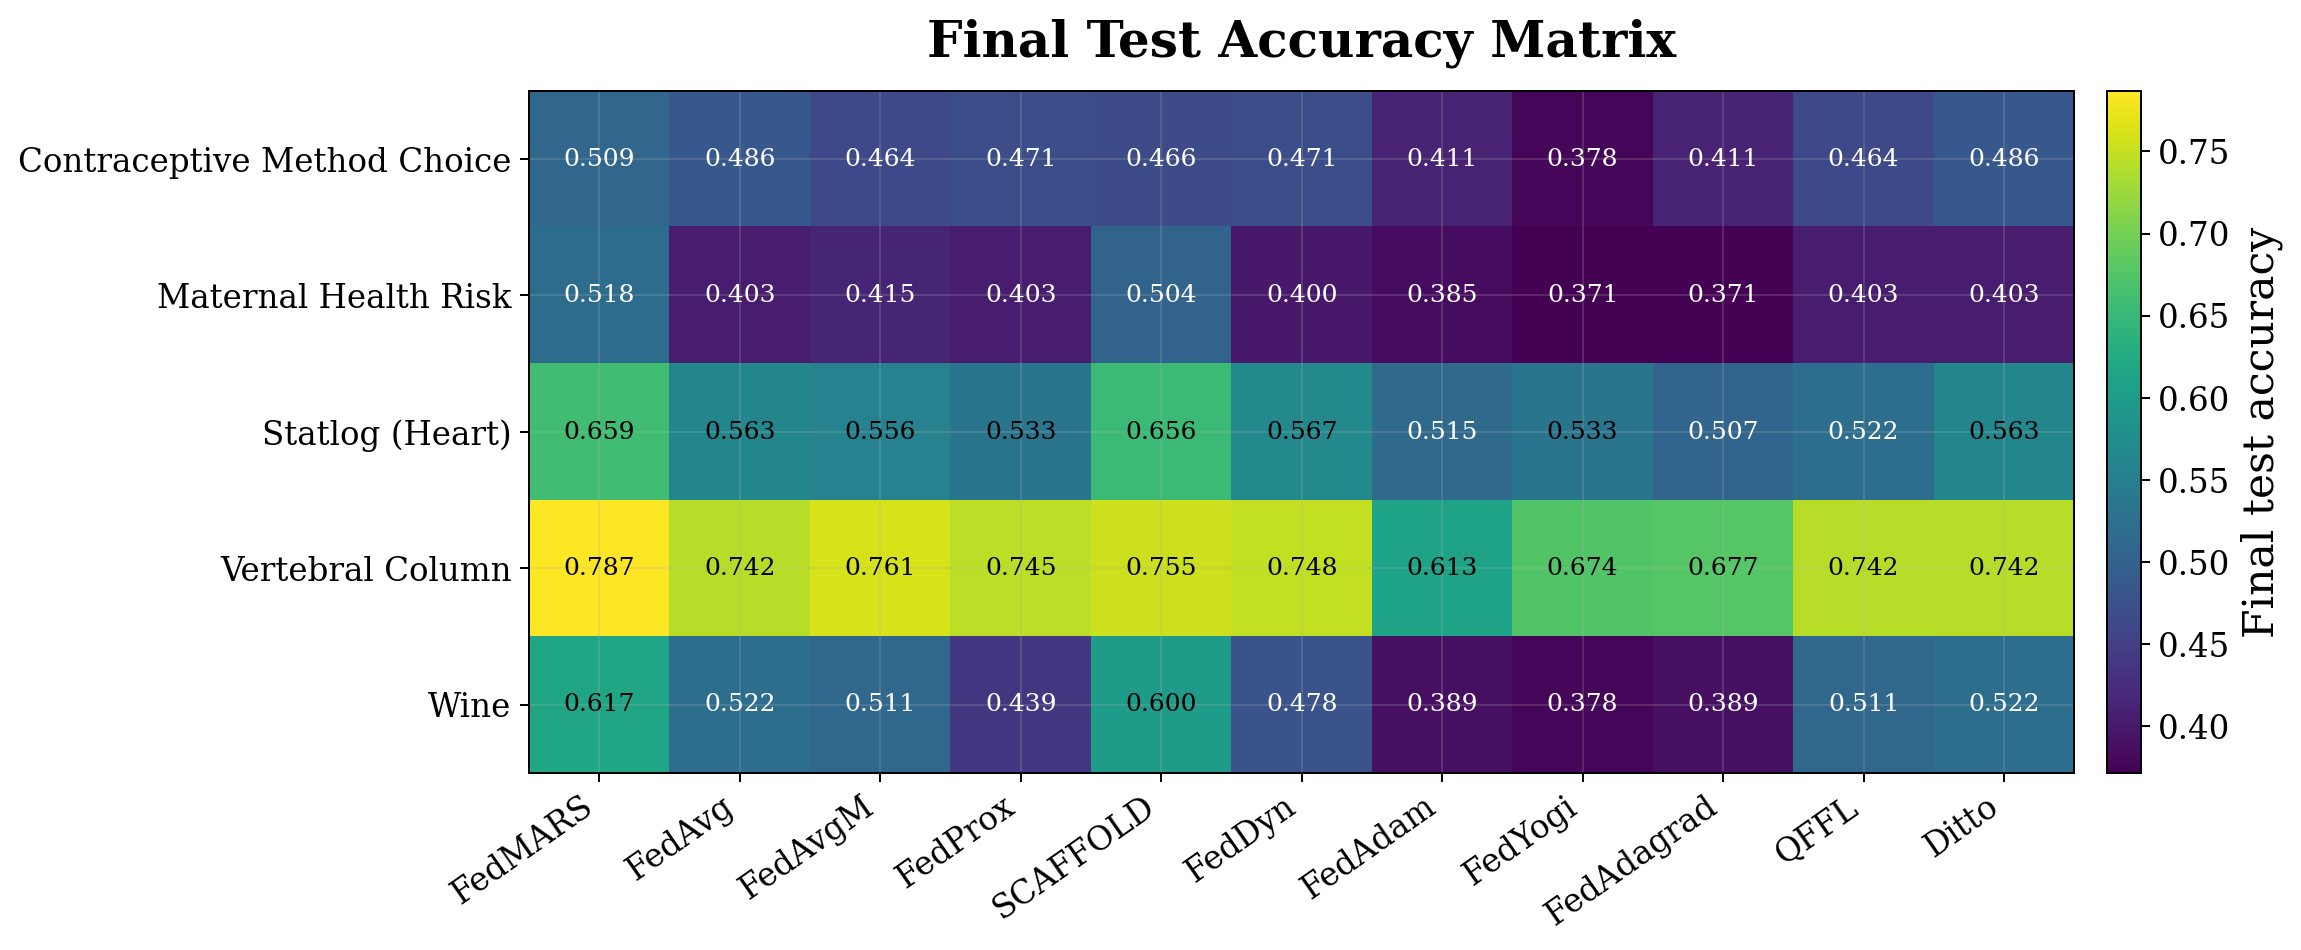

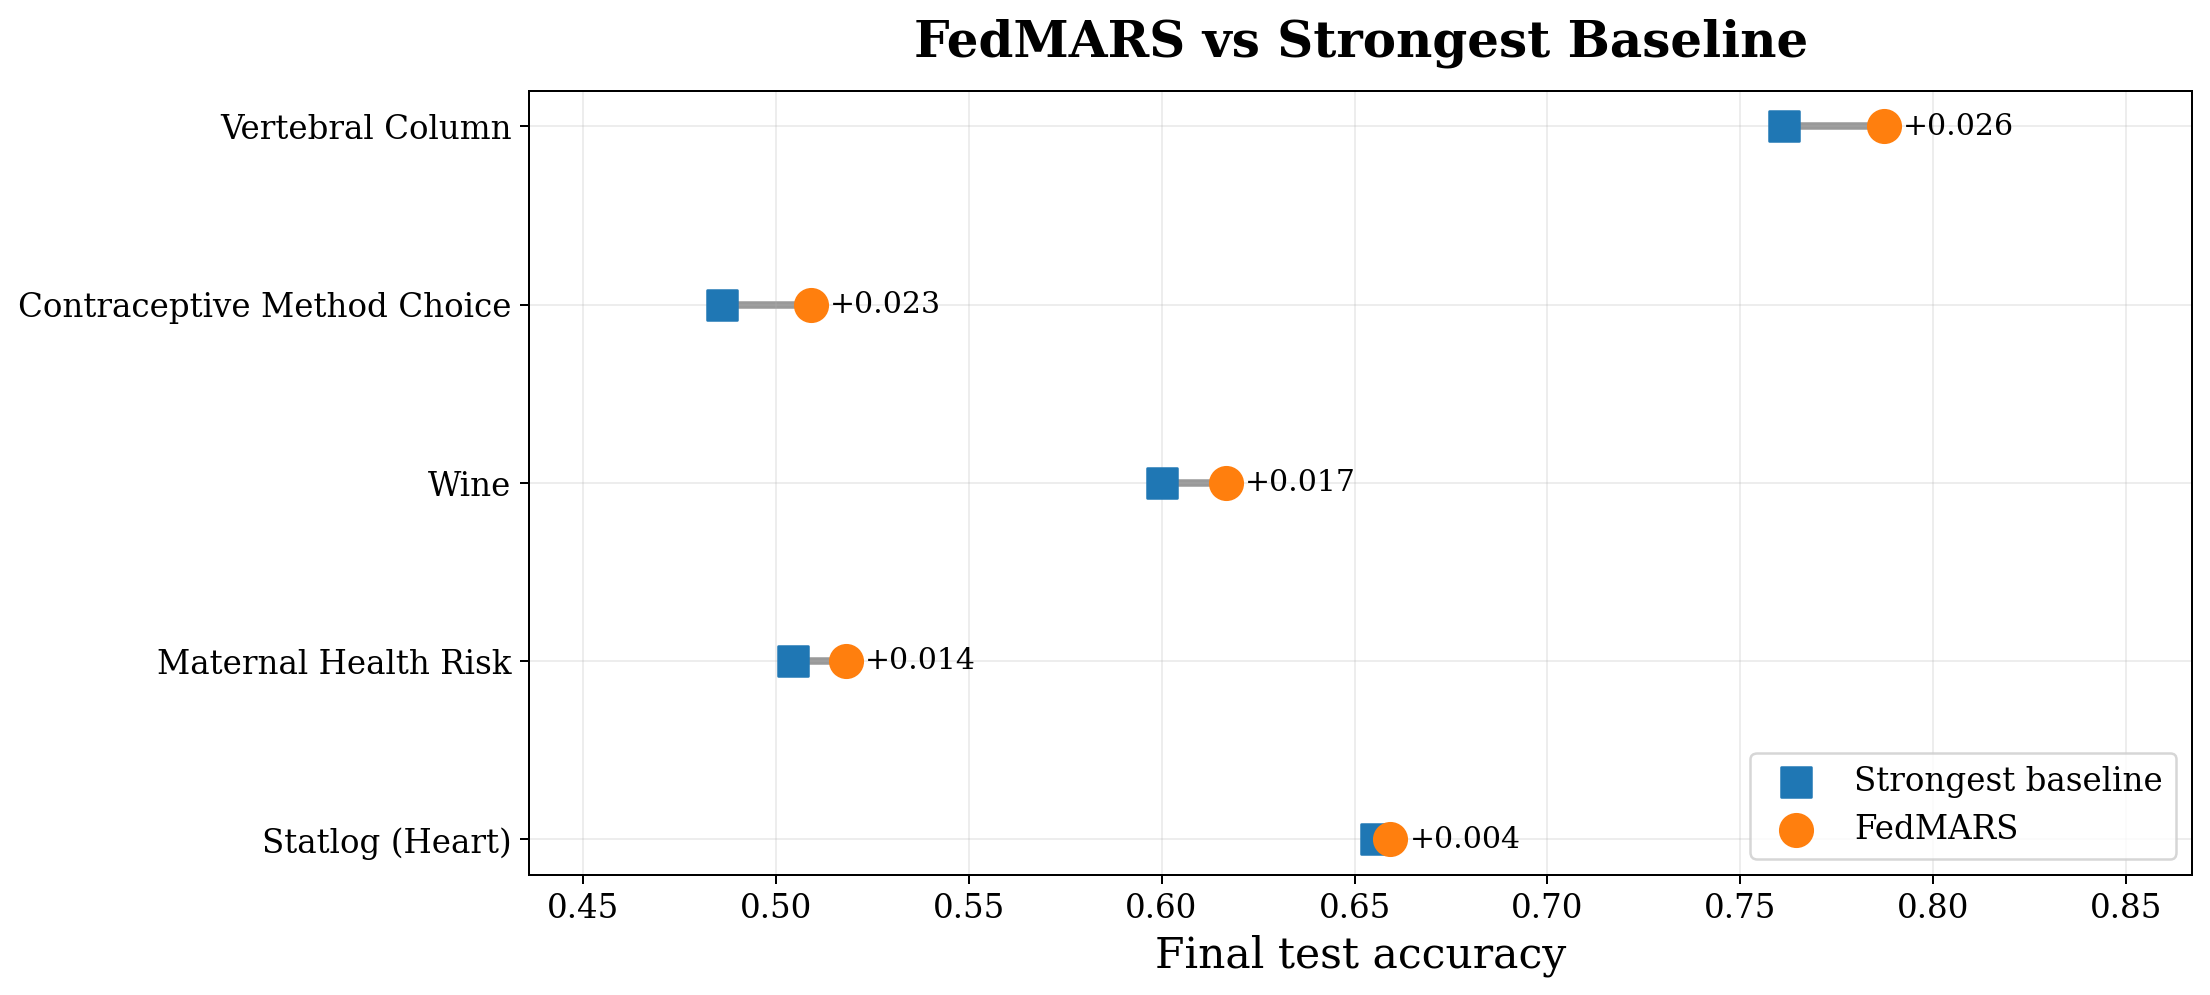

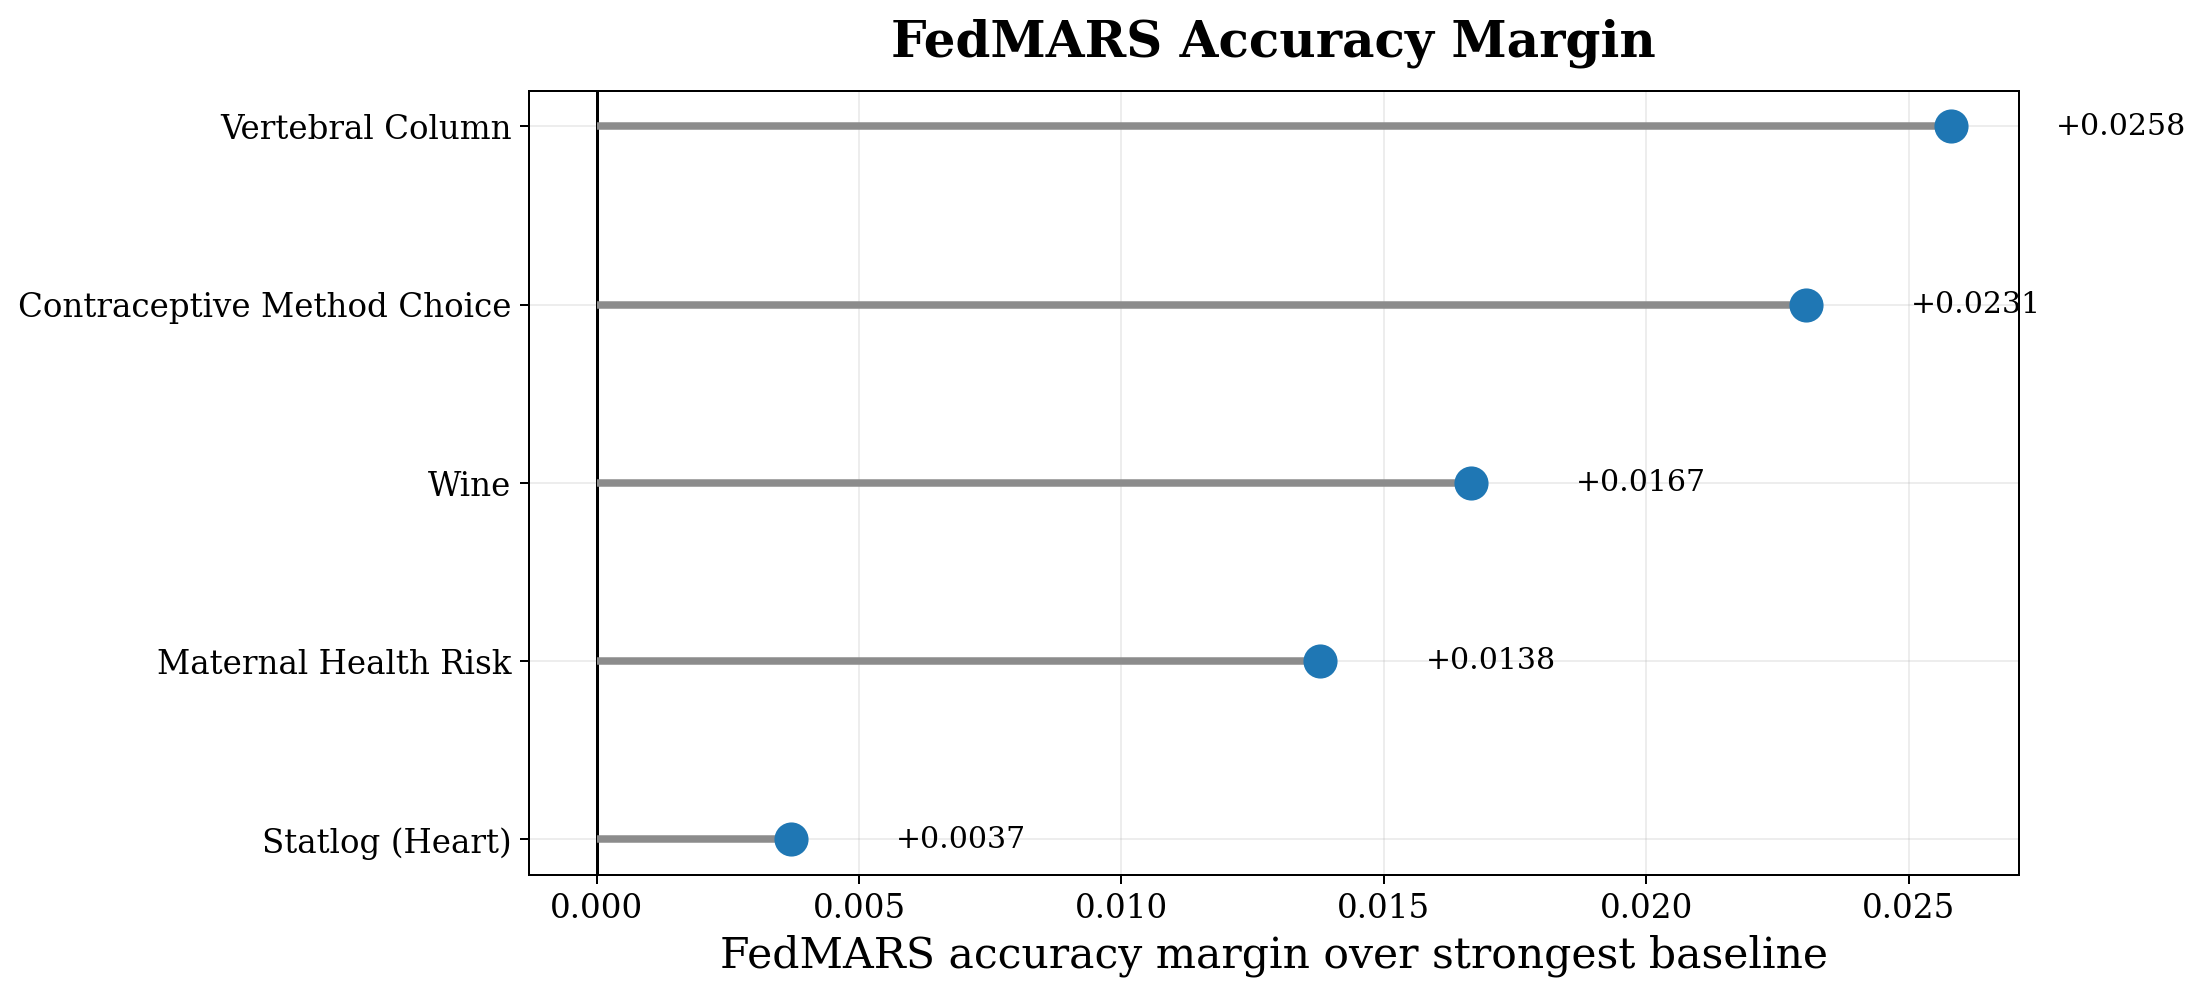

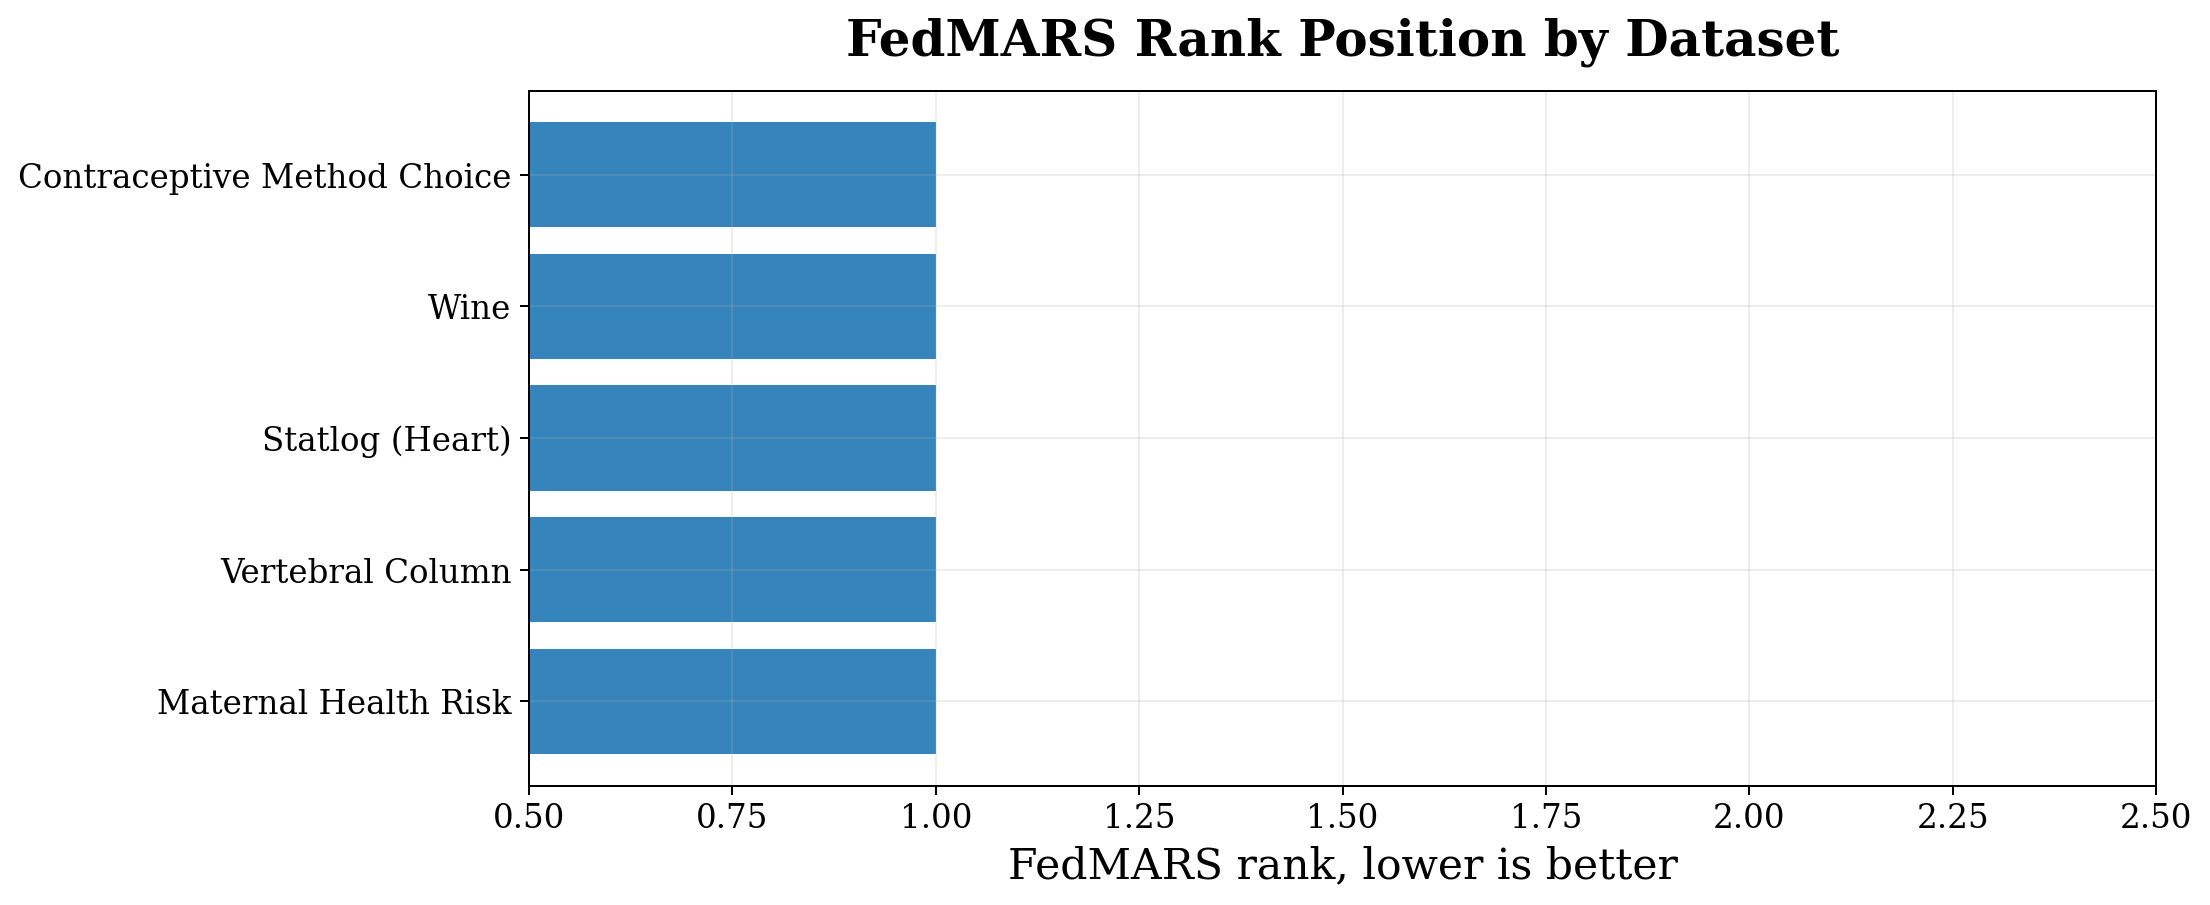

## Plot source table: FedMARS versus strongest baseline

,uci_id,dataset_name,fedmars_acc,baseline_method,baseline_acc,margin
0,145,Statlog (Heart),0.659259,SCAFFOLD,0.655556,0.003704
1,863,Maternal Health Risk,0.518227,SCAFFOLD,0.504433,0.013793
2,109,Wine,0.616667,SCAFFOLD,0.600000,0.016667
3,30,Contraceptive Method Choice,0.509153,Ditto,0.486102,0.023051
4,212,Vertebral Column,0.787097,FedAvgM,0.761290,0.025806


## Saved plot files

,Folder,Files
0,validation4_plots,"fedmars_accuracy_margin.pdf, fedmars_accuracy_..."


In [8]:

# ============================================================
# Validation 4 plot-only cell
# This cell uses in-memory results if available, otherwise saved CSVs.
# Rerun this cell without rerunning training if you want different plots.
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 300)
pd.set_option("display.width", 240)

METHOD_ORDER_PLOT = [m for m in METHODS_TO_RUN]

if "ranked_df" in globals() and isinstance(ranked_df, pd.DataFrame) and not ranked_df.empty:
    plot_ranked = ranked_df.copy()
elif os.path.exists("validation4_ranked_dataset_method_summary.csv"):
    plot_ranked = pd.read_csv("validation4_ranked_dataset_method_summary.csv")
elif os.path.exists("validation4_dataset_method_summary.csv"):
    plot_ranked = pd.read_csv("validation4_dataset_method_summary.csv")
else:
    raise RuntimeError("No Validation 4 result dataframe found. Run the benchmark cell first or keep the saved CSV files.")

if "dataset_results_df" in globals() and isinstance(dataset_results_df, pd.DataFrame) and not dataset_results_df.empty:
    plot_summary = dataset_results_df.copy()
elif os.path.exists("validation4_dataset_method_summary.csv"):
    plot_summary = pd.read_csv("validation4_dataset_method_summary.csv")
else:
    plot_summary = plot_ranked.copy()

for col in ["final_test_accuracy_mean", "final_test_accuracy_std"]:
    if col in plot_ranked.columns:
        plot_ranked[col] = pd.to_numeric(plot_ranked[col], errors="coerce")
    if col in plot_summary.columns:
        plot_summary[col] = pd.to_numeric(plot_summary[col], errors="coerce")

plot_ranked = plot_ranked[plot_ranked["method"].isin(METHOD_ORDER_PLOT)].copy()
plot_summary = plot_summary[plot_summary["method"].isin(METHOD_ORDER_PLOT)].copy()

os.makedirs("validation4_plots", exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 180,
    "savefig.dpi": 400,
    "font.family": "serif",
    "font.size": 14,
    "axes.titlesize": 20,
    "axes.labelsize": 17,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "axes.grid": True,
    "grid.alpha": 0.22,
})

# Plot 1: final test accuracy heatmap
matrix = plot_summary.pivot_table(index="dataset_name", columns="method", values="final_test_accuracy_mean", aggfunc="first")
matrix = matrix[[m for m in METHOD_ORDER_PLOT if m in matrix.columns]]
matrix = matrix.sort_index()

fig, ax = plt.subplots(figsize=(max(13, 1.05 * len(matrix.columns)), max(5.5, 0.65 * len(matrix.index) + 2)))
im = ax.imshow(matrix.values.astype(float), aspect="auto", vmin=np.nanmin(matrix.values), vmax=np.nanmax(matrix.values))
ax.set_title("Final Test Accuracy Matrix", fontweight="bold", pad=14)
ax.set_xticks(np.arange(len(matrix.columns)))
ax.set_xticklabels(matrix.columns, rotation=35, ha="right")
ax.set_yticks(np.arange(len(matrix.index)))
ax.set_yticklabels(matrix.index)
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        val = matrix.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{float(val):.3f}", ha="center", va="center", fontsize=10, color="white" if float(val) < np.nanmean(matrix.values) else "black")
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="Final test accuracy")
fig.tight_layout()
plt.savefig("validation4_plots/final_test_accuracy_matrix_heatmap.png", bbox_inches="tight")
plt.savefig("validation4_plots/final_test_accuracy_matrix_heatmap.pdf", bbox_inches="tight")
plt.show()

# Plot 2: FedMARS versus strongest baseline
rows = []
for (uci_id, dataset_name), part in plot_summary.groupby(["uci_id", "dataset_name"], dropna=False):
    ok = part[part["final_test_accuracy_mean"].notna()].copy()
    if ok.empty or "FedMARS" not in ok["method"].astype(str).tolist():
        continue
    fed = ok[ok["method"] == "FedMARS"].iloc[0]
    base = ok[ok["method"] != "FedMARS"].sort_values(["final_test_accuracy_mean", "method"], ascending=[False, True])
    if base.empty:
        continue
    best = base.iloc[0]
    rows.append({
        "uci_id": int(uci_id),
        "dataset_name": dataset_name,
        "fedmars_acc": float(fed["final_test_accuracy_mean"]),
        "baseline_method": best["method"],
        "baseline_acc": float(best["final_test_accuracy_mean"]),
        "margin": float(fed["final_test_accuracy_mean"]) - float(best["final_test_accuracy_mean"]),
    })

comp = pd.DataFrame(rows).sort_values("margin", ascending=True).reset_index(drop=True)
if not comp.empty:
    y = np.arange(len(comp))
    fig, ax = plt.subplots(figsize=(12.5, max(5.5, 0.75 * len(comp) + 2)))
    for i, r in comp.iterrows():
        ax.plot([r["baseline_acc"], r["fedmars_acc"]], [i, i], color="0.60", linewidth=3, zorder=1)
    ax.scatter(comp["baseline_acc"], y, marker="s", s=150, label="Strongest baseline", zorder=3)
    ax.scatter(comp["fedmars_acc"], y, marker="o", s=170, label="FedMARS", zorder=4)
    for i, r in comp.iterrows():
        ax.text(max(r["baseline_acc"], r["fedmars_acc"]) + 0.005, i, f"{r['margin']:+.3f}", va="center", fontsize=12)
    ax.set_yticks(y)
    ax.set_yticklabels(comp["dataset_name"])
    ax.set_xlabel("Final test accuracy")
    ax.set_title("FedMARS vs Strongest Baseline", fontweight="bold", pad=14)
    ax.legend(loc="lower right", frameon=True)
    ax.grid(True, axis="x", alpha=0.22)
    xmin = min(comp["baseline_acc"].min(), comp["fedmars_acc"].min())
    xmax = max(comp["baseline_acc"].max(), comp["fedmars_acc"].max())
    ax.set_xlim(max(0, xmin - 0.05), min(1.0, xmax + 0.08))
    fig.tight_layout()
    plt.savefig("validation4_plots/fedmars_vs_strongest_baseline.png", bbox_inches="tight")
    plt.savefig("validation4_plots/fedmars_vs_strongest_baseline.pdf", bbox_inches="tight")
    plt.show()

# Plot 3: FedMARS margin over strongest baseline
if not comp.empty:
    fig, ax = plt.subplots(figsize=(12.5, max(5.2, 0.75 * len(comp) + 2)))
    y = np.arange(len(comp))
    ax.axvline(0, color="black", linewidth=1.2)
    ax.hlines(y, 0, comp["margin"], color="0.55", linewidth=3)
    ax.scatter(comp["margin"], y, s=160, marker="o", zorder=3)
    for i, r in comp.iterrows():
        x = r["margin"]
        ax.text(x + (0.002 if x >= 0 else -0.002), i, f"{x:+.4f}", va="center", ha="left" if x >= 0 else "right", fontsize=12)
    ax.set_yticks(y)
    ax.set_yticklabels(comp["dataset_name"])
    ax.set_xlabel("FedMARS accuracy margin over strongest baseline")
    ax.set_title("FedMARS Accuracy Margin", fontweight="bold", pad=14)
    ax.grid(True, axis="x", alpha=0.22)
    fig.tight_layout()
    plt.savefig("validation4_plots/fedmars_accuracy_margin.png", bbox_inches="tight")
    plt.savefig("validation4_plots/fedmars_accuracy_margin.pdf", bbox_inches="tight")
    plt.show()

# Plot 4: FedMARS rank by dataset
if "rank" in plot_ranked.columns:
    fed = plot_ranked[plot_ranked["method"] == "FedMARS"].copy()
    fed["rank"] = pd.to_numeric(fed["rank"], errors="coerce")
    fed = fed.sort_values("rank", ascending=True)
    fig, ax = plt.subplots(figsize=(12.5, max(5.0, 0.65 * len(fed) + 2)))
    y = np.arange(len(fed))
    ax.barh(y, fed["rank"], alpha=0.9)
    ax.set_yticks(y)
    ax.set_yticklabels(fed["dataset_name"])
    ax.invert_yaxis()
    ax.set_xlabel("FedMARS rank, lower is better")
    ax.set_title("FedMARS Rank Position by Dataset", fontweight="bold", pad=14)
    ax.set_xlim(0.5, max(2.5, float(fed["rank"].max()) + 0.5))
    ax.grid(True, axis="x", alpha=0.22)
    fig.tight_layout()
    plt.savefig("validation4_plots/fedmars_rank_position.png", bbox_inches="tight")
    plt.savefig("validation4_plots/fedmars_rank_position.pdf", bbox_inches="tight")
    plt.show()

# Display the main plot-source table so figures can be checked without rerunning training.
display(Markdown("## Plot source table: FedMARS versus strongest baseline"))
display(comp if not comp.empty else pd.DataFrame())

display(Markdown("## Saved plot files"))
display(pd.DataFrame({"Folder": ["validation4_plots"], "Files": [", ".join(sorted(os.listdir("validation4_plots")))]}))


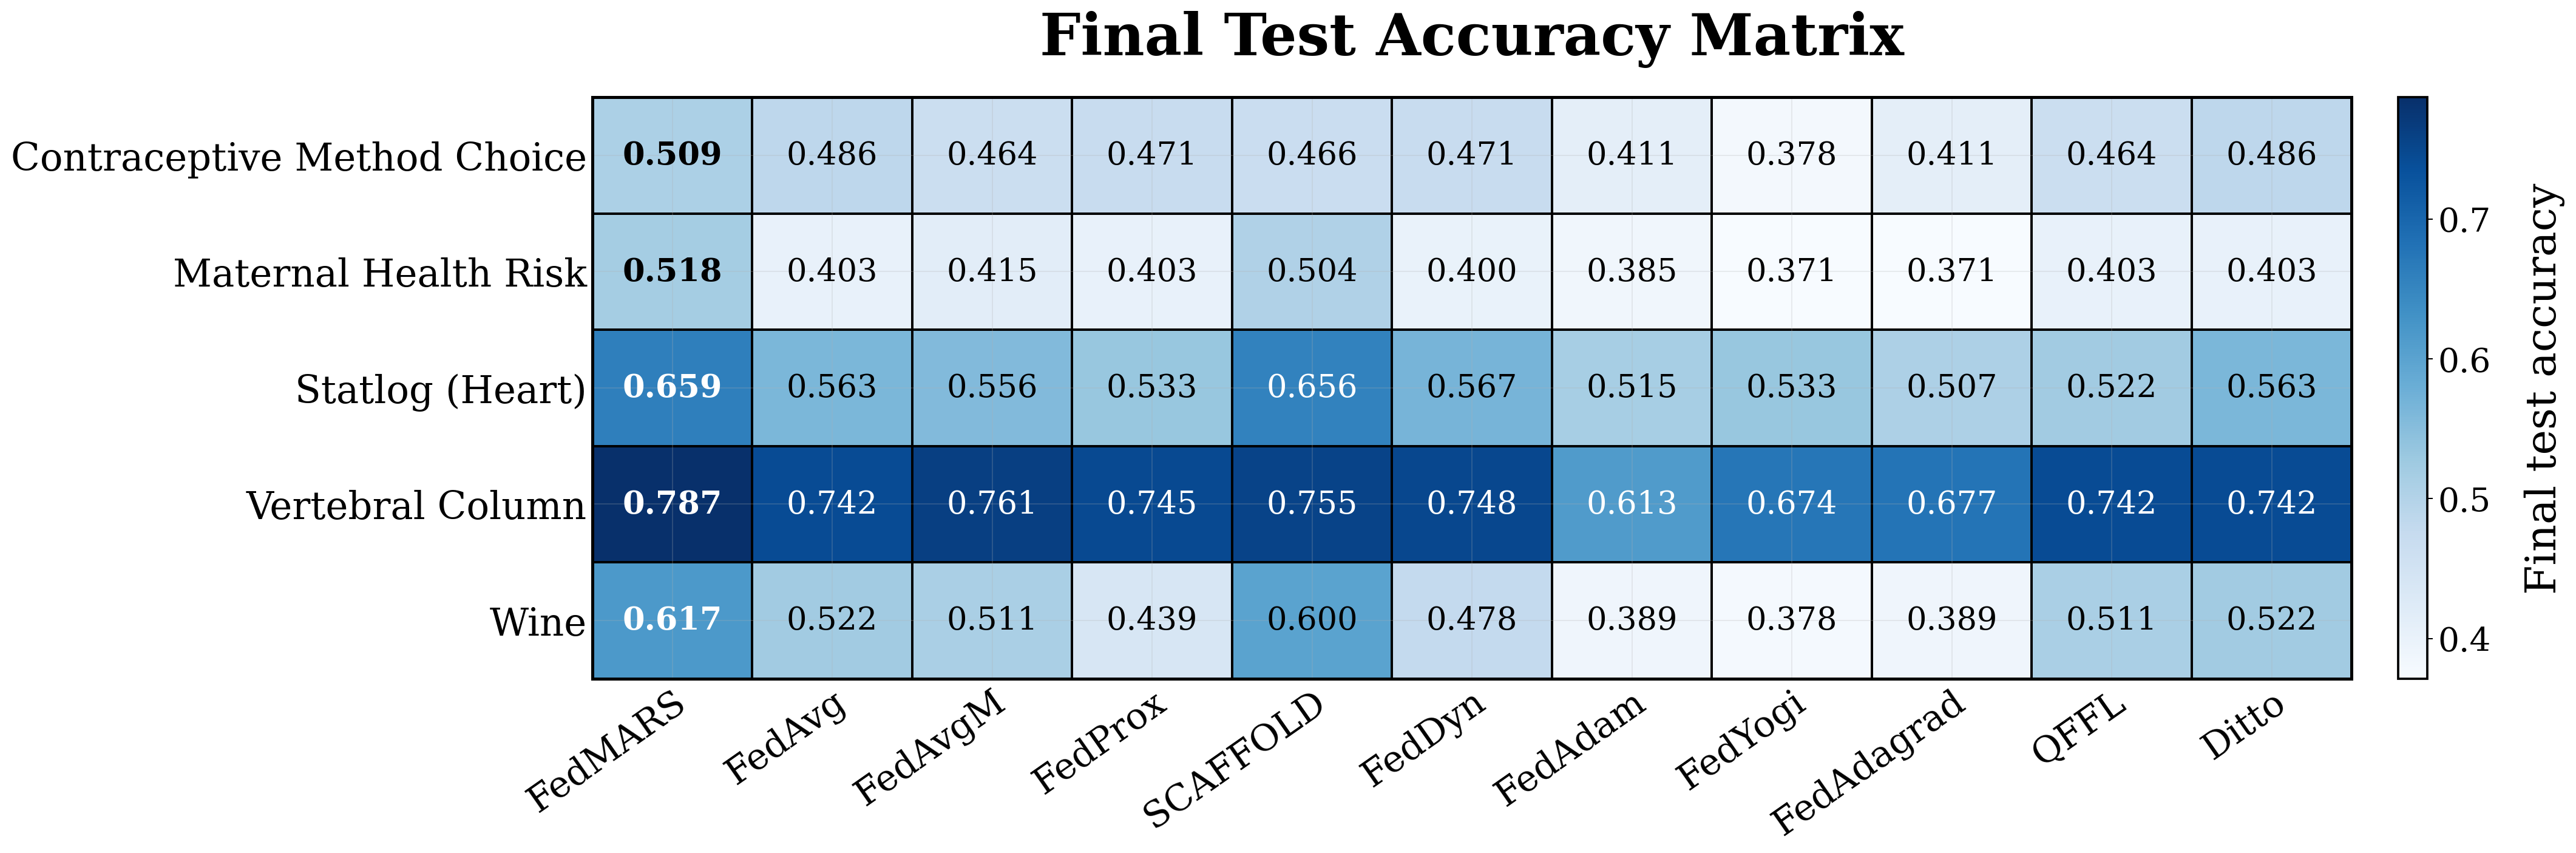

In [12]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

METHOD_ORDER = [
    "FedMARS", "FedAvg", "FedAvgM", "FedProx", "SCAFFOLD",
    "FedDyn", "FedAdam", "FedYogi", "FedAdagrad", "QFFL", "Ditto"
]

DATASET_ORDER = [
    "Contraceptive Method Choice",
    "Maternal Health Risk",
    "Statlog (Heart)",
    "Vertebral Column",
    "Wine",
]

def to_float_value(x):
    if pd.isna(x):
        return np.nan
    s = str(x)
    s = s.replace("±", " ")
    m = re.search(r"[-+]?\d*\.\d+|\d+", s)
    return float(m.group()) if m else np.nan

def norm_name(x):
    return re.sub(r"[^a-z0-9]+", "", str(x).lower())

def find_col(df, names):
    norm_cols = {norm_name(c): c for c in df.columns}
    for n in names:
        if norm_name(n) in norm_cols:
            return norm_cols[norm_name(n)]
    return None

heatmap_df = None

possible_matrix_names = [
    "heatmap_df",
    "accuracy_matrix",
    "accuracy_matrix_df",
    "final_accuracy_matrix",
    "final_accuracy_matrix_df",
    "final_test_accuracy_matrix",
    "final_test_accuracy_matrix_df",
    "matrix_df",
    "v4_matrix_df",
]

for name in possible_matrix_names:
    if name in globals() and isinstance(globals()[name], pd.DataFrame):
        temp = globals()[name].copy()
        temp.index = temp.index.astype(str)
        temp.columns = temp.columns.astype(str)
        has_methods = any(c in METHOD_ORDER for c in temp.columns)
        has_datasets = any(i in DATASET_ORDER for i in temp.index)
        if has_methods and has_datasets:
            heatmap_df = temp.copy()
            break

if heatmap_df is None:
    source_df = None

    possible_summary_names = [
        "combined_summary_df",
        "full_summary_df",
        "summary_df",
        "results_df",
        "result_df",
        "final_results_df",
        "v4_results_df",
        "all_results_df",
        "method_summary_df",
        "dataset_method_summary_df",
    ]

    for name in possible_summary_names:
        if name in globals() and isinstance(globals()[name], pd.DataFrame):
            temp = globals()[name].copy()
            dcol = find_col(temp, ["dataset", "dataset_name", "Dataset"])
            mcol = find_col(temp, ["method", "Method"])
            acol = find_col(
                temp,
                [
                    "final_test_accuracy_mean",
                    "Final test accuracy",
                    "final_test_accuracy",
                    "final_accuracy",
                    "accuracy",
                    "mean_accuracy",
                ],
            )
            if dcol is not None and mcol is not None and acol is not None:
                source_df = temp[[dcol, mcol, acol]].copy()
                source_df.columns = ["Dataset", "Method", "Accuracy"]
                break

    if source_df is None:
        for name, obj in list(globals().items()):
            if isinstance(obj, pd.DataFrame):
                temp = obj.copy()
                dcol = find_col(temp, ["dataset", "dataset_name", "Dataset"])
                mcol = find_col(temp, ["method", "Method"])
                acol = find_col(
                    temp,
                    [
                        "final_test_accuracy_mean",
                        "Final test accuracy",
                        "final_test_accuracy",
                        "final_accuracy",
                        "accuracy",
                        "mean_accuracy",
                    ],
                )
                if dcol is not None and mcol is not None and acol is not None:
                    source_df = temp[[dcol, mcol, acol]].copy()
                    source_df.columns = ["Dataset", "Method", "Accuracy"]
                    break

    if source_df is None:
        raise RuntimeError(
            "Could not find V4 result dataframe. Expected either a matrix dataframe "
            "or a dataframe with Dataset, Method, and Final test accuracy columns."
        )

    source_df["Dataset"] = source_df["Dataset"].astype(str)
    source_df["Method"] = source_df["Method"].astype(str)
    source_df["Accuracy"] = source_df["Accuracy"].apply(to_float_value)

    heatmap_df = source_df.pivot_table(
        index="Dataset",
        columns="Method",
        values="Accuracy",
        aggfunc="mean",
    )

heatmap_df = heatmap_df.copy()
heatmap_df.index = heatmap_df.index.astype(str)
heatmap_df.columns = heatmap_df.columns.astype(str)

datasets = [d for d in DATASET_ORDER if d in heatmap_df.index]
methods = [m for m in METHOD_ORDER if m in heatmap_df.columns]

if len(datasets) == 0:
    datasets = list(heatmap_df.index)

if len(methods) == 0:
    methods = list(heatmap_df.columns)

heatmap_df = heatmap_df.loc[datasets, methods]
heatmap_df = heatmap_df.applymap(to_float_value)

values = heatmap_df.values.astype(float)

plt.rcParams.update({
    "figure.dpi": 180,
    "savefig.dpi": 600,
    "font.family": "serif",
    "font.size": 18,
    "axes.titlesize": 34,
    "axes.labelsize": 26,
    "xtick.labelsize": 22,
    "ytick.labelsize": 24,
})

fig, ax = plt.subplots(figsize=(24, 9.5))

vmin = np.nanmin(values)
vmax = np.nanmax(values)

im = ax.imshow(
    values,
    cmap="Blues",
    vmin=vmin,
    vmax=vmax,
    aspect="auto",
    interpolation="nearest",
)

ax.set_title(
    "Final Test Accuracy Matrix",
    fontsize=38,
    fontweight="bold",
    pad=28,
)

ax.set_xticks(np.arange(len(methods)))
ax.set_yticks(np.arange(len(datasets)))

ax.set_xticklabels(
    methods,
    rotation=35,
    ha="right",
    rotation_mode="anchor",
    fontsize=24,
)

ax.set_yticklabels(
    datasets,
    fontsize=25,
)

ax.tick_params(axis="both", length=0)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(2.0)

row_best = np.nanmax(values, axis=1)
threshold = vmin + 0.58 * (vmax - vmin)

for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        val = values[i, j]

        rect = Rectangle(
            (j - 0.5, i - 0.5),
            1,
            1,
            fill=False,
            edgecolor="black",
            linewidth=1.5,
        )
        ax.add_patch(rect)

        if np.isnan(val):
            label = ""
            color = "black"
            weight = "normal"
        else:
            label = f"{val:.3f}"
            color = "white" if val >= threshold else "black"
            weight = "bold" if np.isclose(val, row_best[i], atol=1e-12) else "normal"

        ax.text(
            j,
            i,
            label,
            ha="center",
            va="center",
            fontsize=21,
            fontweight=weight,
            color=color,
        )

ax.set_xlim(-0.5, len(methods) - 0.5)
ax.set_ylim(len(datasets) - 0.5, -0.5)

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.030,
    pad=0.025,
)

cbar.set_label(
    "Final test accuracy",
    fontsize=28,
    rotation=90,
    labelpad=22,
)

cbar.ax.tick_params(labelsize=22)
cbar.outline.set_linewidth(1.5)

fig.subplots_adjust(
    left=0.20,
    right=0.91,
    top=0.86,
    bottom=0.30,
)

plt.savefig(
    "v4_final_test_accuracy_matrix_all_cell_borders.png",
    dpi=600,
    bbox_inches="tight",
)
plt.savefig(
    "v4_final_test_accuracy_matrix_all_cell_borders.pdf",
    bbox_inches="tight",
)
plt.savefig(
    "v4_final_test_accuracy_matrix_all_cell_borders.svg",
    bbox_inches="tight",
)

plt.show()

# Validation 4 full baseline-comparison outputs

Loaded CSV: `validation4_ranked_dataset_method_summary.csv`

## Dataset and method coverage

,Number of datasets,Datasets,Number of methods,Methods
0,5,"Contraceptive Method Choice, Wine, Statlog (He...",11,"FedMARS, FedAvg, FedAvgM, FedProx, SCAFFOLD, F..."


## Full all-method result table

...

## FedMARS win summary

,datasets,FedMARS strict wins,FedMARS ties,FedMARS losses,mean margin,min margin,max margin
0,5,5,0,0,0.016604,0.003704,0.025806


## Seed stability against strongest baseline

,uci_id,dataset_name,fedmars_std,baseline_method,baseline_std,FedMARS more stable
0,145,Statlog (Heart),0.053158,SCAFFOLD,0.094861,True
1,863,Maternal Health Risk,0.036652,SCAFFOLD,0.090812,True
2,109,Wine,0.131937,SCAFFOLD,0.122474,False
3,30,Contraceptive Method Choice,0.020940,Ditto,0.029521,True
4,212,Vertebral Column,0.027749,FedAvgM,0.043757,True


## Plot 1: Final test accuracy matrix

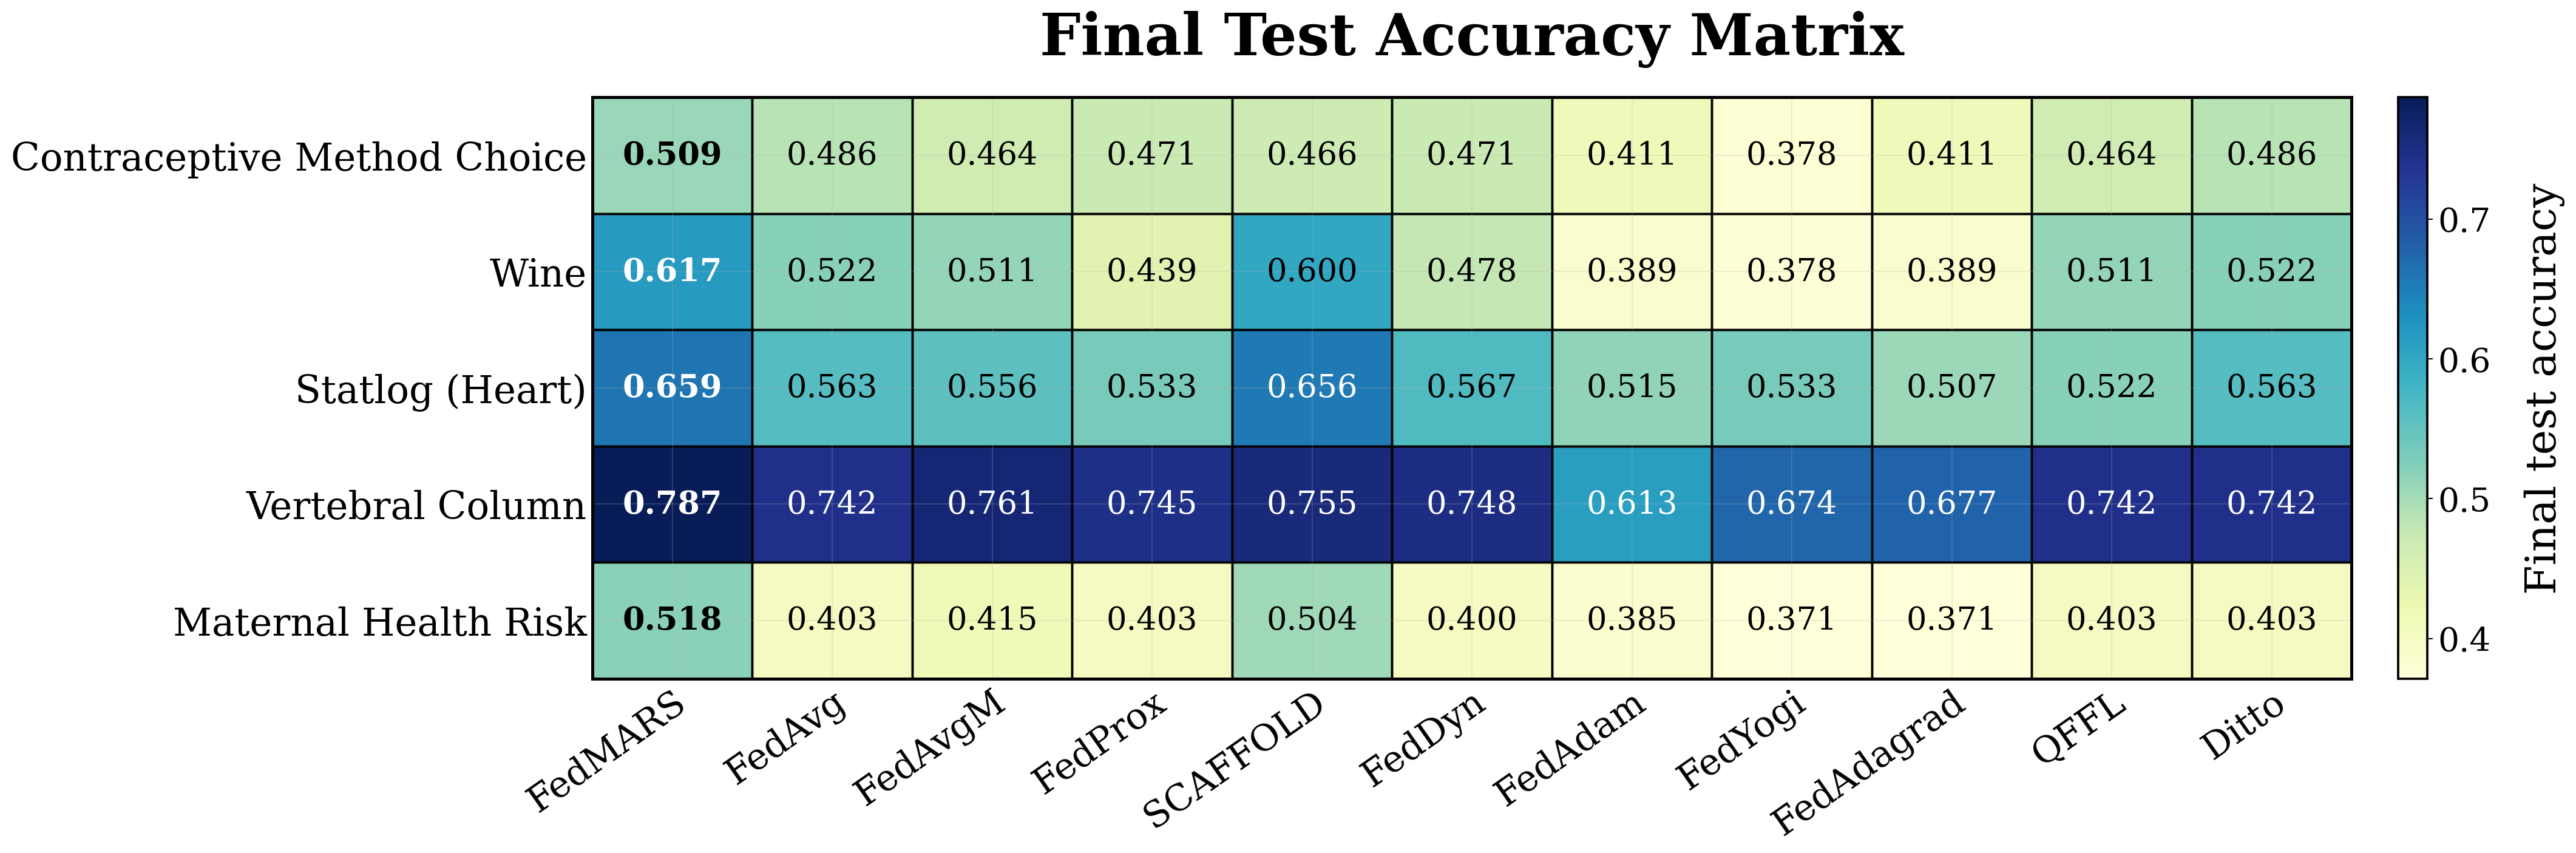

## Plot 2: All methods final accuracy by dataset

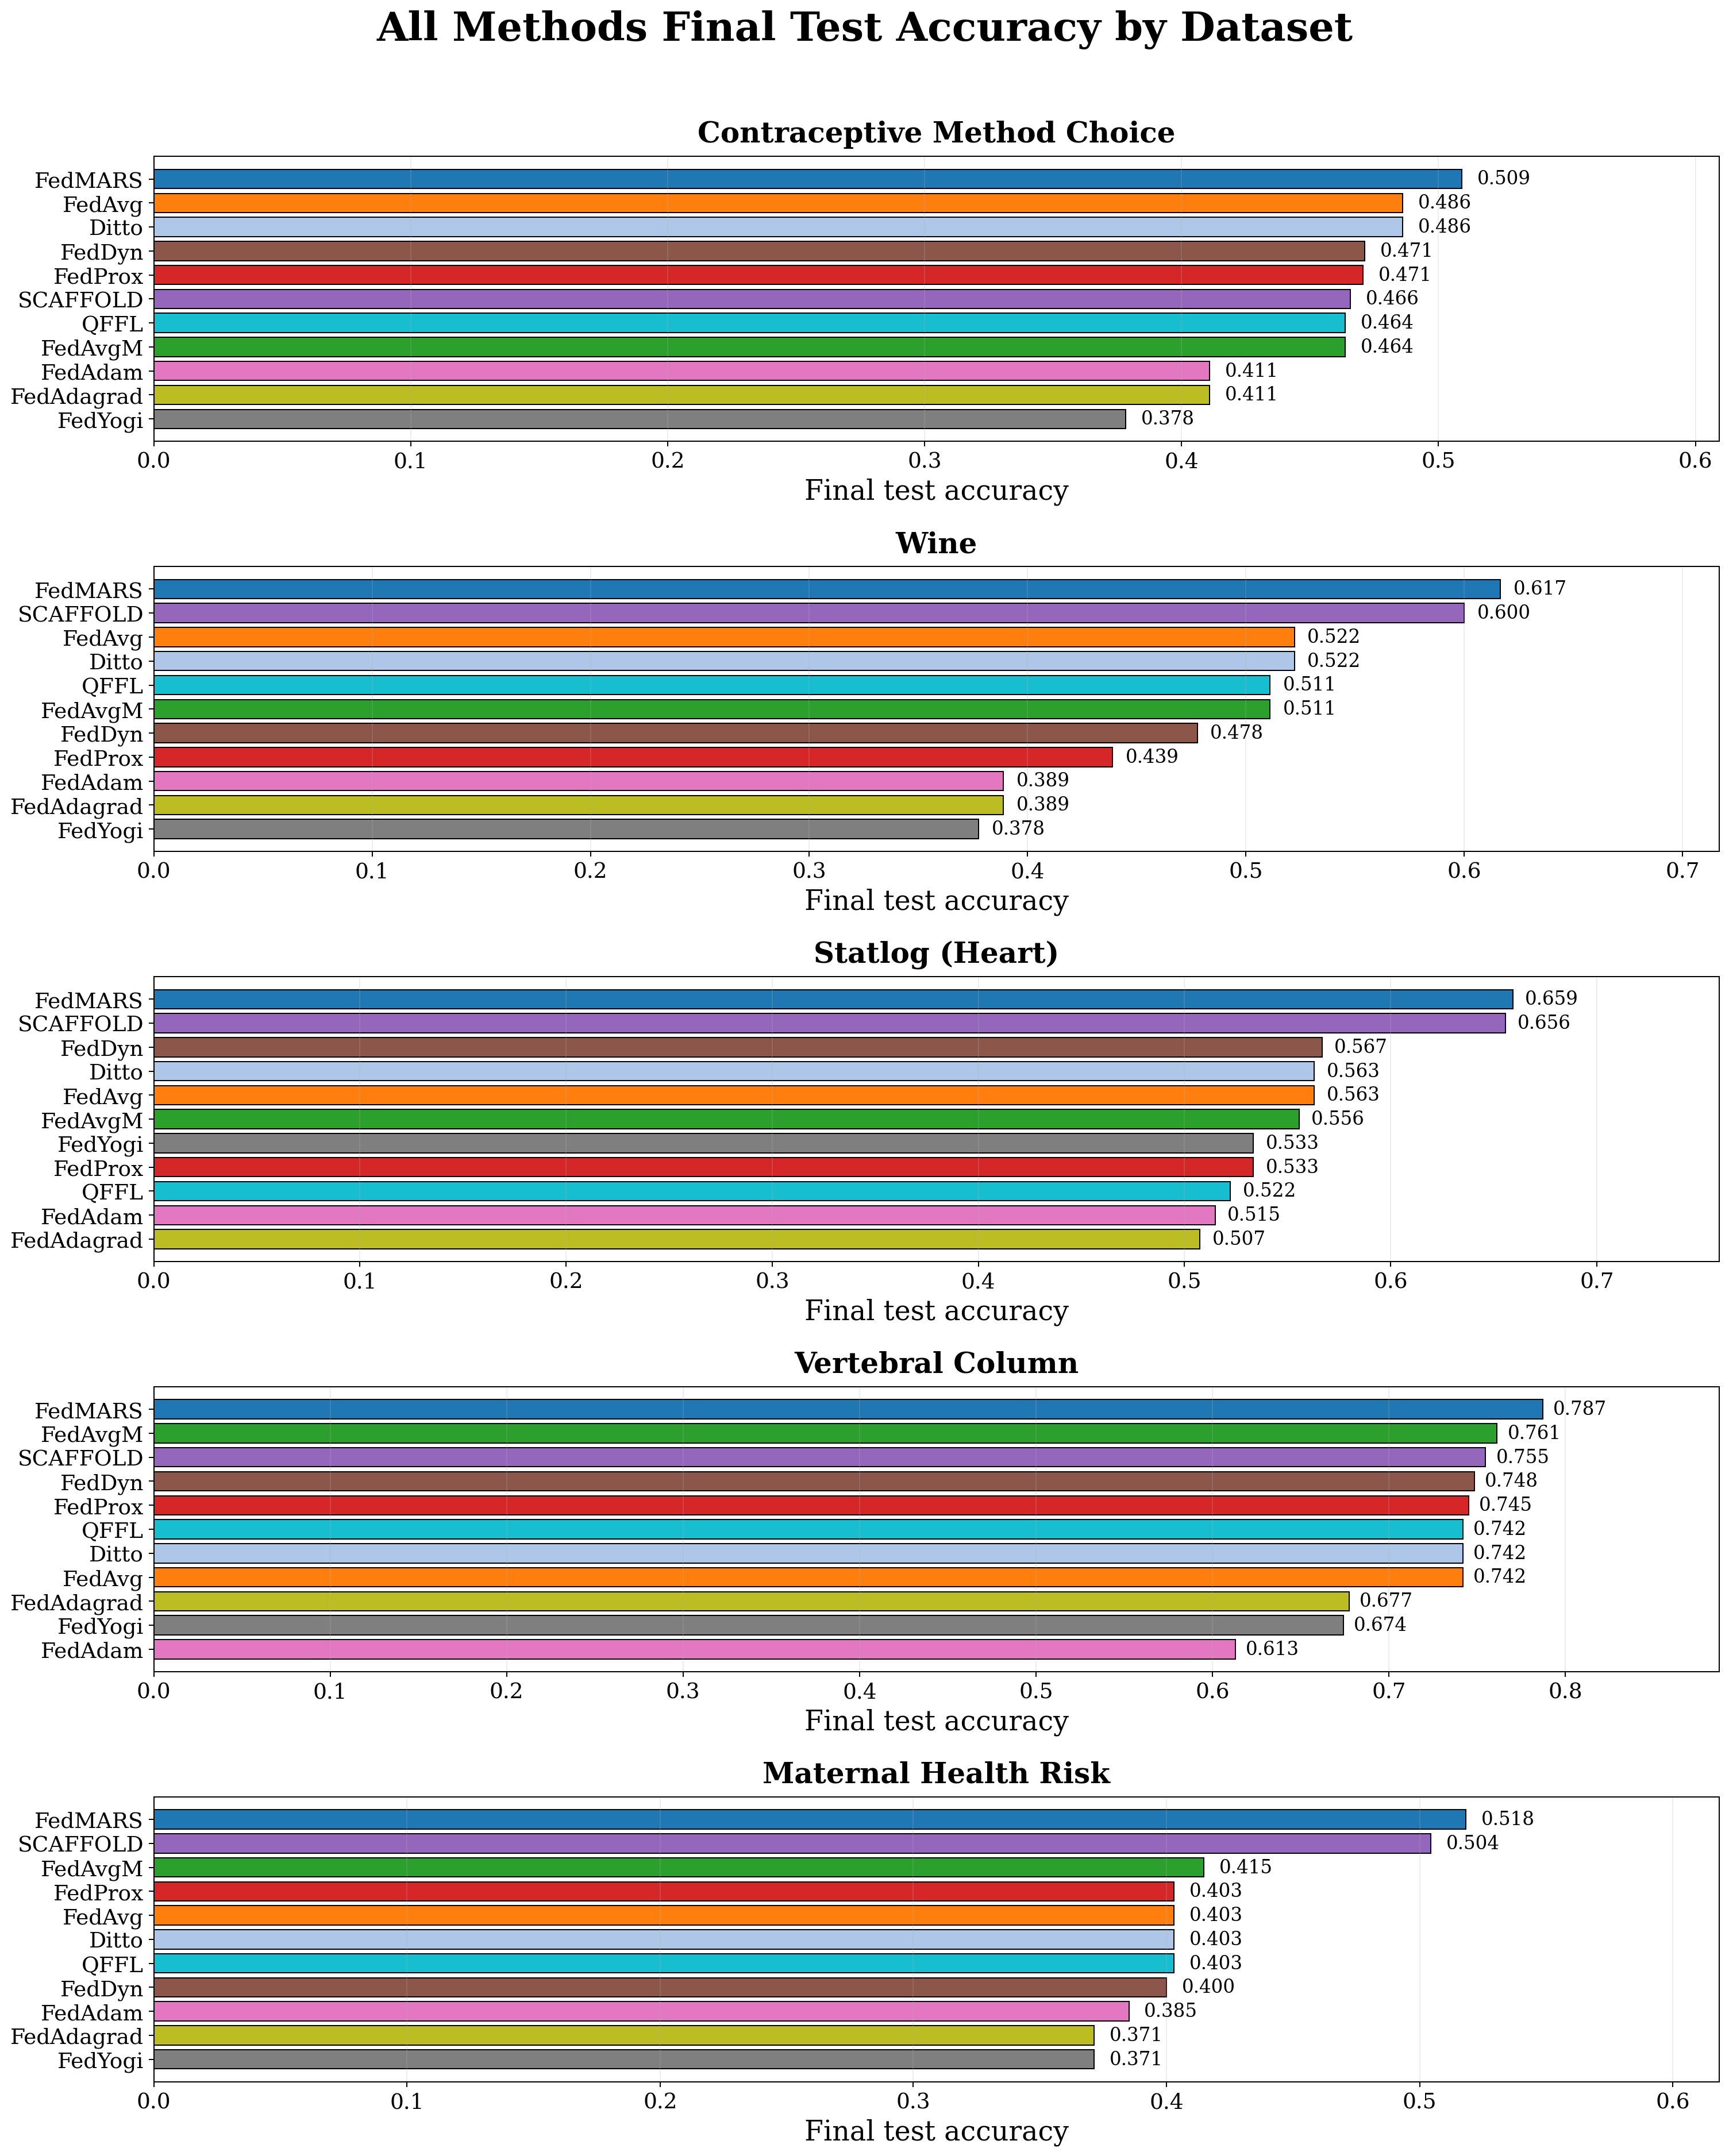

## Plot 3: FedMARS versus strongest baseline

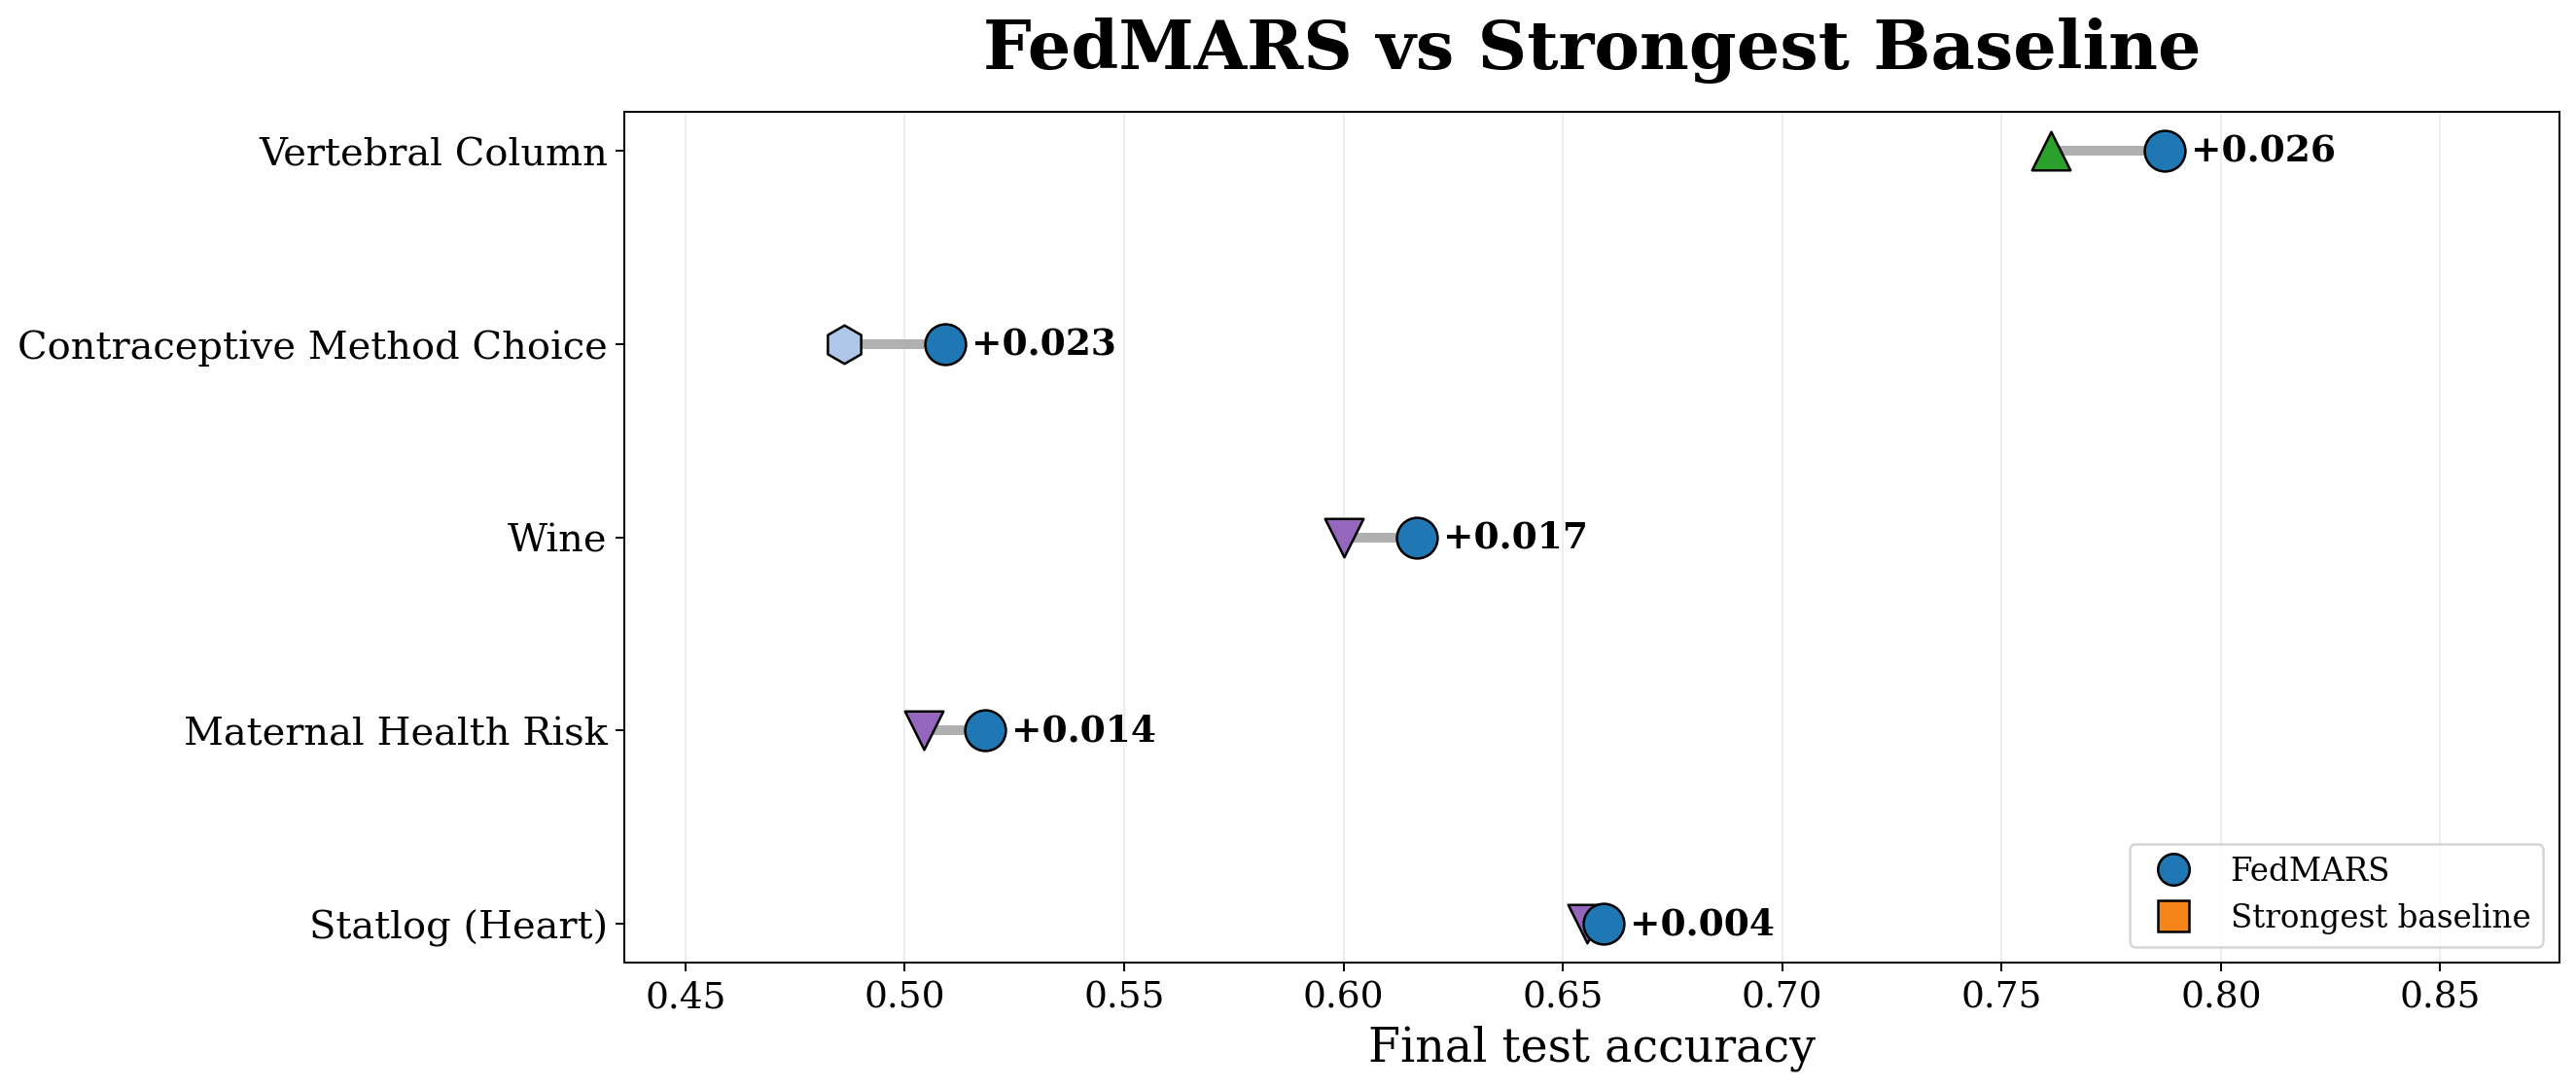

## Plot 4: FedMARS accuracy margin over strongest baseline

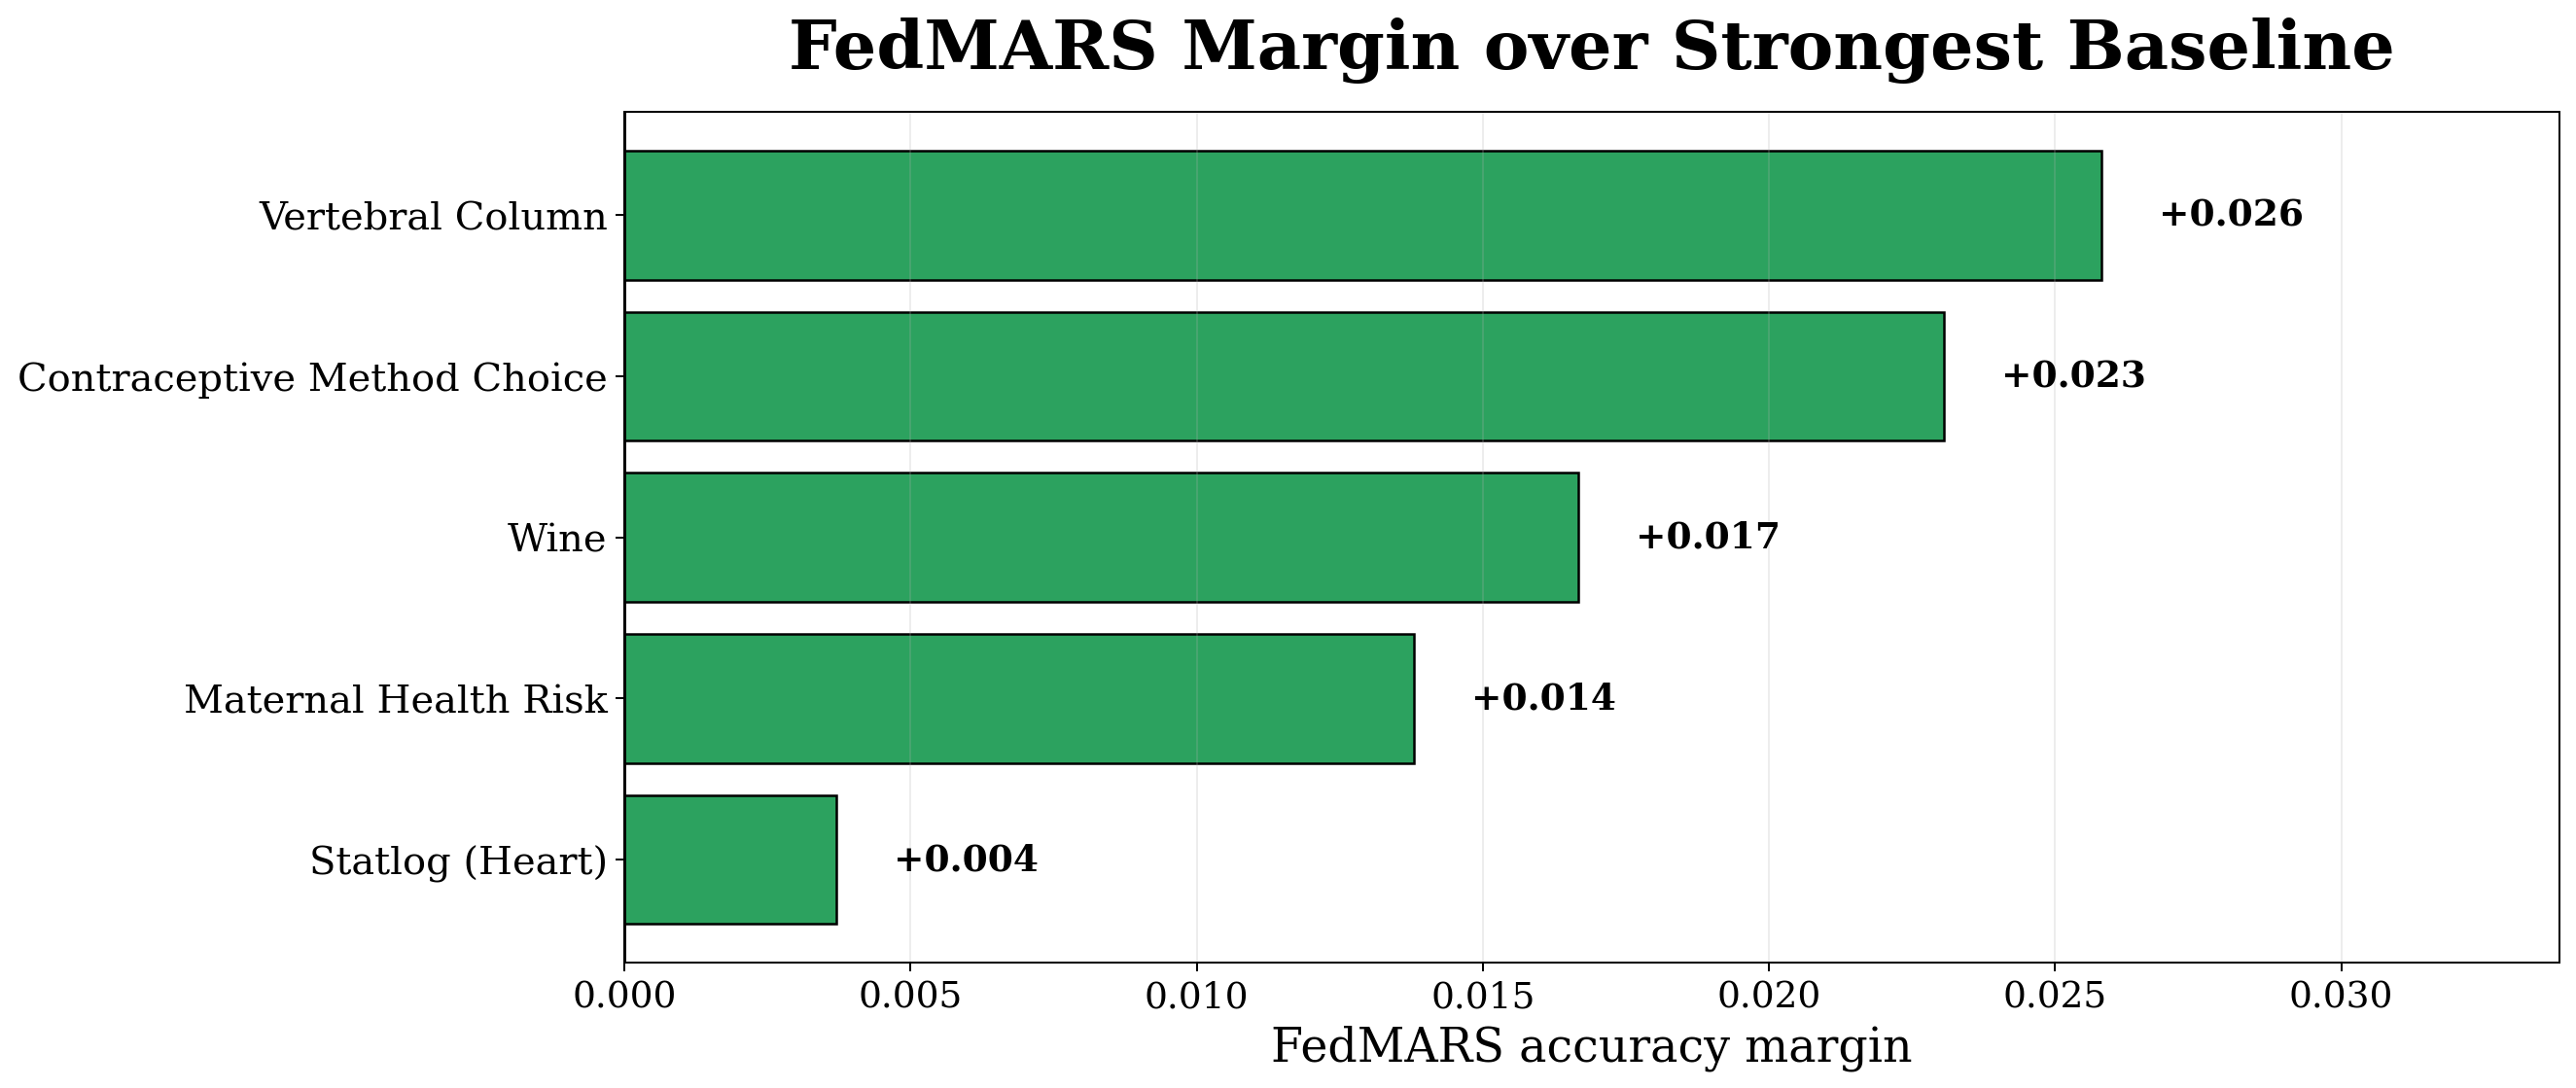

## Plot 5: Seed stability against strongest baseline

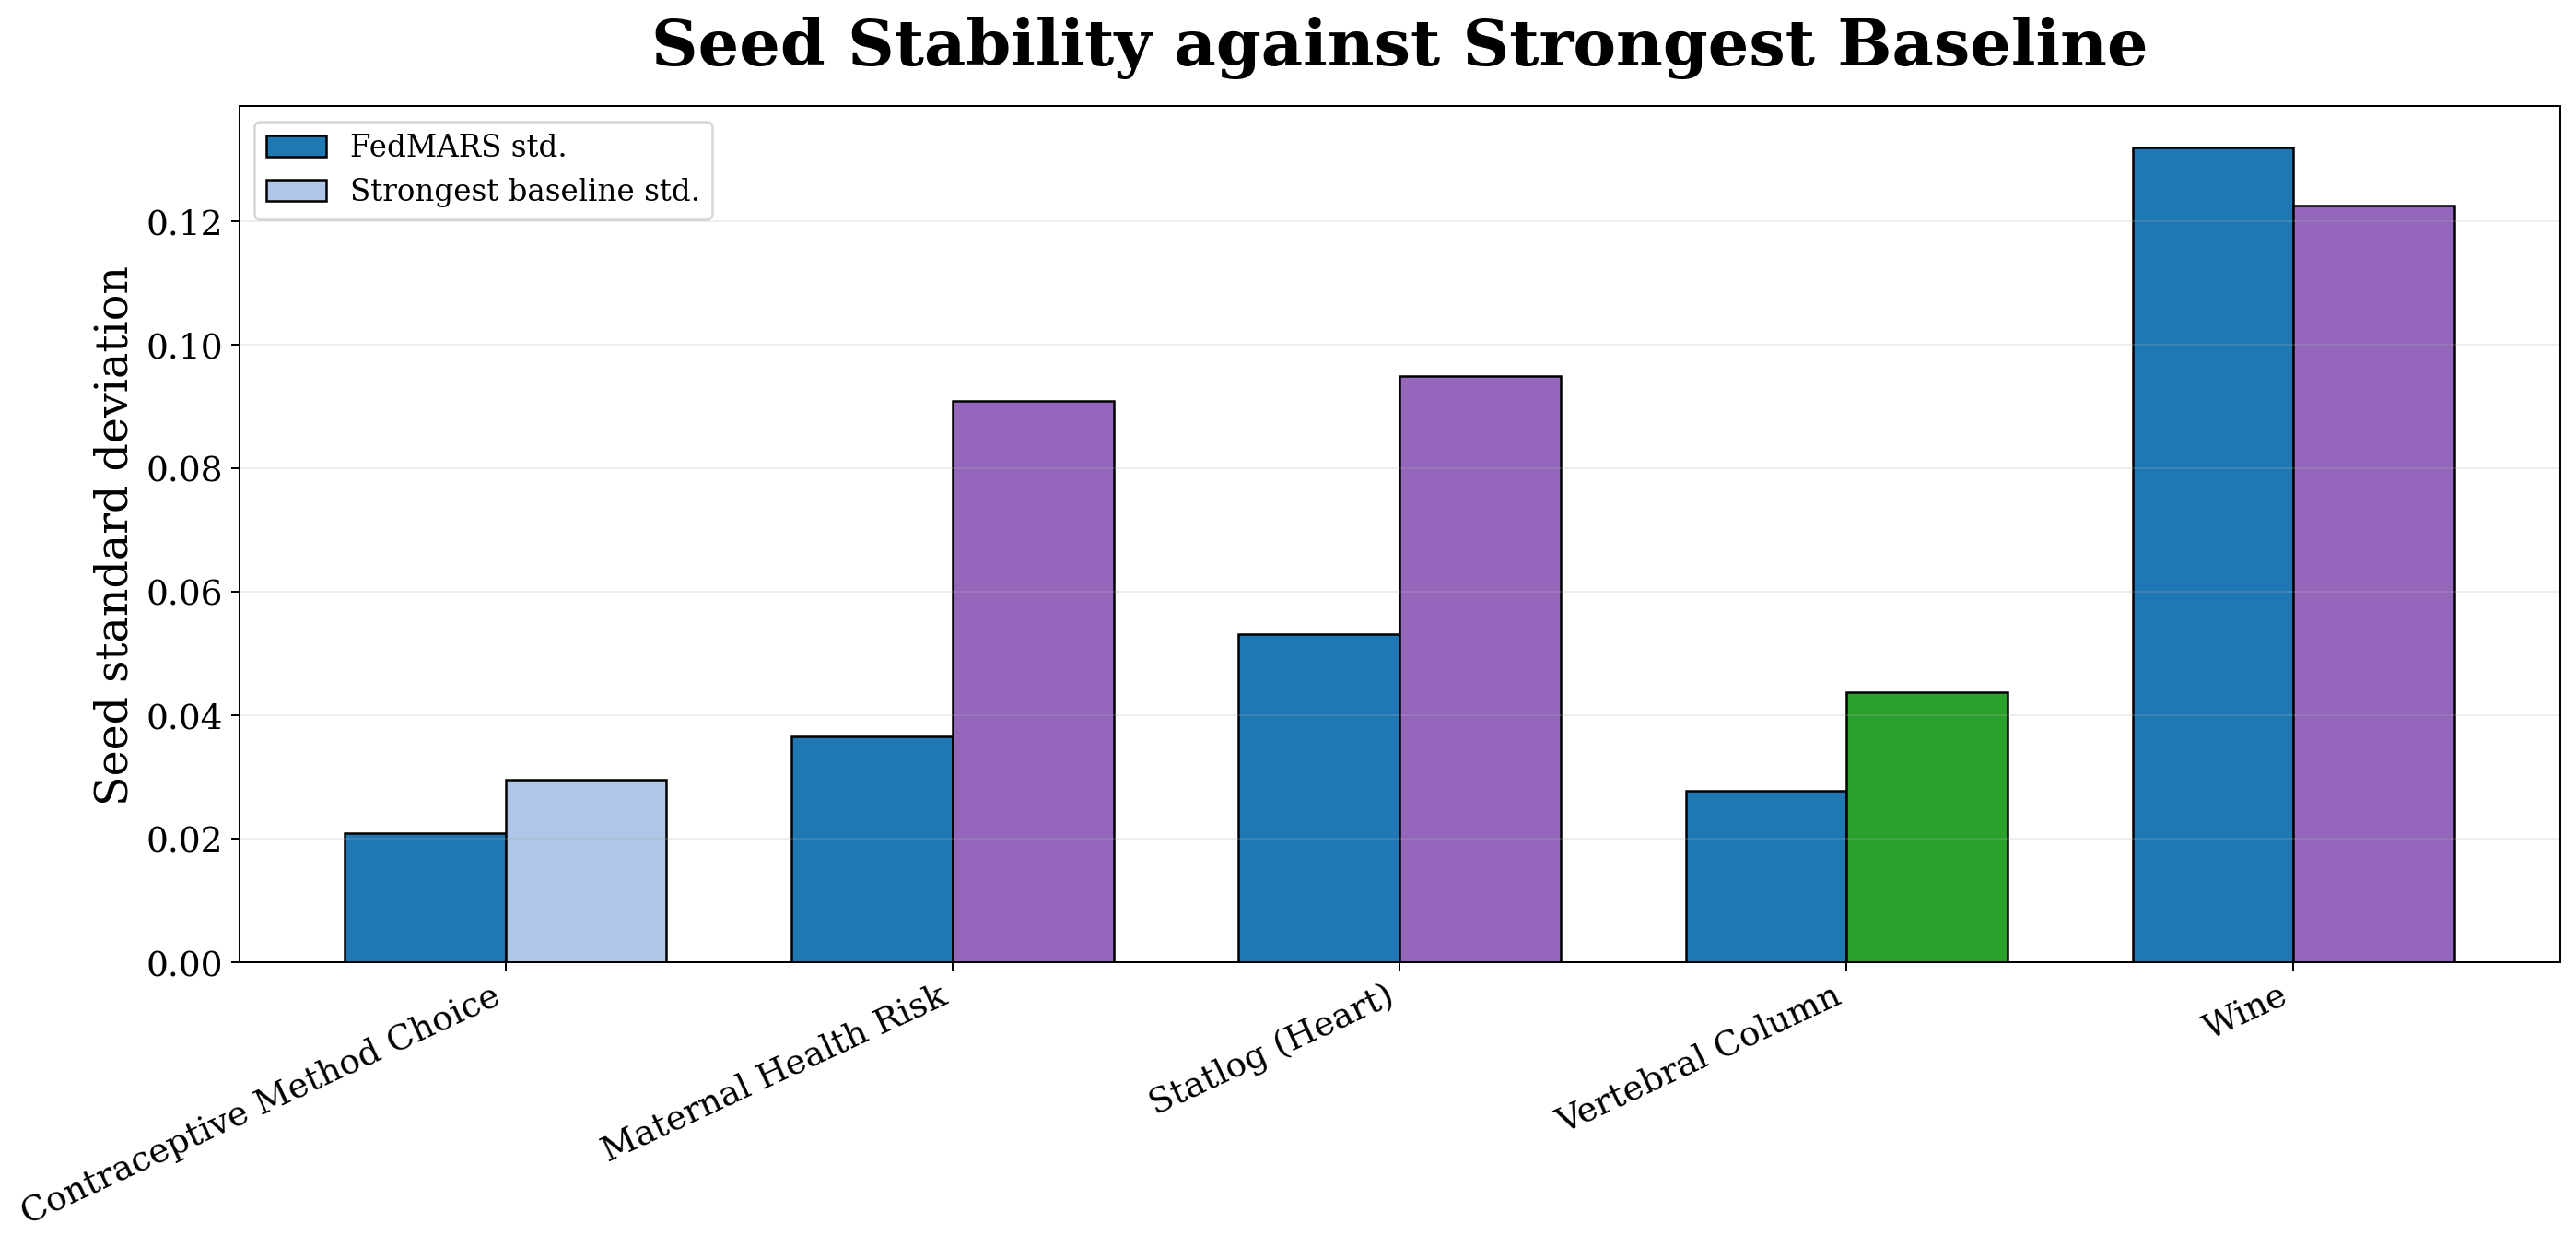

## No round-wise curve CSV found
All final-result outputs and plots are shown above. Round-wise train/validation/test curves require `validation4_round_curve_history.csv`.

## Saved output folder

,Folder,Files
0,validation4_full_colored_outputs,v4_all_methods_final_accuracy_by_dataset_color...


In [15]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 500)
pd.set_option("display.width", 300)

OUTDIR = "validation4_full_colored_outputs"
os.makedirs(OUTDIR, exist_ok=True)

METHOD_ORDER = [
    "FedMARS", "FedAvg", "FedAvgM", "FedProx", "SCAFFOLD",
    "FedDyn", "FedAdam", "FedYogi", "FedAdagrad", "QFFL", "Ditto"
]

METHOD_COLORS = {
    "FedMARS": "#1f77b4",
    "FedAvg": "#ff7f0e",
    "FedAvgM": "#2ca02c",
    "FedProx": "#d62728",
    "SCAFFOLD": "#9467bd",
    "FedDyn": "#8c564b",
    "FedAdam": "#e377c2",
    "FedYogi": "#7f7f7f",
    "FedAdagrad": "#bcbd22",
    "QFFL": "#17becf",
    "Ditto": "#aec7e8",
}

METHOD_MARKERS = {
    "FedMARS": "o",
    "FedAvg": "s",
    "FedAvgM": "^",
    "FedProx": "D",
    "SCAFFOLD": "v",
    "FedDyn": "P",
    "FedAdam": "X",
    "FedYogi": "*",
    "FedAdagrad": "<",
    "QFFL": ">",
    "Ditto": "h",
}

plt.rcParams.update({
    "figure.dpi": 180,
    "savefig.dpi": 600,
    "font.family": "serif",
    "font.size": 16,
    "axes.titlesize": 24,
    "axes.labelsize": 19,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 13,
    "axes.grid": True,
    "grid.alpha": 0.22,
})

def _fmt_float(x, digits=4, signed=False):
    if pd.isna(x):
        return "—"
    return f"{float(x):+.{digits}f}" if signed else f"{float(x):.{digits}f}"

def _fmt_mean_std(mean, std, digits=4):
    if pd.isna(mean):
        return "—"
    if pd.isna(std):
        return f"{float(mean):.{digits}f}"
    return f"{float(mean):.{digits}f} ± {float(std):.{digits}f}"

def _num(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

summary_csv = None
for p in [
    "validation4_ranked_dataset_method_summary.csv",
    "validation4_dataset_method_summary.csv",
]:
    if os.path.exists(p):
        summary_csv = p
        break

if summary_csv is None:
    raise RuntimeError(
        "Missing Validation 4 CSV. Expected `validation4_ranked_dataset_method_summary.csv` "
        "or `validation4_dataset_method_summary.csv`."
    )

result_df = pd.read_csv(summary_csv)

result_df = _num(result_df, [
    "uci_id", "rank", "seeds_ran",
    "final_test_accuracy_mean", "final_test_accuracy_std",
    "final_test_loss_mean", "final_test_loss_std",
    "best_val_accuracy_mean", "best_val_accuracy_std",
    "client_mean_accuracy_mean", "client_worst_accuracy_mean",
    "client_jain_index_mean",
    "total_bits_mean", "mean_selected_layer_ratio", "mean_communication_ratio",
])

result_df["dataset_name"] = result_df["dataset_name"].astype(str)
result_df["method"] = result_df["method"].astype(str)

method_order = [m for m in METHOD_ORDER if m in result_df["method"].unique()]
method_order += [m for m in result_df["method"].unique() if m not in method_order]

dataset_order = (
    result_df[["uci_id", "dataset_name"]]
    .drop_duplicates()
    .sort_values(["uci_id", "dataset_name"])
    ["dataset_name"]
    .tolist()
)

display(Markdown("# Validation 4 full baseline-comparison outputs"))
display(Markdown(f"Loaded CSV: `{summary_csv}`"))

coverage = pd.DataFrame([{
    "Number of datasets": len(dataset_order),
    "Datasets": ", ".join(dataset_order),
    "Number of methods": len(method_order),
    "Methods": ", ".join(method_order),
}])
display(Markdown("## Dataset and method coverage"))
display(coverage)

pretty = result_df.copy()
pretty["Final test accuracy"] = pretty.apply(
    lambda r: _fmt_mean_std(r.get("final_test_accuracy_mean"), r.get("final_test_accuracy_std")), axis=1
)
pretty["Final test loss"] = pretty.apply(
    lambda r: _fmt_mean_std(r.get("final_test_loss_mean"), r.get("final_test_loss_std")), axis=1
)
pretty["Best validation accuracy"] = pretty.apply(
    lambda r: _fmt_mean_std(r.get("best_val_accuracy_mean"), r.get("best_val_accuracy_std")), axis=1
)

if "client_mean_accuracy_mean" in pretty.columns:
    pretty["Client mean accuracy"] = pretty["client_mean_accuracy_mean"].map(lambda x: _fmt_float(x, 4))
if "client_worst_accuracy_mean" in pretty.columns:
    pretty["Client worst accuracy"] = pretty["client_worst_accuracy_mean"].map(lambda x: _fmt_float(x, 4))
if "client_jain_index_mean" in pretty.columns:
    pretty["Client Jain index"] = pretty["client_jain_index_mean"].map(lambda x: _fmt_float(x, 4))
if "total_bits_mean" in pretty.columns:
    pretty["Total bits"] = pretty["total_bits_mean"].map(lambda x: _fmt_float(x, 2))
if "mean_selected_layer_ratio" in pretty.columns:
    pretty["Selected layer ratio"] = pretty["mean_selected_layer_ratio"].map(lambda x: _fmt_float(x, 4))
if "mean_communication_ratio" in pretty.columns:
    pretty["Communication ratio"] = pretty["mean_communication_ratio"].map(lambda x: _fmt_float(x, 4))

cols = [
    "uci_id", "dataset_name", "method", "rank", "seeds_ran", "status",
    "Final test accuracy", "Final test loss", "Best validation accuracy",
    "Client mean accuracy", "Client worst accuracy", "Client Jain index",
    "Total bits", "Selected layer ratio", "Communication ratio", "note"
]
cols = [c for c in cols if c in pretty.columns]

pretty_full = pretty[cols].sort_values(
    [c for c in ["uci_id", "rank", "method"] if c in pretty.columns]
).reset_index(drop=True)

display(Markdown("## Full all-method result table"))
display(pretty_full)
pretty_full.to_csv(os.path.join(OUTDIR, "validation4_full_all_method_result_table.csv"), index=False)

matrix = result_df.pivot_table(
    index="dataset_name",
    columns="method",
    values="final_test_accuracy_mean",
    aggfunc="first"
)

matrix = matrix.loc[
    [d for d in dataset_order if d in matrix.index],
    [m for m in method_order if m in matrix.columns]
]

display(Markdown("## Final test accuracy matrix"))
display(matrix.round(4))
matrix.round(6).to_csv(os.path.join(OUTDIR, "validation4_final_test_accuracy_matrix.csv"))

rows = []
for (uci_id, dataset_name), part in result_df.groupby(["uci_id", "dataset_name"], dropna=False):
    ok = part[part["final_test_accuracy_mean"].notna()].copy()
    if ok.empty or "FedMARS" not in ok["method"].tolist():
        continue

    fed = ok[ok["method"] == "FedMARS"].iloc[0]
    base = ok[ok["method"] != "FedMARS"].sort_values(
        ["final_test_accuracy_mean", "method"],
        ascending=[False, True]
    )

    if base.empty:
        continue

    best = base.iloc[0]
    rows.append({
        "uci_id": int(uci_id),
        "dataset_name": dataset_name,
        "fedmars_acc": float(fed["final_test_accuracy_mean"]),
        "fedmars_std": float(fed["final_test_accuracy_std"]) if "final_test_accuracy_std" in fed else np.nan,
        "baseline_method": best["method"],
        "baseline_acc": float(best["final_test_accuracy_mean"]),
        "baseline_std": float(best["final_test_accuracy_std"]) if "final_test_accuracy_std" in best else np.nan,
        "margin": float(fed["final_test_accuracy_mean"]) - float(best["final_test_accuracy_mean"]),
    })

comp = pd.DataFrame(rows).sort_values("margin", ascending=True).reset_index(drop=True)

display(Markdown("## FedMARS versus strongest baseline"))
display(comp)
comp.to_csv(os.path.join(OUTDIR, "validation4_fedmars_vs_strongest_baseline.csv"), index=False)

win_summary = pd.DataFrame([{
    "datasets": len(comp),
    "FedMARS strict wins": int((comp["margin"] > 0).sum()) if not comp.empty else 0,
    "FedMARS ties": int((comp["margin"].abs() <= 1e-12).sum()) if not comp.empty else 0,
    "FedMARS losses": int((comp["margin"] < 0).sum()) if not comp.empty else 0,
    "mean margin": comp["margin"].mean() if not comp.empty else np.nan,
    "min margin": comp["margin"].min() if not comp.empty else np.nan,
    "max margin": comp["margin"].max() if not comp.empty else np.nan,
}])

display(Markdown("## FedMARS win summary"))
display(win_summary)

if not comp.empty:
    stability = comp[[
        "uci_id", "dataset_name", "fedmars_std", "baseline_method", "baseline_std"
    ]].copy()
    stability["FedMARS more stable"] = stability["fedmars_std"] < stability["baseline_std"]

    display(Markdown("## Seed stability against strongest baseline"))
    display(stability)
    stability.to_csv(os.path.join(OUTDIR, "validation4_seed_stability_vs_strongest_baseline.csv"), index=False)

display(Markdown("## Plot 1: Final test accuracy matrix"))

fig, ax = plt.subplots(figsize=(24, 9.5))
vals = matrix.values.astype(float)
vmin = np.nanmin(vals)
vmax = np.nanmax(vals)

im = ax.imshow(
    vals,
    cmap="YlGnBu",
    vmin=vmin,
    vmax=vmax,
    aspect="auto",
    interpolation="nearest",
)

ax.set_title("Final Test Accuracy Matrix", fontsize=38, fontweight="bold", pad=28)
ax.set_xticks(np.arange(len(matrix.columns)))
ax.set_yticks(np.arange(len(matrix.index)))
ax.set_xticklabels(matrix.columns, rotation=35, ha="right", rotation_mode="anchor", fontsize=24)
ax.set_yticklabels(matrix.index, fontsize=25)
ax.tick_params(axis="both", length=0)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(2.0)

row_best = np.nanmax(vals, axis=1)
threshold = vmin + 0.58 * (vmax - vmin)

for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        val = vals[i, j]

        rect = Rectangle(
            (j - 0.5, i - 0.5),
            1,
            1,
            fill=False,
            edgecolor="black",
            linewidth=1.4,
        )
        ax.add_patch(rect)

        if pd.notna(val):
            ax.text(
                j, i, f"{val:.3f}",
                ha="center", va="center",
                fontsize=21,
                fontweight="bold" if np.isclose(val, row_best[i], atol=1e-12) else "normal",
                color="white" if val >= threshold else "black",
            )

ax.set_xlim(-0.5, len(matrix.columns) - 0.5)
ax.set_ylim(len(matrix.index) - 0.5, -0.5)

cbar = fig.colorbar(im, ax=ax, fraction=0.030, pad=0.025)
cbar.set_label("Final test accuracy", fontsize=28, rotation=90, labelpad=22)
cbar.ax.tick_params(labelsize=22)
cbar.outline.set_linewidth(1.5)

fig.subplots_adjust(left=0.20, right=0.91, top=0.86, bottom=0.30)

plt.savefig(os.path.join(OUTDIR, "v4_final_test_accuracy_matrix_colored.png"), dpi=600, bbox_inches="tight")
plt.savefig(os.path.join(OUTDIR, "v4_final_test_accuracy_matrix_colored.pdf"), bbox_inches="tight")
plt.savefig(os.path.join(OUTDIR, "v4_final_test_accuracy_matrix_colored.svg"), bbox_inches="tight")
plt.show()

display(Markdown("## Plot 2: All methods final accuracy by dataset"))

n = len(dataset_order)
fig, axes = plt.subplots(n, 1, figsize=(17, max(4.2 * n, 11)), sharex=False)
if n == 1:
    axes = [axes]

for ax, dataset_name in zip(axes, dataset_order):
    part = result_df[result_df["dataset_name"] == dataset_name].copy()
    part = part[part["final_test_accuracy_mean"].notna()].copy()
    part["method"] = pd.Categorical(part["method"], categories=method_order, ordered=True)
    part = part.sort_values("final_test_accuracy_mean", ascending=True)

    colors = [METHOD_COLORS.get(m, "#777777") for m in part["method"]]

    ax.barh(
        part["method"].astype(str),
        part["final_test_accuracy_mean"],
        color=colors,
        edgecolor="black",
        linewidth=0.8,
    )

    for i, (_, r) in enumerate(part.iterrows()):
        ax.text(
            float(r["final_test_accuracy_mean"]) + 0.006,
            i,
            f"{float(r['final_test_accuracy_mean']):.3f}",
            va="center",
            fontsize=13,
        )

    ax.set_title(dataset_name, fontsize=20, fontweight="bold", pad=10)
    ax.set_xlabel("Final test accuracy")
    ax.set_xlim(0, min(1.0, max(0.05, part["final_test_accuracy_mean"].max() + 0.10)))
    ax.grid(True, axis="x", alpha=0.22)
    ax.grid(False, axis="y")

fig.suptitle("All Methods Final Test Accuracy by Dataset", fontsize=28, fontweight="bold", y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.985])

plt.savefig(os.path.join(OUTDIR, "v4_all_methods_final_accuracy_by_dataset_colored.png"), dpi=600, bbox_inches="tight")
plt.savefig(os.path.join(OUTDIR, "v4_all_methods_final_accuracy_by_dataset_colored.pdf"), bbox_inches="tight")
plt.savefig(os.path.join(OUTDIR, "v4_all_methods_final_accuracy_by_dataset_colored.svg"), bbox_inches="tight")
plt.show()

if not comp.empty:
    display(Markdown("## Plot 3: FedMARS versus strongest baseline"))

    y = np.arange(len(comp))
    fig, ax = plt.subplots(figsize=(15, max(6.5, 0.9 * len(comp) + 2)))

    for i, r in comp.iterrows():
        base_color = METHOD_COLORS.get(r["baseline_method"], "#888888")
        ax.plot(
            [r["baseline_acc"], r["fedmars_acc"]],
            [i, i],
            color="#B0B0B0",
            linewidth=4,
            zorder=1,
        )
        ax.scatter(
            r["baseline_acc"],
            i,
            marker=METHOD_MARKERS.get(r["baseline_method"], "s"),
            s=250,
            color=base_color,
            edgecolor="black",
            linewidth=1.0,
            zorder=3,
        )
        ax.scatter(
            r["fedmars_acc"],
            i,
            marker=METHOD_MARKERS["FedMARS"],
            s=280,
            color=METHOD_COLORS["FedMARS"],
            edgecolor="black",
            linewidth=1.0,
            zorder=4,
        )
        ax.text(
            max(r["baseline_acc"], r["fedmars_acc"]) + 0.006,
            i,
            f"+{r['margin']:.3f}",
            va="center",
            fontsize=15,
            fontweight="bold",
        )

    ax.set_yticks(y)
    ax.set_yticklabels(comp["dataset_name"], fontsize=16)
    ax.set_xlabel("Final test accuracy")
    ax.set_title("FedMARS vs Strongest Baseline", fontsize=28, fontweight="bold", pad=18)

    legend_handles = [
        plt.Line2D(
            [0], [0],
            marker="o", linestyle="None",
            color="w",
            markerfacecolor=METHOD_COLORS["FedMARS"],
            markeredgecolor="black",
            markersize=13,
            label="FedMARS",
        ),
        plt.Line2D(
            [0], [0],
            marker="s", linestyle="None",
            color="w",
            markerfacecolor="#F58518",
            markeredgecolor="black",
            markersize=13,
            label="Strongest baseline",
        ),
    ]
    ax.legend(handles=legend_handles, loc="lower right", frameon=True)

    xmin = min(comp["baseline_acc"].min(), comp["fedmars_acc"].min())
    xmax = max(comp["baseline_acc"].max(), comp["fedmars_acc"].max())
    ax.set_xlim(max(0, xmin - 0.05), min(1.0, xmax + 0.09))
    ax.grid(True, axis="x", alpha=0.22)
    ax.grid(False, axis="y")

    fig.tight_layout()

    plt.savefig(os.path.join(OUTDIR, "v4_fedmars_vs_strongest_baseline_colored.png"), dpi=600, bbox_inches="tight")
    plt.savefig(os.path.join(OUTDIR, "v4_fedmars_vs_strongest_baseline_colored.pdf"), bbox_inches="tight")
    plt.savefig(os.path.join(OUTDIR, "v4_fedmars_vs_strongest_baseline_colored.svg"), bbox_inches="tight")
    plt.show()

    display(Markdown("## Plot 4: FedMARS accuracy margin over strongest baseline"))

    comp_margin = comp.sort_values("margin", ascending=True).copy()
    y = np.arange(len(comp_margin))

    fig, ax = plt.subplots(figsize=(15, max(6.5, 0.9 * len(comp_margin) + 2)))

    bars = ax.barh(
        y,
        comp_margin["margin"],
        color="#2CA25F",
        edgecolor="black",
        linewidth=1.0,
    )

    for i, r in comp_margin.iterrows():
        ax.text(
            r["margin"] + 0.001,
            i,
            f"+{r['margin']:.3f}",
            va="center",
            fontsize=15,
            fontweight="bold",
        )

    ax.axvline(0, color="black", linewidth=1.2)
    ax.set_yticks(y)
    ax.set_yticklabels(comp_margin["dataset_name"], fontsize=16)
    ax.set_xlabel("FedMARS accuracy margin")
    ax.set_title("FedMARS Margin over Strongest Baseline", fontsize=28, fontweight="bold", pad=18)
    ax.grid(True, axis="x", alpha=0.22)
    ax.grid(False, axis="y")

    xmax = max(comp_margin["margin"].max() + 0.008, 0.03)
    ax.set_xlim(0, xmax)

    fig.tight_layout()

    plt.savefig(os.path.join(OUTDIR, "v4_fedmars_accuracy_margin_colored.png"), dpi=600, bbox_inches="tight")
    plt.savefig(os.path.join(OUTDIR, "v4_fedmars_accuracy_margin_colored.pdf"), bbox_inches="tight")
    plt.savefig(os.path.join(OUTDIR, "v4_fedmars_accuracy_margin_colored.svg"), bbox_inches="tight")
    plt.show()

if not comp.empty and "fedmars_std" in comp.columns and "baseline_std" in comp.columns:
    display(Markdown("## Plot 5: Seed stability against strongest baseline"))

    stab = comp.sort_values("dataset_name").reset_index(drop=True)
    x = np.arange(len(stab))
    w = 0.36

    fig, ax = plt.subplots(figsize=(16, 7.8))

    ax.bar(
        x - w / 2,
        stab["fedmars_std"],
        width=w,
        color=METHOD_COLORS["FedMARS"],
        edgecolor="black",
        linewidth=1.0,
        label="FedMARS std.",
    )

    baseline_colors = [METHOD_COLORS.get(m, "#F58518") for m in stab["baseline_method"]]
    ax.bar(
        x + w / 2,
        stab["baseline_std"],
        width=w,
        color=baseline_colors,
        edgecolor="black",
        linewidth=1.0,
        label="Strongest baseline std.",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(stab["dataset_name"], rotation=25, ha="right")
    ax.set_ylabel("Seed standard deviation")
    ax.set_title("Seed Stability against Strongest Baseline", fontsize=28, fontweight="bold", pad=18)
    ax.legend(frameon=True)
    ax.grid(True, axis="y", alpha=0.22)
    ax.grid(False, axis="x")

    fig.tight_layout()

    plt.savefig(os.path.join(OUTDIR, "v4_seed_stability_vs_strongest_baseline_colored.png"), dpi=600, bbox_inches="tight")
    plt.savefig(os.path.join(OUTDIR, "v4_seed_stability_vs_strongest_baseline_colored.pdf"), bbox_inches="tight")
    plt.savefig(os.path.join(OUTDIR, "v4_seed_stability_vs_strongest_baseline_colored.svg"), bbox_inches="tight")
    plt.show()

curve_csv = None
for p in [
    "validation4_round_curve_history.csv",
    "validation4_curve_history.csv",
    "validation4_round_metrics.csv",
]:
    if os.path.exists(p):
        curve_csv = p
        break

if curve_csv is not None:
    display(Markdown(f"## Round-wise curve CSV found: `{curve_csv}`"))
    curves = pd.read_csv(curve_csv)
    display(curves.head(20))

    for c in curves.columns:
        if c not in ["dataset_name", "method"]:
            curves[c] = pd.to_numeric(curves[c], errors="ignore")

    curves = curves[curves["dataset_name"].notna()].copy()
    curves = curves[curves["dataset_name"].astype(str).str.lower() != "none"].copy()
    curves["dataset_name"] = curves["dataset_name"].astype(str)
    curves["method"] = curves["method"].astype(str)

    metric_candidates = [
        ("validation_accuracy", "Validation accuracy", "Validation Accuracy Across Communication Rounds", (0, 1)),
        ("validation_loss", "Validation loss", "Validation Loss Across Communication Rounds", None),
        ("train_loss", "Training loss", "Training Loss Across Communication Rounds", None),
        ("train_accuracy", "Training accuracy", "Training Accuracy Across Communication Rounds", (0, 1)),
        ("test_accuracy", "Test accuracy", "Test Accuracy Across Communication Rounds", (0, 1)),
    ]

    if "round" not in curves.columns:
        display(Markdown("Round-wise curve CSV exists but has no `round` column, so curve plots were skipped."))
    else:
        curves["round"] = pd.to_numeric(curves["round"], errors="coerce")
        curves = curves[curves["round"].notna()].copy()
        curves["round"] = curves["round"].astype(int)

        for metric_col, ylab, title, ylim in metric_candidates:
            if metric_col not in curves.columns:
                continue

            valid_metric = pd.to_numeric(curves[metric_col], errors="coerce")
            if not valid_metric.notna().any():
                continue

            agg_curves = (
                curves.assign(**{metric_col: valid_metric})
                .groupby(["dataset_name", "method", "round"], dropna=False)
                .agg(mean=(metric_col, "mean"), std=(metric_col, "std"))
                .reset_index()
            )

            for dataset_name in [d for d in dataset_order if d in agg_curves["dataset_name"].unique()]:
                part = agg_curves[agg_curves["dataset_name"] == dataset_name].copy()
                methods_here = [m for m in method_order if m in part["method"].unique()]

                fig, ax = plt.subplots(figsize=(15.5, 8.8))

                for m in methods_here:
                    sub = part[part["method"] == m].sort_values("round")
                    if sub.empty:
                        continue

                    color = METHOD_COLORS.get(m, None)
                    marker = METHOD_MARKERS.get(m, "o")
                    lw = 3.5 if m == "FedMARS" else 2.2
                    ms = 5.5 if m == "FedMARS" else 4.5

                    ax.plot(
                        sub["round"],
                        sub["mean"],
                        label=m,
                        linewidth=lw,
                        color=color,
                        marker=marker,
                        markersize=ms,
                        markevery=max(1, len(sub) // 8),
                    )

                    if sub["std"].notna().any():
                        lo = sub["mean"] - sub["std"].fillna(0)
                        hi = sub["mean"] + sub["std"].fillna(0)
                        ax.fill_between(
                            sub["round"],
                            lo,
                            hi,
                            color=color,
                            alpha=0.12,
                        )

                ax.set_title(title, fontsize=28, fontweight="bold", pad=18)
                ax.set_xlabel("Communication round")
                ax.set_ylabel(ylab)
                if ylim is not None:
                    ax.set_ylim(*ylim)

                fig.text(
                    0.015,
                    0.985,
                    f"Dataset: {dataset_name}",
                    ha="left",
                    va="top",
                    fontsize=17,
                    fontweight="bold",
                )

                ax.legend(
                    loc="upper left",
                    bbox_to_anchor=(1.01, 1.0),
                    frameon=True,
                    ncol=1,
                )

                ax.grid(True, alpha=0.22)
                for spine in ["top", "right"]:
                    ax.spines[spine].set_visible(False)

                fig.tight_layout(rect=[0, 0, 0.83, 0.96])

                safe_ds = re.sub(r"[^A-Za-z0-9]+", "_", dataset_name).strip("_").lower()
                safe_metric = re.sub(r"[^A-Za-z0-9]+", "_", metric_col).strip("_").lower()

                plt.savefig(os.path.join(OUTDIR, f"{safe_ds}_{safe_metric}_curve_colored.png"), dpi=600, bbox_inches="tight")
                plt.savefig(os.path.join(OUTDIR, f"{safe_ds}_{safe_metric}_curve_colored.pdf"), bbox_inches="tight")
                plt.savefig(os.path.join(OUTDIR, f"{safe_ds}_{safe_metric}_curve_colored.svg"), bbox_inches="tight")
                plt.show()
else:
    display(Markdown(
        "## No round-wise curve CSV found\n"
        "All final-result outputs and plots are shown above. "
        "Round-wise train/validation/test curves require `validation4_round_curve_history.csv`."
    ))

display(Markdown("## Saved output folder"))
display(pd.DataFrame([{
    "Folder": OUTDIR,
    "Files": ", ".join(sorted(os.listdir(OUTDIR)))
}]))

## Plot source table: FedMARS versus strongest baseline

,uci_id,dataset_name,fedmars_acc,fedmars_std,baseline_method,baseline_acc,baseline_std,margin
0,145,Statlog (Heart),0.659259,0.053158,SCAFFOLD,0.655556,0.094861,0.003704
1,863,Maternal Health Risk,0.518227,0.036652,SCAFFOLD,0.504433,0.090812,0.013793
2,109,Wine,0.616667,0.131937,SCAFFOLD,0.600000,0.122474,0.016667
3,30,Contraceptive Method Choice,0.509153,0.020940,Ditto,0.486102,0.029521,0.023051
4,212,Vertebral Column,0.787097,0.027749,FedAvgM,0.761290,0.043757,0.025806


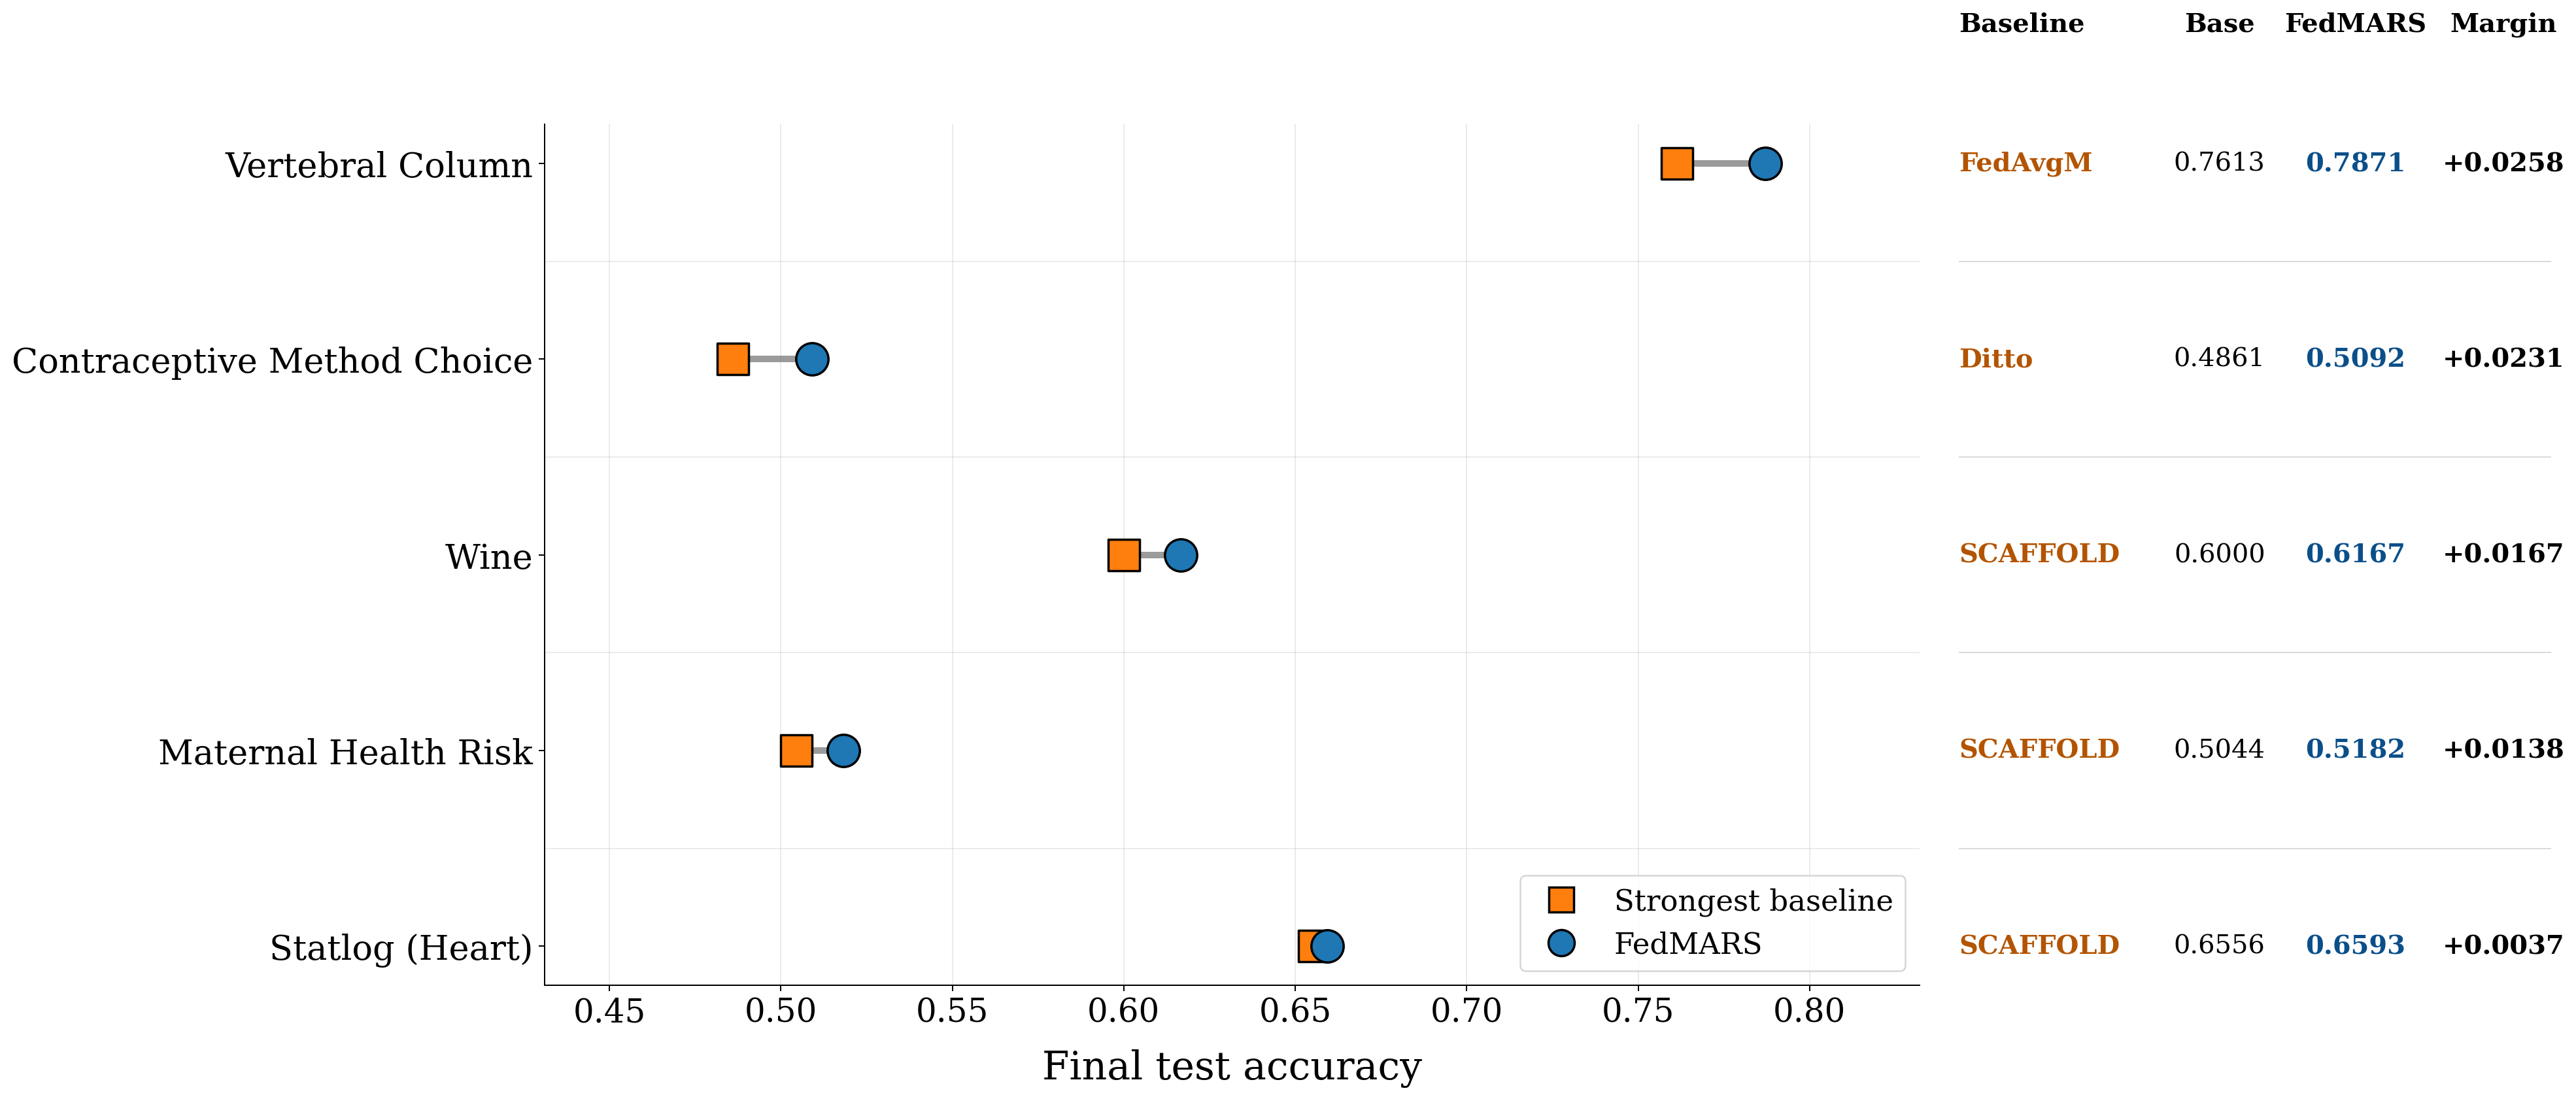

## Saved files

,Folder,Files
0,validation4_plots_fixed_no_overlap,v4_fedmars_vs_strongest_baseline_no_overlap.pd...


In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display, Markdown

OUTDIR = "validation4_plots_fixed_no_overlap"
os.makedirs(OUTDIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 180,
    "savefig.dpi": 600,
    "font.family": "serif",
    "font.size": 18,
    "axes.titlesize": 30,
    "axes.labelsize": 24,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 18,
    "axes.grid": True,
    "grid.alpha": 0.22,
})

summary_csv = None
for p in [
    "validation4_ranked_dataset_method_summary.csv",
    "validation4_dataset_method_summary.csv",
]:
    if os.path.exists(p):
        summary_csv = p
        break

if summary_csv is None:
    raise RuntimeError("Could not find Validation 4 summary CSV.")

result_df = pd.read_csv(summary_csv)

for c in ["uci_id", "final_test_accuracy_mean", "final_test_accuracy_std"]:
    if c in result_df.columns:
        result_df[c] = pd.to_numeric(result_df[c], errors="coerce")

result_df["dataset_name"] = result_df["dataset_name"].astype(str)
result_df["method"] = result_df["method"].astype(str)

rows = []
for (uci_id, dataset_name), part in result_df.groupby(["uci_id", "dataset_name"], dropna=False):
    ok = part[part["final_test_accuracy_mean"].notna()].copy()

    if ok.empty or "FedMARS" not in ok["method"].tolist():
        continue

    fed = ok[ok["method"] == "FedMARS"].iloc[0]

    baselines = ok[ok["method"] != "FedMARS"].sort_values(
        ["final_test_accuracy_mean", "method"],
        ascending=[False, True]
    )

    if baselines.empty:
        continue

    best = baselines.iloc[0]

    rows.append({
        "uci_id": int(uci_id),
        "dataset_name": dataset_name,
        "fedmars_acc": float(fed["final_test_accuracy_mean"]),
        "fedmars_std": float(fed["final_test_accuracy_std"]) if "final_test_accuracy_std" in fed else np.nan,
        "baseline_method": best["method"],
        "baseline_acc": float(best["final_test_accuracy_mean"]),
        "baseline_std": float(best["final_test_accuracy_std"]) if "final_test_accuracy_std" in best else np.nan,
        "margin": float(fed["final_test_accuracy_mean"]) - float(best["final_test_accuracy_mean"]),
    })

comp = pd.DataFrame(rows)

if comp.empty:
    raise RuntimeError("No FedMARS vs strongest baseline comparison could be built.")

comp = comp.sort_values("margin", ascending=True).reset_index(drop=True)

display(Markdown("## Plot source table: FedMARS versus strongest baseline"))
display(comp)

n = len(comp)
y = np.arange(n)

fig = plt.figure(figsize=(22, 9.5))
gs = fig.add_gridspec(1, 2, width_ratios=[3.6, 1.55], wspace=0.04)

ax = fig.add_subplot(gs[0, 0])
ax_table = fig.add_subplot(gs[0, 1], sharey=ax)

for i, r in comp.iterrows():
    base_x = r["baseline_acc"]
    fed_x = r["fedmars_acc"]

    ax.plot(
        [base_x, fed_x],
        [i, i],
        color="#7A7A7A",
        linewidth=4.0,
        alpha=0.75,
        zorder=1,
    )

    ax.scatter(
        base_x,
        i,
        s=360,
        marker="s",
        color="#ff7f0e",
        edgecolor="black",
        linewidth=1.4,
        zorder=4,
    )

    ax.scatter(
        fed_x,
        i,
        s=390,
        marker="o",
        color="#1f77b4",
        edgecolor="black",
        linewidth=1.4,
        zorder=5,
    )

ax.set_yticks(y)
ax.set_yticklabels(comp["dataset_name"], fontsize=21)

ax.set_xlabel("Final test accuracy", labelpad=12)
# ax.set_title("FedMARS vs Strongest Baseline", fontsize=34, fontweight="bold", pad=20)

xmin = min(comp["baseline_acc"].min(), comp["fedmars_acc"].min())
xmax = max(comp["baseline_acc"].max(), comp["fedmars_acc"].max())
ax.set_xlim(max(0.0, xmin - 0.055), min(1.0, xmax + 0.045))

ax.grid(True, axis="x", alpha=0.25)
ax.grid(False, axis="y")
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

legend_handles = [
    Line2D(
        [0], [0],
        marker="s",
        linestyle="None",
        color="w",
        markerfacecolor="#ff7f0e",
        markeredgecolor="black",
        markeredgewidth=1.4,
        markersize=15,
        label="Strongest baseline",
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        color="w",
        markerfacecolor="#1f77b4",
        markeredgecolor="black",
        markeredgewidth=1.4,
        markersize=16,
        label="FedMARS",
    ),
]

ax.legend(
    handles=legend_handles,
    loc="lower right",
    frameon=True,
    fontsize=18,
)

ax_table.set_xlim(0, 1)
ax_table.set_ylim(ax.get_ylim())
ax_table.axis("off")

header_y = n - 0.35
ax_table.text(0.00, header_y, "Baseline", fontsize=16, fontweight="bold", ha="left", va="bottom")
ax_table.text(0.44, header_y, "Base", fontsize=16, fontweight="bold", ha="center", va="bottom")
ax_table.text(0.67, header_y, "FedMARS", fontsize=16, fontweight="bold", ha="center", va="bottom")
ax_table.text(0.92, header_y, "Margin", fontsize=16, fontweight="bold", ha="center", va="bottom")

for i, r in comp.iterrows():
    ax_table.text(
        0.00,
        i,
        str(r["baseline_method"]),
        fontsize=16,
        color="#b35400",
        fontweight="bold",
        ha="left",
        va="center",
    )

    ax_table.text(
        0.44,
        i,
        f"{r['baseline_acc']:.4f}",
        fontsize=16,
        ha="center",
        va="center",
    )

    ax_table.text(
        0.67,
        i,
        f"{r['fedmars_acc']:.4f}",
        fontsize=16,
        color="#0b4f8a",
        fontweight="bold",
        ha="center",
        va="center",
    )

    ax_table.text(
        0.92,
        i,
        f"+{r['margin']:.4f}",
        fontsize=16,
        fontweight="bold",
        ha="center",
        va="center",
    )

for i in range(n):
    ax_table.axhline(i + 0.5, color="0.86", linewidth=0.8, zorder=0)
    ax.axhline(i + 0.5, color="0.92", linewidth=0.8, zorder=0)

fig.tight_layout()

plt.savefig(
    os.path.join(OUTDIR, "v4_fedmars_vs_strongest_baseline_no_overlap.png"),
    dpi=600,
    bbox_inches="tight",
)
plt.savefig(
    os.path.join(OUTDIR, "v4_fedmars_vs_strongest_baseline_no_overlap.pdf"),
    bbox_inches="tight",
)
plt.savefig(
    os.path.join(OUTDIR, "v4_fedmars_vs_strongest_baseline_no_overlap.svg"),
    bbox_inches="tight",
)

plt.show()

display(Markdown("## Saved files"))
display(pd.DataFrame([{
    "Folder": OUTDIR,
    "Files": ", ".join(sorted(os.listdir(OUTDIR)))
}]))